In [40]:
import os
import time
import csv
from google import genai
from google.genai import types
from dotenv import load_dotenv

# ── Config ────────────────────────────────────────────────────────────────────
BASE_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper"
load_dotenv(os.path.join(BASE_DIR, ".env"))

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

MODEL_ID      = "gemini-2.5-flash"
TEMPERATURE   = 0.0
RAG_CONDITION = "RAG-"   # change to "RAG+" when you inject context
QUESTIONS_FILE = os.path.join(BASE_DIR, "svet_28_midtier_questions.txt")
OUTPUT_CSV     = os.path.join(BASE_DIR, f"results_{MODEL_ID}_{RAG_CONDITION}_T{TEMPERATURE}.csv")

SYSTEM_PROMPT = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "Answer the following question in exactly one sentence — no more, no less. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Pack all necessary information into that single sentence. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)
# ── Parser ────────────────────────────────────────────────────────────────────
def parse_questions(filepath: str) -> list[dict]:
    """
    Parse svet_28_midtier_questions.txt into a list of dicts.
    Skips all lines beginning with '#'.
    Returns: [{"id": "Q01", "subtype": "A", "question": "...", "gt": "..."}, ...]
    """
    questions = []
    current = {}

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            # New question block: "Q01 | A"
            if line.startswith("Q") and "|" in line and len(line.split("|")) == 2:
                if current.get("id"):          # save previous block
                    questions.append(current)
                parts = line.split("|")
                current = {
                    "id":       parts[0].strip(),
                    "subtype":  parts[1].strip(),
                    "question": "",
                    "gt":       ""
                }

            elif line.startswith("QUESTION:"):
                current["question"] = line.replace("QUESTION:", "").strip()

            elif line.startswith("GT:"):
                current["gt"] = line.replace("GT:", "").strip()

    if current.get("id"):               # save last block
        questions.append(current)

    return questions

# ── Query ─────────────────────────────────────────────────────────────────────
def query_gemini(question_text: str, retrieved_context: str = "") -> tuple[str, str]:
    """
    Send one question to Gemini. Returns (raw_response, finish_reason).
    Pass retrieved_context only in RAG+ condition.
    """
    user_content = question_text
    if retrieved_context:
        user_content = f"[CONTEXT]\n{retrieved_context}\n\n[QUESTION]\n{question_text}"

    response = client.models.generate_content(
        model=MODEL_ID,
        contents=user_content,
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_PROMPT,
            temperature=TEMPERATURE,
            max_output_tokens=8192,          # large ceiling — thinking tokens eat into this
            thinking_config=types.ThinkingConfig(
                thinking_budget=1024,        # cap internal reasoning tokens explicitly
            ),
        )
    )

    raw        = response.text.strip() if response.text else ""
    finish     = response.candidates[0].finish_reason.name if response.candidates else "UNKNOWN"
    return raw, finish

# ── Main loop ─────────────────────────────────────────────────────────────────
def run_benchmark():
    questions = parse_questions(QUESTIONS_FILE)
    print(f"Loaded {len(questions)} questions. Running {MODEL_ID} | {RAG_CONDITION} | T={TEMPERATURE}\n")

    fieldnames = [
        "question_id", "subtype", "model", "rag_condition", "temperature",
        "finish_reason", "question_text", "raw_response", "retrieved_context", "ground_truth"
    ]

    rows = []  # ← store rows here instead of writing directly

    for q in questions:
        retrieved_context = ""

        try:
            raw, finish = query_gemini(q["question"], retrieved_context)
        except Exception as e:
            print(f"  ERROR on {q['id']}: {e}")
            raw, finish = "ERROR", "ERROR"

        row = {
            "question_id":       q["id"],
            "subtype":           q["subtype"],
            "model":             MODEL_ID,
            "rag_condition":     RAG_CONDITION,
            "temperature":       TEMPERATURE,
            "finish_reason":     finish,
            "question_text":     q["question"],
            "raw_response":      raw,
            "retrieved_context": retrieved_context,
            "ground_truth":      q["gt"]
        }
        rows.append(row)  # ← append to list

        print(f"  {q['id']} [{q['subtype']}] → {finish}")
        print(f"    GT:  {q['gt'][:80]}...")
        print(f"    OUT: {raw[:80]}...")
        print()

        time.sleep(1)

    # ── Write CSV ──────────────────────────────────────────────────────────────
    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    # ── Diagnostic ─────────────────────────────────────────────────────────────
    flagged = [r for r in rows if r["finish_reason"] == "MAX_TOKENS"]
    if flagged:
        print(f"\n⚠️  {len(flagged)} question(s) still hit MAX_TOKENS:")
        for r in flagged:
            print(f"   {r['question_id']} — response length: {len(r['raw_response'])} chars")
    else:
        print("\n✓ All questions completed with STOP.")

    print(f"\nDone. Results saved to:\n  {OUTPUT_CSV}")

if __name__ == "__main__":
    run_benchmark()
    

Loaded 28 questions. Running gemini-2.5-flash | RAG- | T=0.0

  Q01 [A] → STOP
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Platinization increases the effective surface area of the probe, which significa...

  Q02 [A] → STOP
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization increases the effective sensing area of the microelectro...

  Q03 [A] → STOP
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe vibrates to convert the local DC potential gradient generated by ...

  Q04 [A] → STOP
    GT:  In high-conductivity solutions, ionic currents produce smaller potential gradien...
    OUT: Increasing electrolyte conductivity reduces SVET signal strength because it lowe...

  Q05 [A] → STOP
    GT:  If the standoff distance is less than 4x the vibration amplitude, the probe spen...
    OUT: The

# RAG

In [29]:
import os, json
import numpy as np
from google import genai
from google.genai import types
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity

# ── NEW: rebuild embeddings for all KB chunks ──────────────────────────────
# Run ONCE, then save to a new file — do not re-run on every notebook start

NEW_KB_PATH = os.path.join(BASE_DIR, "embeddings_3072.json")

# Load original KB texts/sources (from existing embeddings.json)
with open(KB_PATH, "r", encoding="utf-8") as f:
    kb_old = json.load(f)

print(f"Rebuilding {len(kb_old)} chunk embeddings with gemini-embedding-001 (3072-dim)...")

new_kb = []
for i, chunk in enumerate(kb_old):
    result = gclient.models.embed_content(
        model    = "gemini-embedding-001",
        contents = chunk["text"],
        config   = types.EmbedContentConfig(
            task_type = "RETRIEVAL_DOCUMENT"   # document-side task type
        )
        # No output_dimensionality — use full 3072-dim
    )
    new_kb.append({
        "text":      chunk["text"],
        "source":    chunk["source"],
        "embedding": result.embeddings[0].values
    })
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(kb_old)} done...")
    time.sleep(0.5)   # avoid rate limiting

with open(NEW_KB_PATH, "w", encoding="utf-8") as f:
    json.dump(new_kb, f)

print(f"\nNew KB saved ✓  →  {NEW_KB_PATH}")

# ── Load KB ────────────────────────────────────────────────────────────────
with open(KB_PATH, "r", encoding="utf-8") as f:
    kb = json.load(f)

kb_texts      = [chunk["text"]      for chunk in kb]
kb_sources    = [chunk["source"]    for chunk in kb]
kb_embeddings = np.array([chunk["embedding"] for chunk in kb], dtype=np.float32)

print(f"KB loaded ✓  |  chunks={len(kb_texts)}  |  dim={kb_embeddings.shape[1]}")

# ── Load NEW KB ────────────────────────────────────────────────────────────
KB_PATH   = os.path.join(BASE_DIR, "embeddings_3072.json")   # ← new file
TOP_K_RAG = 10

with open(KB_PATH, "r", encoding="utf-8") as f:
    kb = json.load(f)

kb_texts      = [chunk["text"]      for chunk in kb]
kb_sources    = [chunk["source"]    for chunk in kb]
kb_embeddings = np.array([chunk["embedding"] for chunk in kb], dtype=np.float32)

print(f"KB loaded ✓  |  chunks={len(kb_texts)}  |  dim={kb_embeddings.shape[1]}")  # should print 3072

# ── Retriever — no output_dimensionality truncation ────────────────────────
def retrieve_context(question: str, top_k: int = TOP_K_RAG) -> tuple[str, int]:
    result = gclient.models.embed_content(
        model    = "gemini-embedding-001",
        contents = question,
        config   = types.EmbedContentConfig(
            task_type = "RETRIEVAL_QUERY"   # query-side task type, full 3072-dim
        )
    )
    q_emb   = np.array(result.embeddings[0].values, dtype=np.float32).reshape(1, -1)
    sims    = cosine_similarity(q_emb, kb_embeddings)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    chunks  = [f"[Source: {kb_sources[i]}]\n{kb_texts[i]}" for i in top_idx]
    return "\n\n---\n\n".join(chunks), len(top_idx)
    
# ── Sanity check ───────────────────────────────────────────────────────────
ctx, n = retrieve_context("Why does probe platinization improve SVET signal quality?")
print(f"Retrieval test: {n} chunks returned (should be > 0)")
print(f"First 200 chars:\n{ctx[:200]}")

Rebuilding 146 chunk embeddings with gemini-embedding-001 (3072-dim)...
  20/146 done...
  40/146 done...
  60/146 done...
  80/146 done...
  100/146 done...
  120/146 done...
  140/146 done...

New KB saved ✓  →  C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\embeddings_3072.json
KB loaded ✓  |  chunks=146  |  dim=768
KB loaded ✓  |  chunks=146  |  dim=3072
Retrieval test: 10 chunks returned (should be > 0)
First 200 chars:
[Source: Practical Resources.txt]
In ASET-LV4 use REFERENCE → GO/GET (X/Y) → CONTINUE to store factors. Enter solution resistivity/conductivity in software. Re-calibrate daily and after probe or ampli


In [41]:
import time, csv

# ── Config ─────────────────────────────────────────────────────────────────
MODEL_ID      = "gemini-2.5-flash"
TEMPERATURE   = 0.0
RAG_CONDITION = "RAG+"

QUESTIONS_FILE = os.path.join(BASE_DIR, "svet_28_midtier_questions.txt")
OUTPUT_CSV     = os.path.join(BASE_DIR,
    f"results_{MODEL_ID.replace('.', '_')}_{RAG_CONDITION}_T{TEMPERATURE}.csv")

SYSTEM_PROMPT = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "You will be given a context and a question. "
    "Answer the question in exactly one sentence using ONLY information present in the context. "
    "Your answer MUST include specific values, mechanisms, or named parameters from the context "
    "where available — do not give a vague or general answer if the context contains specifics. "
    "If the context provides a specific mechanism or causal chain, "
    "you MUST state the full chain — cause AND effect — not just one of them. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "Do NOT cite, mention, or refer to any source document by name "
    "(e.g. do not write 'according to the User Guide' or 'as stated in the Manual'). "
    "State facts directly as established knowledge. "
    "If the context does not contain sufficient information to answer specifically, "
    "respond with exactly: 'The provided context does not contain sufficient information to answer this question.' "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)
# ── Parser ─────────────────────────────────────────────────────────────────
def parse_questions(filepath: str) -> list[dict]:
    questions, current = [], {}
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("Q") and "|" in line and len(line.split("|")) == 2:
                if current.get("id"):
                    questions.append(current)
                parts   = line.split("|")
                current = {"id": parts[0].strip(), "subtype": parts[1].strip(),
                           "question": "", "gt": ""}
            elif line.startswith("QUESTION:"):
                current["question"] = line.replace("QUESTION:", "").strip()
            elif line.startswith("GT:"):
                current["gt"] = line.replace("GT:", "").strip()
    if current.get("id"):
        questions.append(current)
    return questions

# ── Query ──────────────────────────────────────────────────────────────────
def query_gemini(question_text: str, retrieved_context: str = "") -> tuple[str, str]:
    user_content = (
        f"[CONTEXT]\n{retrieved_context}\n\n[QUESTION]\n{question_text}"
        if retrieved_context else question_text
    )
    response = gclient.models.generate_content(
        model    = MODEL_ID,
        contents = user_content,
        config   = types.GenerateContentConfig(
            system_instruction = SYSTEM_PROMPT,
            temperature        = TEMPERATURE,
            max_output_tokens  = 8192,
            thinking_config    = types.ThinkingConfig(thinking_budget=1024),
        )
    )
    raw    = response.text.strip() if response.text else ""
    finish = response.candidates[0].finish_reason.name if response.candidates else "UNKNOWN"
    return raw, finish

# ── Main loop ──────────────────────────────────────────────────────────────
def run_benchmark():
    questions = parse_questions(QUESTIONS_FILE)
    print(f"Loaded {len(questions)} questions. "
          f"Running {MODEL_ID} | {RAG_CONDITION} | T={TEMPERATURE}\n")

    # Sanity check retrieval before spending API calls
    ctx_test, n_test = retrieve_context(questions[0]["question"])
    print(f"Retrieval test on Q01: {n_test} chunks (should be > 0)")
    print(f"First 200 chars:\n{ctx_test[:200]}\n")
    if n_test == 0:
        print("⚠️  WARNING: retrieval returned 0 chunks — aborting.")
        return

    fieldnames = [
        "question_id", "subtype", "model", "rag_condition", "temperature",
        "finish_reason", "question_text", "raw_response", "retrieved_context",
        "n_chunks_retrieved", "ground_truth"
    ]
    rows = []

    for q in questions:
        retrieved_context, n_chunks = retrieve_context(q["question"])

        try:
            raw, finish = query_gemini(q["question"], retrieved_context)
        except Exception as e:
            print(f"  ERROR on {q['id']}: {e}")
            raw, finish, n_chunks = "ERROR", "ERROR", 0

        row = {
            "question_id":        q["id"],
            "subtype":            q["subtype"],
            "model":              MODEL_ID,
            "rag_condition":      RAG_CONDITION,
            "temperature":        TEMPERATURE,
            "finish_reason":      finish,
            "question_text":      q["question"],
            "raw_response":       raw,
            "retrieved_context":  retrieved_context,
            "n_chunks_retrieved": n_chunks,
            "ground_truth":       q["gt"]
        }
        rows.append(row)

        print(f"  {q['id']} [{q['subtype']}] → {finish}  | chunks={n_chunks}")
        print(f"    GT:  {q['gt'][:80]}...")
        print(f"    OUT: {raw[:80]}...")
        print()

        time.sleep(1)

    # ── Write CSV ───────────────────────────────────────────────────────────
    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    # ── Diagnostics ─────────────────────────────────────────────────────────
    flagged = [r for r in rows if r["finish_reason"] == "MAX_TOKENS"]
    if flagged:
        print(f"\n⚠️  {len(flagged)} question(s) hit MAX_TOKENS:")
        for r in flagged:
            print(f"   {r['question_id']} — {len(r['raw_response'])} chars")
    else:
        print("\n✓ All questions completed with STOP.")

    zero_chunks = [r for r in rows if r["n_chunks_retrieved"] == 0]
    if zero_chunks:
        print(f"\n⚠️  {len(zero_chunks)} question(s) retrieved 0 chunks:")
        for r in zero_chunks:
            print(f"   {r['question_id']}")
    else:
        print("✓ All questions retrieved at least 1 chunk.")

    print(f"\nDone. Results saved to:\n  {OUTPUT_CSV}")

run_benchmark()

Loaded 28 questions. Running gemini-2.5-flash | RAG+ | T=0.0

Retrieval test on Q01: 10 chunks (should be > 0)
First 200 chars:
[Source: Practical Resources.txt]
In ASET-LV4 use REFERENCE → GO/GET (X/Y) → CONTINUE to store factors. Enter solution resistivity/conductivity in software. Re-calibrate daily and after probe or ampli

  Q01 [A] → STOP  | chunks=10
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality by electrodepositing a platinum...

  Q02 [A] → STOP  | chunks=10
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because too much platinu...

  Q03 [A] → STOP  | chunks=10
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe needs to vibrate perpendicular to the sample surface to amplify t...

  ERROR on Q04: 503

In [ ]:
# correction below

In [47]:
import time, csv

# ── Retry only the failed questions ───────────────────────────────────────
FAILED_IDS = {"Q04", "Q05", "Q14"}

questions = parse_questions(QUESTIONS_FILE)
failed_qs = [q for q in questions if q["id"] in FAILED_IDS]

print(f"Retrying {len(failed_qs)} failed questions: {FAILED_IDS}\n")

# Load existing CSV
existing_rows = []
with open(OUTPUT_CSV, newline="", encoding="utf-8") as f:
    existing_rows = list(csv.DictReader(f))

# Build lookup of existing rows to patch
rows_by_id = {r["question_id"]: r for r in existing_rows}

for q in failed_qs:
    retrieved_context, n_chunks = retrieve_context(q["question"])
    time.sleep(3)  # extra wait before API call after 503

    for attempt in range(3):  # up to 3 retries per question
        try:
            raw, finish = query_gemini(q["question"], retrieved_context)
            print(f"  {q['id']} → {finish} | chunks={n_chunks}")
            print(f"    GT:  {q['gt'][:80]}...")
            print(f"    OUT: {raw[:80]}...")
            print()

            # Patch the row in place
            rows_by_id[q["id"]].update({
                "raw_response":       raw,
                "finish_reason":      finish,
                "retrieved_context":  retrieved_context,
                "n_chunks_retrieved": n_chunks,
            })
            break  # success — stop retrying

        except Exception as e:
            print(f"  {q['id']} attempt {attempt+1} failed: {e}")
            if attempt < 2:
                print(f"  Waiting 10s before retry...")
                time.sleep(10)
            else:
                print(f"  ⚠️  All retries exhausted for {q['id']}")

# ── Rewrite CSV with patched rows ─────────────────────────────────────────
fieldnames = [
    "question_id", "subtype", "model", "rag_condition", "temperature",
    "finish_reason", "question_text", "raw_response", "retrieved_context",
    "n_chunks_retrieved", "ground_truth"
]

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(existing_rows)

print(f"\nCSV patched and saved to:\n  {OUTPUT_CSV}")

Retrying 3 failed questions: {'Q04', 'Q05', 'Q14'}

  Q04 → STOP | chunks=10
    GT:  In high-conductivity solutions, ionic currents produce smaller potential gradien...
    OUT: Increasing electrolyte conductivity reduces SVET signal strength because high io...

  Q05 → STOP | chunks=10
    GT:  If the standoff distance is less than 4x the vibration amplitude, the probe spen...
    OUT: The probe-sample distance must be at least ~4 times the vibration amplitude to m...

  Q14 → STOP | chunks=10
    GT:  Compressed air or nitrogen at 30-40 psi is recommended for cleaning the vibratio...
    OUT: The provided context does not contain sufficient information to answer this ques...


CSV patched and saved to:
  C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\results_gemini-2_5-flash_RAG+_T0.0.csv


In [48]:
import csv, os
from collections import Counter

# ── Hardcoded paths (confirmed by glob) ───────────────────────────────────
RAG_MINUS_CSV = os.path.join(BASE_DIR, "results_gemini-2.5-flash_RAG-_T0.0.csv")
RAG_PLUS_CSV  = os.path.join(BASE_DIR, "results_gemini-2_5-flash_RAG+_T0.0.csv")

def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

rows_minus = load_csv(RAG_MINUS_CSV)
rows_plus  = load_csv(RAG_PLUS_CSV)

print(f"RAG- loaded: {len(rows_minus)} rows")
print(f"RAG+ loaded: {len(rows_plus)} rows")

# ── Detect RAG+ refusals ───────────────────────────────────────────────────
# These are responses where the model explicitly said it couldn't find
# the answer in the retrieved context — honest knowledge boundary signals.
REFUSAL_MARKERS = [
    "the provided text does not",
    "the provided context does not",
    "does not contain information",
    "is not mentioned in",
    "no information",
    "not specified in",
    "not described in",
    "cannot be found in",
    "does not specify",          # ← catches "the provided user guide does not specify"
    "does not mention",          # ← catches similar variants
    "does not provide",          # ← catches "does not provide information on"
    "does not include",          # ← catches "does not include details about"
]

def is_refusal(response: str) -> bool:
    r = response.lower()
    return any(marker in r for marker in REFUSAL_MARKERS)

# ── Split RAG+ into answered vs. refused ──────────────────────────────────
plus_answered = [r for r in rows_plus if not is_refusal(r["raw_response"])]
plus_refused  = [r for r in rows_plus if     is_refusal(r["raw_response"])]

refused_ids   = {r["question_id"] for r in plus_refused}
answered_ids  = {r["question_id"] for r in plus_answered}

# ── Print summary ──────────────────────────────────────────────────────────
print("=" * 65)
print(f"  MODEL : gemini-2.5-flash")
print(f"  TOTAL : {len(rows_plus)} questions")
print("=" * 65)

print(f"\n── RAG+ ANSWERED ({len(plus_answered)} questions) ──────────────────")
print("   These responses were grounded in retrieved KB content.")
print("   → Will undergo similarity scoring vs. GT\n")

minus_by_id = {r["question_id"]: r for r in rows_minus}

for r in plus_answered:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     GT:   {r['ground_truth']}")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response']}")
    print(f"     RAG+: {r['raw_response']}")
    print()

print(f"\n── RAG+ REFUSED ({len(plus_refused)} questions) ───────────────────")
print("   Model explicitly acknowledged it could not find")
print("   the answer in the retrieved context.")
print("   → NOT scored against GT (refusal ≠ wrong answer)")
print("   → Compared qualitatively against RAG- responses\n")

for r in plus_refused:
    qid = r["question_id"]
    print(f"   {qid} [{r['subtype']}]")
    print(f"     QUESTION : {r['question_text'][:80]}...")
    print(f"     RAG+ said: {r['raw_response'][:90]}...")
    print()

# ── High-level metrics ─────────────────────────────────────────────────────
print("=" * 65)
print("  SUMMARY METRICS")
print("=" * 65)
print(f"  RAG+ answer rate     : {len(plus_answered)}/{len(rows_plus)} "
      f"({100*len(plus_answered)/len(rows_plus):.1f}%)")
print(f"  RAG+ refusal rate    : {len(plus_refused)}/{len(rows_plus)} "
      f"({100*len(plus_refused)/len(rows_plus):.1f}%)")
print(f"\n  Questions eligible for similarity scoring : {len(plus_answered)}")
print(f"  Questions for qualitative RAG+/RAG- comparison : {len(plus_refused)}")

# ── Subtype breakdown of refusals ──────────────────────────────────────────
print(f"\n── Refusals by subtype ──────────────────────────────────────────")
from collections import Counter
subtype_refused  = Counter(r["subtype"] for r in plus_refused)
subtype_answered = Counter(r["subtype"] for r in plus_answered)
all_subtypes = sorted(set(subtype_refused) | set(subtype_answered))

subtype_labels = {
    "A": "Mechanism explanation",
    "B": "Parameter justification",
    "C": "Consequence of error",
    "D": "Comparative / technique",
    "E": "Procedure rationale"
}
for s in all_subtypes:
    total = subtype_refused[s] + subtype_answered[s]
    refused_n = subtype_refused[s]
    print(f"   [{s}] {subtype_labels.get(s, s):<28} "
          f"refused {refused_n}/{total} "
          f"({'%.0f' % (100*refused_n/total)}%)")

print("\n  → High refusal rate in subtypes B and E is expected:")
print("    these are AE-specific operational details.")
print("    Low refusal rate in A/D indicates good KB coverage")
print("    of conceptual/mechanistic content.\n")

RAG- loaded: 28 rows
RAG+ loaded: 28 rows
  MODEL : gemini-2.5-flash
  TOTAL : 28 questions

── RAG+ ANSWERED (21 questions) ──────────────────
   These responses were grounded in retrieved KB content.
   → Will undergo similarity scoring vs. GT

   Q01 [A]
     GT:   Electrodepositing platinum black onto the probe tip dramatically increases its electrochemical surface area, creating a highly capacitive interface (target >1 nF) that reduces impedance and lowers noise in the measured signal.
     RAG-: Platinization increases the effective surface area of the probe, which significantly lowers its electrochemical impedance, thereby improving the signal-to-noise ratio and stability by facilitating electron transfer and reducing noise.
     RAG+: Probe platinization improves SVET signal quality by electrodepositing a platinum-black coating that dramatically increases the probe's effective surface area, creating highly capacitive electrodes, lowering impedance, and reducing noise.

   Q02 [

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from bert_score import score as bert_score
import numpy as np


In [49]:

# ── Prepare aligned pairs for the 15 answered questions ───────────────────
minus_by_id   = {r["question_id"]: r for r in rows_minus}

answered_ids_ordered = [r["question_id"] for r in plus_answered]

gt_sentences    = [r["ground_truth"]  for r in plus_answered]
rag_plus_resp   = [r["raw_response"]  for r in plus_answered]
rag_minus_resp  = [minus_by_id[qid]["raw_response"] for qid in answered_ids_ordered]

print(f"Scoring {len(gt_sentences)} question pairs...\n")

# ── 1. BERTScore ───────────────────────────────────────────────────────────
print("Computing BERTScore (this may take ~30s)...")
P_plus,  R_plus,  F_plus  = bert_score(rag_plus_resp,  gt_sentences, lang="en", verbose=False)
P_minus, R_minus, F_minus = bert_score(rag_minus_resp, gt_sentences, lang="en", verbose=False)

f_plus_list  = F_plus.numpy()
f_minus_list = F_minus.numpy()
print("BERTScore done ✓\n")

# ── 2. Cosine similarity (sentence embeddings) ────────────────────────────
print("Computing cosine similarity...")
embedder = SentenceTransformer("all-mpnet-base-v2")

emb_gt    = embedder.encode(gt_sentences,   convert_to_numpy=True)
emb_plus  = embedder.encode(rag_plus_resp,  convert_to_numpy=True)
emb_minus = embedder.encode(rag_minus_resp, convert_to_numpy=True)

cos_plus  = np.array([cos_sim([emb_plus[i]],  [emb_gt[i]])[0][0] for i in range(len(gt_sentences))])
cos_minus = np.array([cos_sim([emb_minus[i]], [emb_gt[i]])[0][0] for i in range(len(gt_sentences))])
print("Cosine similarity done ✓\n")

# ── 3. Per-question results table ─────────────────────────────────────────
print("=" * 85)
print(f"  {'QID':<6} {'Sub':<4} {'BERTScore F1':>12}  {'':>3}  {'CosineSim':>10}  {'':>3}  Winner")
print(f"  {'':6} {'':4} {'RAG+':>6} {'RAG-':>6}  {'':>3}  {'RAG+':>5} {'RAG-':>5}  {'':>3}")
print("=" * 85)

bert_wins_plus, bert_wins_minus, bert_ties = 0, 0, 0
cos_wins_plus,  cos_wins_minus,  cos_ties  = 0, 0, 0

for i, qid in enumerate(answered_ids_ordered):
    subtype = plus_answered[i]["subtype"]

    bp = f_plus_list[i]
    bm = f_minus_list[i]
    cp = cos_plus[i]
    cm = cos_minus[i]

    # BERTScore winner
    if bp > bm + 0.01:
        b_winner = "RAG+"
        bert_wins_plus += 1
    elif bm > bp + 0.01:
        b_winner = "RAG-"
        bert_wins_minus += 1
    else:
        b_winner = "TIE"
        bert_ties += 1

    # Cosine winner
    if cp > cm + 0.01:
        c_winner = "RAG+"
        cos_wins_plus += 1
    elif cm > cp + 0.01:
        c_winner = "RAG-"
        cos_wins_minus += 1
    else:
        c_winner = "TIE"
        cos_ties += 1

    print(f"  {qid:<6} [{subtype}]  "
          f"{bp:.3f}  {bm:.3f}  {'B:'+b_winner:<8}  "
          f"{cp:.3f}  {cm:.3f}  {'C:'+c_winner}")

# ── 4. Aggregate summary ──────────────────────────────────────────────────
print("=" * 85)
print(f"\n── Aggregate (n={len(gt_sentences)} answered questions) ──────────────────────────")
print(f"                     RAG+          RAG-")
print(f"  BERTScore F1 :   {f_plus_list.mean():.3f} ± {f_plus_list.std():.3f}   "
      f"{f_minus_list.mean():.3f} ± {f_minus_list.std():.3f}")
print(f"  Cosine sim   :   {cos_plus.mean():.3f} ± {cos_plus.std():.3f}   "
      f"{cos_minus.mean():.3f} ± {cos_minus.std():.3f}")

print(f"\n── Win/Loss (threshold ±0.01) ────────────────────────────────────")
print(f"  BERTScore : RAG+ wins {bert_wins_plus} | RAG- wins {bert_wins_minus} | Ties {bert_ties}")
print(f"  Cosine    : RAG+ wins {cos_wins_plus}  | RAG- wins {cos_wins_minus}  | Ties {cos_ties}")

# ── 5. Subtype breakdown ──────────────────────────────────────────────────
print(f"\n── Mean BERTScore F1 by subtype ──────────────────────────────────")
subtype_labels = {
    "A": "Mechanism explanation",
    "B": "Parameter justification",
    "C": "Consequence of error",
    "D": "Comparative / technique",
    "E": "Procedure rationale"
}
from collections import defaultdict
sub_plus  = defaultdict(list)
sub_minus = defaultdict(list)

for i, qid in enumerate(answered_ids_ordered):
    s = plus_answered[i]["subtype"]
    sub_plus[s].append(f_plus_list[i])
    sub_minus[s].append(f_minus_list[i])

print(f"  {'Subtype':<30} {'RAG+':>6}  {'RAG-':>6}  Delta")
for s in sorted(sub_plus.keys()):
    mp = np.mean(sub_plus[s])
    mm = np.mean(sub_minus[s])
    print(f"  [{s}] {subtype_labels.get(s,''):<26} {mp:.3f}   {mm:.3f}   "
          f"{'↑ RAG+' if mp > mm else '↓ RAG-'} ({abs(mp-mm):.3f})")

Scoring 21 question pairs...

Computing BERTScore (this may take ~30s)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore done ✓

Computing cosine similarity...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cosine similarity done ✓

  QID    Sub  BERTScore F1        CosineSim       Winner
                RAG+   RAG-        RAG+  RAG-     
  Q01    [A]  0.915  0.898  B:RAG+    0.671  0.734  C:RAG-
  Q02    [A]  0.891  0.881  B:TIE     0.451  0.553  C:RAG-
  Q03    [A]  0.867  0.899  B:RAG-    0.648  0.617  C:RAG+
  Q04    [A]  0.902  0.912  B:TIE     0.677  0.718  C:RAG-
  Q05    [A]  0.874  0.879  B:TIE     0.785  0.724  C:RAG+
  Q06    [A]  0.927  0.875  B:RAG+    0.820  0.765  C:RAG+
  Q07    [A]  0.903  0.876  B:RAG+    0.637  0.556  C:RAG+
  Q08    [A]  0.892  0.870  B:RAG+    0.851  0.753  C:RAG+
  Q10    [B]  0.921  0.884  B:RAG+    0.900  0.744  C:RAG+
  Q12    [B]  0.902  0.898  B:TIE     0.738  0.841  C:RAG-
  Q13    [B]  0.891  0.906  B:RAG-    0.861  0.834  C:RAG+
  Q16    [C]  0.883  0.919  B:RAG-    0.754  0.907  C:RAG-
  Q17    [C]  0.895  0.890  B:TIE     0.668  0.595  C:RAG+
  Q18    [C]  0.906  0.903  B:TIE     0.895  0.916  C:RAG-
  Q19    [C]  0.923  0.904  B:RAG+    0.

# OPENAI

In [50]:
# Nothing to change — kb_embeddings, kb_sources, kb_texts, 
# gclient and retrieve_context are already loaded from the previous session.
# Just confirm:
print(f"KB loaded ✓  |  chunks={len(kb_texts)}  |  dim={kb_embeddings.shape[1]}")
ctx, n = retrieve_context("Why does probe platinization improve SVET signal quality?")
print(f"Retrieval test: {n} chunks (should be 10)")

KB loaded ✓  |  chunks=146  |  dim=3072
Retrieval test: 10 chunks (should be 10)


In [52]:
import time, csv, os
from openai import OpenAI

load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)
oclient = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

MODEL_ID       = "gpt-4o-mini"
TEMPERATURE    = 0.0
QUESTIONS_FILE = os.path.join(BASE_DIR, "svet_28_midtier_questions.txt")
OUTPUT_CSV     = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")

SYSTEM_PROMPT = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "Answer the following question in exactly one sentence — no more, no less. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Pack all necessary information into that single sentence. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_openai_minus(question_text: str) -> tuple[str, str]:
    response = oclient.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": question_text},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

fieldnames = [
    "question_id", "subtype", "model", "rag_condition", "temperature",
    "finish_reason", "question_text", "raw_response", "retrieved_context",
    "n_chunks_retrieved", "ground_truth"
]

questions = parse_questions(QUESTIONS_FILE)
print(f"Loaded {len(questions)} questions. Running {MODEL_ID} | RAG- | T={TEMPERATURE}\n")
rows = []

for q in questions:
    try:
        raw, finish = query_openai_minus(q["question"])
    except Exception as e:
        print(f"  ERROR on {q['id']}: {e}")
        raw, finish = "ERROR", "ERROR"

    rows.append({
        "question_id": q["id"], "subtype": q["subtype"],
        "model": MODEL_ID, "rag_condition": "RAG-", "temperature": TEMPERATURE,
        "finish_reason": finish, "question_text": q["question"],
        "raw_response": raw, "retrieved_context": "", "n_chunks_retrieved": 0,
        "ground_truth": q["gt"]
    })

    print(f"  {q['id']} [{q['subtype']}] → {finish}")
    print(f"    GT:  {q['gt'][:80]}...")
    print(f"    OUT: {raw[:80]}...")
    print()
    time.sleep(0.5)

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

errors  = [r for r in rows if r["raw_response"] == "ERROR"]
flagged = [r for r in rows if r["finish_reason"] == "length"]
print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
print(f"Saved to: {OUTPUT_CSV}")

Loaded 28 questions. Running gpt-4o-mini | RAG- | T=0.0

  Q01 [A] → stop
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality by enhancing the electrochemica...

  Q02 [A] → stop
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance by increasing the electr...

  Q03 [A] → stop
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe needs to vibrate during measurement to enhance the spatial resolu...

  Q04 [A] → stop
    GT:  In high-conductivity solutions, ionic currents produce smaller potential gradien...
    OUT: Increasing electrolyte conductivity reduces SVET signal strength because it enha...

  Q05 [A] → stop
    GT:  If the standoff distance is less than 4x the vibration amplitude, the probe spen...
    OUT: The prob

In [53]:
OUTPUT_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_PLUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "You will be given a context and a question. "
    "Answer the question in exactly one sentence using ONLY information present in the context. "
    "Your answer MUST include specific values, mechanisms, or named parameters from the context "
    "where available — do not give a vague or general answer if the context contains specifics. "
    "If the context provides a specific mechanism or causal chain, "
    "you MUST state the full chain — cause AND effect — not just one of them. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "Do NOT cite, mention, or refer to any source document by name "
    "(e.g. do not write 'according to the User Guide' or 'as stated in the Manual'). "
    "State facts directly as established knowledge. "
    "If the context does not contain sufficient information to answer specifically, "
    "respond with exactly: 'The provided context does not contain sufficient information to answer this question.' "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_openai_plus(question_text: str, retrieved_context: str) -> tuple[str, str]:
    user_content = f"[CONTEXT]\n{retrieved_context}\n\n[QUESTION]\n{question_text}"
    response = oclient.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT_PLUS},
            {"role": "user",   "content": user_content},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

# Sanity check retrieval
ctx_test, n_test = retrieve_context(questions[0]["question"])
print(f"Retrieval test on Q01: {n_test} chunks (should be 10)")
print(f"First 200 chars:\n{ctx_test[:200]}\n")
if n_test == 0:
    print("⚠️  Retrieval returned 0 chunks — aborting.")
else:
    rows = []
    for q in questions:
        retrieved_context, n_chunks = retrieve_context(q["question"])
        try:
            raw, finish = query_openai_plus(q["question"], retrieved_context)
        except Exception as e:
            print(f"  ERROR on {q['id']}: {e}")
            raw, finish, n_chunks = "ERROR", "ERROR", 0

        rows.append({
            "question_id": q["id"], "subtype": q["subtype"],
            "model": MODEL_ID, "rag_condition": "RAG+", "temperature": TEMPERATURE,
            "finish_reason": finish, "question_text": q["question"],
            "raw_response": raw, "retrieved_context": retrieved_context,
            "n_chunks_retrieved": n_chunks, "ground_truth": q["gt"]
        })

        print(f"  {q['id']} [{q['subtype']}] → {finish}  | chunks={n_chunks}")
        print(f"    GT:  {q['gt'][:80]}...")
        print(f"    OUT: {raw[:80]}...")
        print()
        time.sleep(0.5)

    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    errors  = [r for r in rows if r["raw_response"] == "ERROR"]
    flagged = [r for r in rows if r["finish_reason"] == "length"]
    print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
    print(f"Saved to: {OUTPUT_CSV}")

Retrieval test on Q01: 10 chunks (should be 10)
First 200 chars:
[Source: Practical Resources.txt]
In ASET-LV4 use REFERENCE → GO/GET (X/Y) → CONTINUE to store factors. Enter solution resistivity/conductivity in software. Re-calibrate daily and after probe or ampli

  Q01 [A] → stop  | chunks=10
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality by increasing the effective sur...

  Q02 [A] → stop  | chunks=10
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because it fills the hai...

  Q03 [A] → stop  | chunks=10
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe needs to vibrate during measurement to amplify the voltage signal...

  Q04 [A] → stop  | chunks=10
    GT:  In high-conductivity solutions, ionic curre

In [54]:
import csv, os
from collections import Counter

RAG_MINUS_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")
RAG_PLUS_CSV  = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

rows_minus = load_csv(RAG_MINUS_CSV)
rows_plus  = load_csv(RAG_PLUS_CSV)
print(f"RAG- loaded: {len(rows_minus)} rows")
print(f"RAG+ loaded: {len(rows_plus)} rows")

REFUSAL_MARKERS = [
    "the provided text does not", "the provided context does not",
    "does not contain information", "is not mentioned in",
    "no information", "not specified in", "not described in",
    "cannot be found in", "does not specify", "does not mention",
    "does not provide", "does not include",
]

def is_refusal(response: str) -> bool:
    return any(m in response.lower() for m in REFUSAL_MARKERS)

plus_answered = [r for r in rows_plus if not is_refusal(r["raw_response"])]
plus_refused  = [r for r in rows_plus if     is_refusal(r["raw_response"])]
minus_by_id   = {r["question_id"]: r for r in rows_minus}

print("=" * 65)
print(f"  MODEL : {MODEL_ID}")
print(f"  TOTAL : {len(rows_plus)} questions")
print("=" * 65)

print(f"\n── RAG+ ANSWERED ({len(plus_answered)} questions) ──────────────────")
print("   → Will undergo similarity scoring vs. GT\n")
for r in plus_answered:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     GT:   {r['ground_truth']}")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response']}")
    print(f"     RAG+: {r['raw_response']}")
    print()

print(f"\n── RAG+ REFUSED ({len(plus_refused)} questions) ───────────────────")
print("   → NOT scored | compared qualitatively vs RAG-\n")
for r in plus_refused:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     QUESTION : {r['question_text'][:80]}...")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response'][:90]}...")
    print(f"     RAG+: {r['raw_response'][:90]}...")
    print()

print("=" * 65)
print("  SUMMARY METRICS")
print("=" * 65)
print(f"  RAG+ answer rate  : {len(plus_answered)}/{len(rows_plus)} ({100*len(plus_answered)/len(rows_plus):.1f}%)")
print(f"  RAG+ refusal rate : {len(plus_refused)}/{len(rows_plus)} ({100*len(plus_refused)/len(rows_plus):.1f}%)")
print(f"\n  Questions eligible for similarity scoring   : {len(plus_answered)}")
print(f"  Questions for qualitative RAG+/RAG- comparison : {len(plus_refused)}")

subtype_labels = {
    "A": "Mechanism explanation",   "B": "Parameter justification",
    "C": "Consequence of error",    "D": "Comparative / technique",
    "E": "Procedure rationale"
}
subtype_refused  = Counter(r["subtype"] for r in plus_refused)
subtype_answered = Counter(r["subtype"] for r in plus_answered)
all_subtypes = sorted(set(subtype_refused) | set(subtype_answered))
print(f"\n── Refusals by subtype ──────────────────────────────────────────")
for s in all_subtypes:
    total    = subtype_refused[s] + subtype_answered[s]
    refused_n = subtype_refused[s]
    print(f"   [{s}] {subtype_labels.get(s, s):<28} refused {refused_n}/{total} "
          f"({'%.0f' % (100*refused_n/total)}%)")
print("\n  → High refusal rate in B and E is expected (AE-specific details).")
print("    Low refusal rate in A/D indicates good KB coverage.\n")

RAG- loaded: 28 rows
RAG+ loaded: 28 rows
  MODEL : gpt-4o-mini
  TOTAL : 28 questions

── RAG+ ANSWERED (24 questions) ──────────────────
   → Will undergo similarity scoring vs. GT

   Q01 [A]
     GT:   Electrodepositing platinum black onto the probe tip dramatically increases its electrochemical surface area, creating a highly capacitive interface (target >1 nF) that reduces impedance and lowers noise in the measured signal.
     RAG-: Probe platinization improves SVET signal quality by enhancing the electrochemical activity and stability of the platinum microelectrode, which increases its sensitivity to local corrosion processes and reduces noise from background currents.
     RAG+: Probe platinization improves SVET signal quality by increasing the effective surface area of the electrode through the deposition of platinum-black, which enhances capacitance and reduces noise, thereby improving the signal-to-noise ratio during measurements.

   Q02 [A]
     GT:   When the hairy plati

In [55]:
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

cosine_model = SentenceTransformer("all-mpnet-base-v2")

# ── Build aligned lists for answered questions only ────────────────────────
answered_ids  = {r["question_id"] for r in plus_answered}
minus_answered = [minus_by_id[qid] for qid in
                  [r["question_id"] for r in plus_answered]
                  if qid in minus_by_id]

refs       = [r["ground_truth"]   for r in plus_answered]
plus_preds = [r["raw_response"]   for r in plus_answered]
minus_preds= [r["raw_response"]   for r in minus_answered]
subtypes   = [r["subtype"]        for r in plus_answered]
qids       = [r["question_id"]    for r in plus_answered]

# ── BERTScore ──────────────────────────────────────────────────────────────
_, _, F_plus  = bert_score(plus_preds,  refs, lang="en", verbose=False)
_, _, F_minus = bert_score(minus_preds, refs, lang="en", verbose=False)
F_plus  = F_plus.numpy()
F_minus = F_minus.numpy()

# ── Cosine similarity ──────────────────────────────────────────────────────
emb_refs   = cosine_model.encode(refs,        convert_to_numpy=True)
emb_plus   = cosine_model.encode(plus_preds,  convert_to_numpy=True)
emb_minus  = cosine_model.encode(minus_preds, convert_to_numpy=True)

cos_plus  = np.array([cosine_similarity([emb_plus[i]],  [emb_refs[i]])[0][0] for i in range(len(refs))])
cos_minus = np.array([cosine_similarity([emb_minus[i]], [emb_refs[i]])[0][0] for i in range(len(refs))])

# ── Per-question table ─────────────────────────────────────────────────────
THRESHOLD = 0.01
print(f"\n{'QID':<7} {'Sub':>4}  {'BERTScore F1':>22}        {'CosineSim':>18}       {'Winner'}")
print(f"{'':>11}  {'RAG+':>6} {'RAG-':>6}  {'':>8}    {'RAG+':>6} {'RAG-':>6}")
print("=" * 85)

b_wins, b_losses, b_ties = 0, 0, 0
c_wins, c_losses, c_ties = 0, 0, 0

for i, qid in enumerate(qids):
    bp, bm = F_plus[i], F_minus[i]
    cp, cm = cos_plus[i], cos_minus[i]

    b_winner = "B:RAG+" if bp - bm > THRESHOLD else ("B:RAG-" if bm - bp > THRESHOLD else "B:TIE")
    c_winner = "C:RAG+" if cp - cm > THRESHOLD else ("C:RAG-" if cm - cp > THRESHOLD else "C:TIE")

    if "RAG+" in b_winner: b_wins   += 1
    elif "RAG-" in b_winner: b_losses += 1
    else: b_ties += 1

    if "RAG+" in c_winner: c_wins   += 1
    elif "RAG-" in c_winner: c_losses += 1
    else: c_ties += 1

    print(f"  {qid:<5} [{subtypes[i]}]  {bp:.3f}  {bm:.3f}  {b_winner:<10}    "
          f"{cp:.3f}  {cm:.3f}  {c_winner}")

# ── Aggregate ──────────────────────────────────────────────────────────────
print("=" * 85)
print(f"\n── Aggregate (n={len(qids)} answered questions) ──────────────────────────")
print(f"{'':>20} RAG+          RAG-")
print(f"  BERTScore F1 :   {F_plus.mean():.3f} ± {F_plus.std():.3f}   {F_minus.mean():.3f} ± {F_minus.std():.3f}")
print(f"  Cosine sim   :   {cos_plus.mean():.3f} ± {cos_plus.std():.3f}   {cos_minus.mean():.3f} ± {cos_minus.std():.3f}")

print(f"\n── Win/Loss (threshold ±{THRESHOLD}) ────────────────────────────────────────")
print(f"  BERTScore : RAG+ wins {b_wins} | RAG- wins {b_losses} | Ties {b_ties}")
print(f"  Cosine    : RAG+ wins {c_wins} | RAG- wins {c_losses} | Ties {c_ties}")

# ── Subtype breakdown ──────────────────────────────────────────────────────
print(f"\n── Mean BERTScore F1 by subtype ──────────────────────────────────────")
print(f"  {'Subtype':<32} {'RAG+':>6}  {'RAG-':>6}  Delta")
for s in sorted(set(subtypes)):
    idx = [i for i, st in enumerate(subtypes) if st == s]
    mp  = np.mean(F_plus[idx])
    mm  = np.mean(F_minus[idx])
    direction = f"↑ RAG+ ({mp-mm:.3f})" if mp > mm else f"↓ RAG- ({mm-mp:.3f})"
    label = f"[{s}] {subtype_labels[s]}"
    print(f"  {label:<32} {mp:.3f}   {mm:.3f}   {direction}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



QID      Sub            BERTScore F1                 CosineSim       Winner
               RAG+   RAG-                RAG+   RAG-
  Q01   [A]  0.891  0.879  B:RAG+        0.654  0.642  C:RAG+
  Q02   [A]  0.889  0.857  B:RAG+        0.512  0.271  C:RAG+
  Q03   [A]  0.868  0.860  B:TIE         0.616  0.548  C:RAG+
  Q04   [A]  0.911  0.888  B:RAG+        0.660  0.625  C:RAG+
  Q05   [A]  0.874  0.871  B:TIE         0.734  0.657  C:RAG+
  Q06   [A]  0.893  0.868  B:RAG+        0.772  0.704  C:RAG+
  Q07   [A]  0.916  0.890  B:RAG+        0.684  0.569  C:RAG+
  Q08   [A]  0.893  0.874  B:RAG+        0.864  0.713  C:RAG+
  Q09   [B]  0.886  0.900  B:RAG-        0.832  0.900  C:RAG-
  Q10   [B]  0.933  0.889  B:RAG+        0.894  0.769  C:RAG+
  Q12   [B]  0.913  0.894  B:RAG+        0.708  0.711  C:TIE
  Q13   [B]  0.903  0.915  B:RAG-        0.813  0.858  C:RAG-
  Q14   [B]  0.937  0.922  B:RAG+        0.842  0.799  C:RAG+
  Q16   [C]  0.896  0.891  B:TIE         0.853  0.720  C:RAG+
  

# GROK

In [57]:
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)
grok_client = OpenAI(
    api_key=os.getenv("XAI_API_KEY"),
    base_url="https://api.x.ai/v1",
)
print(f"xAI client initialized ✓  |  key found: {bool(os.getenv('XAI_API_KEY'))}")

xAI client initialized ✓  |  key found: True


In [58]:
import time, csv

MODEL_ID       = "grok-4-1-fast"
TEMPERATURE    = 0.0
QUESTIONS_FILE = os.path.join(BASE_DIR, "svet_28_midtier_questions.txt")
OUTPUT_CSV     = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_MINUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "Answer the following question in exactly one sentence — no more, no less. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Pack all necessary information into that single sentence. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_grok_minus(question_text: str) -> tuple[str, str]:
    response = grok_client.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT_MINUS},
            {"role": "user",   "content": question_text},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

fieldnames = [
    "question_id", "subtype", "model", "rag_condition", "temperature",
    "finish_reason", "question_text", "raw_response", "retrieved_context",
    "n_chunks_retrieved", "ground_truth"
]

questions = parse_questions(QUESTIONS_FILE)
print(f"Loaded {len(questions)} questions. Running {MODEL_ID} | RAG- | T={TEMPERATURE}\n")
rows = []

for q in questions:
    try:
        raw, finish = query_grok_minus(q["question"])
    except Exception as e:
        print(f"  ERROR on {q['id']}: {e}")
        raw, finish = "ERROR", "ERROR"

    rows.append({
        "question_id": q["id"], "subtype": q["subtype"],
        "model": MODEL_ID, "rag_condition": "RAG-", "temperature": TEMPERATURE,
        "finish_reason": finish, "question_text": q["question"],
        "raw_response": raw, "retrieved_context": "", "n_chunks_retrieved": 0,
        "ground_truth": q["gt"]
    })

    print(f"  {q['id']} [{q['subtype']}] → {finish}")
    print(f"    GT:  {q['gt'][:80]}...")
    print(f"    OUT: {raw[:80]}...")
    print()
    time.sleep(0.5)

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

errors  = [r for r in rows if r["raw_response"] == "ERROR"]
flagged = [r for r in rows if r["finish_reason"] == "length"]
print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
print(f"Saved to: {OUTPUT_CSV}")

Loaded 28 questions. Running grok-4-1-fast | RAG- | T=0.0

  Q01 [A] → stop
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality by depositing a high-surface-ar...

  Q02 [A] → stop
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance by excessively increasin...

  Q03 [A] → stop
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe vibrates perpendicularly to the sample surface to modulate its po...

  Q04 [A] → stop
    GT:  In high-conductivity solutions, ionic currents produce smaller potential gradien...
    OUT: Increasing electrolyte conductivity reduces SVET signal strength because it decr...

  Q05 [A] → stop
    GT:  If the standoff distance is less than 4x the vibration amplitude, the probe spen...
    OUT: The pr

In [59]:
OUTPUT_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_PLUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "You will be given a context and a question. "
    "Answer the question in exactly one sentence using ONLY information present in the context. "
    "Your answer MUST include specific values, mechanisms, or named parameters from the context "
    "where available — do not give a vague or general answer if the context contains specifics. "
    "If the context provides a specific mechanism or causal chain, "
    "you MUST state the full chain — cause AND effect — not just one of them. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "Do NOT cite, mention, or refer to any source document by name "
    "(e.g. do not write 'according to the User Guide' or 'as stated in the Manual'). "
    "State facts directly as established knowledge. "
    "If the context does not contain sufficient information to answer specifically, "
    "respond with exactly: 'The provided context does not contain sufficient information to answer this question.' "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_grok_plus(question_text: str, retrieved_context: str) -> tuple[str, str]:
    user_content = f"[CONTEXT]\n{retrieved_context}\n\n[QUESTION]\n{question_text}"
    response = grok_client.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT_PLUS},
            {"role": "user",   "content": user_content},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

# Sanity check retrieval
ctx_test, n_test = retrieve_context(questions[0]["question"])
print(f"Retrieval test on Q01: {n_test} chunks (should be 10)")
print(f"First 200 chars:\n{ctx_test[:200]}\n")
if n_test == 0:
    print("⚠️  Retrieval returned 0 chunks — aborting.")
else:
    rows = []
    for q in questions:
        retrieved_context, n_chunks = retrieve_context(q["question"])
        try:
            raw, finish = query_grok_plus(q["question"], retrieved_context)
        except Exception as e:
            print(f"  ERROR on {q['id']}: {e}")
            raw, finish, n_chunks = "ERROR", "ERROR", 0

        rows.append({
            "question_id": q["id"], "subtype": q["subtype"],
            "model": MODEL_ID, "rag_condition": "RAG+", "temperature": TEMPERATURE,
            "finish_reason": finish, "question_text": q["question"],
            "raw_response": raw, "retrieved_context": retrieved_context,
            "n_chunks_retrieved": n_chunks, "ground_truth": q["gt"]
        })

        print(f"  {q['id']} [{q['subtype']}] → {finish}  | chunks={n_chunks}")
        print(f"    GT:  {q['gt'][:80]}...")
        print(f"    OUT: {raw[:80]}...")
        print()
        time.sleep(0.5)

    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    errors  = [r for r in rows if r["raw_response"] == "ERROR"]
    flagged = [r for r in rows if r["finish_reason"] == "length"]
    print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
    print(f"Saved to: {OUTPUT_CSV}")

Retrieval test on Q01: 10 chunks (should be 10)
First 200 chars:
[Source: Practical Resources.txt]
In ASET-LV4 use REFERENCE → GO/GET (X/Y) → CONTINUE to store factors. Enter solution resistivity/conductivity in software. Re-calibrate daily and after probe or ampli

  Q01 [A] → stop  | chunks=10
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality by electrodepositing a platinum...

  Q02 [A] → stop  | chunks=10
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because too much deposit...

  Q03 [A] → stop  | chunks=10
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe needs to vibrate perpendicular to the sample surface, typically a...

  Q04 [A] → stop  | chunks=10
    GT:  In high-conductivity solutions, ionic curre

In [60]:
import csv, os
from collections import Counter

MODEL_ID      = "grok-4-1-fast"
TEMPERATURE   = 0.0

RAG_MINUS_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")
RAG_PLUS_CSV  = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

rows_minus = load_csv(RAG_MINUS_CSV)
rows_plus  = load_csv(RAG_PLUS_CSV)
print(f"RAG- loaded: {len(rows_minus)} rows")
print(f"RAG+ loaded: {len(rows_plus)} rows")

REFUSAL_MARKERS = [
    "the provided text does not", "the provided context does not",
    "does not contain information", "is not mentioned in",
    "no information", "not specified in", "not described in",
    "cannot be found in", "does not specify", "does not mention",
    "does not provide", "does not include",
]

def is_refusal(response: str) -> bool:
    return any(m in response.lower() for m in REFUSAL_MARKERS)

plus_answered = [r for r in rows_plus if not is_refusal(r["raw_response"])]
plus_refused  = [r for r in rows_plus if     is_refusal(r["raw_response"])]
minus_by_id   = {r["question_id"]: r for r in rows_minus}

print("=" * 65)
print(f"  MODEL : {MODEL_ID}")
print(f"  TOTAL : {len(rows_plus)} questions")
print("=" * 65)

print(f"\n── RAG+ ANSWERED ({len(plus_answered)} questions) ──────────────────")
print("   → Will undergo similarity scoring vs. GT\n")
for r in plus_answered:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     GT:   {r['ground_truth']}")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response']}")
    print(f"     RAG+: {r['raw_response']}")
    print()

print(f"\n── RAG+ REFUSED ({len(plus_refused)} questions) ───────────────────")
print("   → NOT scored | compared qualitatively vs RAG-\n")
for r in plus_refused:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     QUESTION : {r['question_text'][:80]}...")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response'][:90]}...")
    print(f"     RAG+: {r['raw_response'][:90]}...")
    print()

print("=" * 65)
print("  SUMMARY METRICS")
print("=" * 65)
print(f"  RAG+ answer rate  : {len(plus_answered)}/{len(rows_plus)} ({100*len(plus_answered)/len(rows_plus):.1f}%)")
print(f"  RAG+ refusal rate : {len(plus_refused)}/{len(rows_plus)} ({100*len(plus_refused)/len(rows_plus):.1f}%)")
print(f"\n  Questions eligible for similarity scoring   : {len(plus_answered)}")
print(f"  Questions for qualitative RAG+/RAG- comparison : {len(plus_refused)}")

subtype_labels = {
    "A": "Mechanism explanation",   "B": "Parameter justification",
    "C": "Consequence of error",    "D": "Comparative / technique",
    "E": "Procedure rationale"
}
subtype_refused  = Counter(r["subtype"] for r in plus_refused)
subtype_answered = Counter(r["subtype"] for r in plus_answered)
all_subtypes = sorted(set(subtype_refused) | set(subtype_answered))
print(f"\n── Refusals by subtype ──────────────────────────────────────────")
for s in all_subtypes:
    total     = subtype_refused[s] + subtype_answered[s]
    refused_n = subtype_refused[s]
    print(f"   [{s}] {subtype_labels.get(s, s):<28} refused {refused_n}/{total} "
          f"({'%.0f' % (100*refused_n/total)}%)")
print("\n  → High refusal rate in B and E is expected (AE-specific details).")
print("    Low refusal rate in A/D indicates good KB coverage.\n")

RAG- loaded: 28 rows
RAG+ loaded: 28 rows
  MODEL : grok-4-1-fast
  TOTAL : 28 questions

── RAG+ ANSWERED (22 questions) ──────────────────
   → Will undergo similarity scoring vs. GT

   Q01 [A]
     GT:   Electrodepositing platinum black onto the probe tip dramatically increases its electrochemical surface area, creating a highly capacitive interface (target >1 nF) that reduces impedance and lowers noise in the measured signal.
     RAG-: Probe platinization improves SVET signal quality by depositing a high-surface-area platinum black layer on the microelectrode, which drastically lowers its impedance, enhances high-frequency response to the vibrating probe's modulation, and reduces noise for more accurate mapping of local ionic currents.
     RAG+: Probe platinization improves SVET signal quality by electrodepositing a platinum-black coating that dramatically increases the tip's surface area, creating a highly capacitive electrode (target capacitance >1 nF or ≥ ~2 nF) which lowers 

In [61]:
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from collections import defaultdict

if "cosine_model" not in dir():
    cosine_model = SentenceTransformer("all-mpnet-base-v2")
    print("SentenceTransformer loaded ✓")
else:
    print("SentenceTransformer already in memory — skipping reload ✓")

# ── Build aligned lists ────────────────────────────────────────────────────
qids        = [r["question_id"] for r in plus_answered]
subtypes    = [r["subtype"]     for r in plus_answered]
refs        = [r["ground_truth"] for r in plus_answered]
plus_preds  = [r["raw_response"] for r in plus_answered]
minus_preds = [minus_by_id[qid]["raw_response"] for qid in qids]

print(f"Scoring {len(refs)} question pairs...\n")

# ── BERTScore ──────────────────────────────────────────────────────────────
print("Computing BERTScore (this may take ~30s)...")
_, _, F_plus  = bert_score(plus_preds,  refs, lang="en", verbose=False)
_, _, F_minus = bert_score(minus_preds, refs, lang="en", verbose=False)
F_plus  = F_plus.numpy()
F_minus = F_minus.numpy()
print("BERTScore done ✓\n")

# ── Cosine similarity ──────────────────────────────────────────────────────
print("Computing cosine similarity...")
emb_refs   = cosine_model.encode(refs,        convert_to_numpy=True)
emb_plus   = cosine_model.encode(plus_preds,  convert_to_numpy=True)
emb_minus  = cosine_model.encode(minus_preds, convert_to_numpy=True)

cos_plus  = np.array([cosine_similarity([emb_plus[i]],  [emb_refs[i]])[0][0] for i in range(len(refs))])
cos_minus = np.array([cosine_similarity([emb_minus[i]], [emb_refs[i]])[0][0] for i in range(len(refs))])
print("Cosine similarity done ✓\n")

# ── Per-question table ─────────────────────────────────────────────────────
THRESHOLD = 0.01
print(f"{'QID':<7} {'Sub':>4}  {'BERTScore F1':>22}        {'CosineSim':>18}       Winner")
print(f"{'':>11}  {'RAG+':>6} {'RAG-':>6}  {'':>8}    {'RAG+':>6} {'RAG-':>6}")
print("=" * 85)

b_wins, b_losses, b_ties = 0, 0, 0
c_wins, c_losses, c_ties = 0, 0, 0

for i, qid in enumerate(qids):
    bp, bm = F_plus[i], F_minus[i]
    cp, cm = cos_plus[i], cos_minus[i]

    b_winner = "B:RAG+" if bp - bm > THRESHOLD else ("B:RAG-" if bm - bp > THRESHOLD else "B:TIE")
    c_winner = "C:RAG+" if cp - cm > THRESHOLD else ("C:RAG-" if cm - cp > THRESHOLD else "C:TIE")

    if "RAG+" in b_winner: b_wins   += 1
    elif "RAG-" in b_winner: b_losses += 1
    else: b_ties += 1

    if "RAG+" in c_winner: c_wins   += 1
    elif "RAG-" in c_winner: c_losses += 1
    else: c_ties += 1

    print(f"  {qid:<5} [{subtypes[i]}]  {bp:.3f}  {bm:.3f}  {b_winner:<10}    "
          f"{cp:.3f}  {cm:.3f}  {c_winner}")

# ── Aggregate ──────────────────────────────────────────────────────────────
print("=" * 85)
print(f"\n── Aggregate (n={len(qids)} answered questions) ──────────────────────────")
print(f"{'':>20} RAG+          RAG-")
print(f"  BERTScore F1 :   {F_plus.mean():.3f} ± {F_plus.std():.3f}   {F_minus.mean():.3f} ± {F_minus.std():.3f}")
print(f"  Cosine sim   :   {cos_plus.mean():.3f} ± {cos_plus.std():.3f}   {cos_minus.mean():.3f} ± {cos_minus.std():.3f}")

print(f"\n── Win/Loss (threshold ±{THRESHOLD}) ────────────────────────────────────────")
print(f"  BERTScore : RAG+ wins {b_wins} | RAG- wins {b_losses} | Ties {b_ties}")
print(f"  Cosine    : RAG+ wins {c_wins} | RAG- wins {c_losses} | Ties {c_ties}")

# ── Subtype breakdown ──────────────────────────────────────────────────────
print(f"\n── Mean BERTScore F1 by subtype ──────────────────────────────────────")
print(f"  {'Subtype':<32} {'RAG+':>6}  {'RAG-':>6}  Delta")
sub_plus  = defaultdict(list)
sub_minus = defaultdict(list)
for i, qid in enumerate(qids):
    sub_plus[subtypes[i]].append(F_plus[i])
    sub_minus[subtypes[i]].append(F_minus[i])

for s in sorted(sub_plus.keys()):
    mp  = np.mean(sub_plus[s])
    mm  = np.mean(sub_minus[s])
    direction = f"↑ RAG+ ({mp-mm:.3f})" if mp > mm else f"↓ RAG- ({mm-mp:.3f})"
    label = f"[{s}] {subtype_labels[s]}"
    print(f"  {label:<32} {mp:.3f}   {mm:.3f}   {direction}")

SentenceTransformer already in memory — skipping reload ✓
Scoring 22 question pairs...

Computing BERTScore (this may take ~30s)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore done ✓

Computing cosine similarity...
Cosine similarity done ✓

QID      Sub            BERTScore F1                 CosineSim       Winner
               RAG+   RAG-                RAG+   RAG-
  Q01   [A]  0.923  0.884  B:RAG+        0.667  0.653  C:RAG+
  Q02   [A]  0.870  0.859  B:RAG+        0.464  0.446  C:RAG+
  Q03   [A]  0.855  0.879  B:RAG-        0.605  0.561  C:RAG+
  Q04   [A]  0.877  0.871  B:TIE         0.696  0.675  C:RAG+
  Q05   [A]  0.872  0.873  B:TIE         0.785  0.710  C:RAG+
  Q06   [A]  0.901  0.871  B:RAG+        0.797  0.678  C:RAG+
  Q07   [A]  0.912  0.873  B:RAG+        0.687  0.566  C:RAG+
  Q08   [A]  0.895  0.865  B:RAG+        0.844  0.849  C:TIE
  Q10   [B]  0.919  0.872  B:RAG+        0.952  0.620  C:RAG+
  Q12   [B]  0.909  0.896  B:RAG+        0.810  0.718  C:RAG+
  Q13   [B]  0.892  0.905  B:RAG-        0.792  0.836  C:RAG-
  Q16   [C]  0.893  0.899  B:TIE         0.914  0.901  C:RAG+
  Q17   [C]  0.883  0.879  B:TIE         0.597  0.64

# deepseek

In [62]:
from dotenv import load_dotenv
import os
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)
from openai import OpenAI

deepseek_client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com",
)
MODEL_ID    = "deepseek-chat"
TEMPERATURE = 0.0

print(f"DeepSeek client initialized ✓  |  key found: {bool(os.getenv('DEEPSEEK_API_KEY'))}")

DeepSeek client initialized ✓  |  key found: True


In [63]:
import time, csv

QUESTIONS_FILE = os.path.join(BASE_DIR, "svet_28_midtier_questions.txt")
OUTPUT_CSV     = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_MINUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "Answer the following question in exactly one sentence — no more, no less. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Pack all necessary information into that single sentence. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_deepseek_minus(question_text: str) -> tuple[str, str]:
    response = deepseek_client.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT_MINUS},
            {"role": "user",   "content": question_text},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

fieldnames = [
    "question_id", "subtype", "model", "rag_condition", "temperature",
    "finish_reason", "question_text", "raw_response", "retrieved_context",
    "n_chunks_retrieved", "ground_truth"
]

questions = parse_questions(QUESTIONS_FILE)
print(f"Loaded {len(questions)} questions. Running {MODEL_ID} | RAG- | T={TEMPERATURE}\n")
rows = []

for q in questions:
    try:
        raw, finish = query_deepseek_minus(q["question"])
    except Exception as e:
        print(f"  ERROR on {q['id']}: {e}")
        raw, finish = "ERROR", "ERROR"

    rows.append({
        "question_id": q["id"], "subtype": q["subtype"],
        "model": MODEL_ID, "rag_condition": "RAG-", "temperature": TEMPERATURE,
        "finish_reason": finish, "question_text": q["question"],
        "raw_response": raw, "retrieved_context": "", "n_chunks_retrieved": 0,
        "ground_truth": q["gt"]
    })

    print(f"  {q['id']} [{q['subtype']}] → {finish}")
    print(f"    GT:  {q['gt'][:80]}...")
    print(f"    OUT: {raw[:80]}...")
    print()
    time.sleep(0.5)

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

errors  = [r for r in rows if r["raw_response"] == "ERROR"]
flagged = [r for r in rows if r["finish_reason"] == "length"]
print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
print(f"Saved to: {OUTPUT_CSV}")

Loaded 28 questions. Running deepseek-chat | RAG- | T=0.0

  Q01 [A] → stop
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization, by creating a porous platinum black coating on the microele...

  Q02 [A] → stop
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance by increasing the microe...

  Q03 [A] → stop
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe vibrates to convert the local potential gradient in the electroly...

  Q04 [A] → stop
    GT:  In high-conductivity solutions, ionic currents produce smaller potential gradien...
    OUT: Increasing electrolyte conductivity reduces the SVET signal strength because it ...

  Q05 [A] → stop
    GT:  If the standoff distance is less than 4x the vibration amplitude, the probe spen...
    OUT: This r

In [64]:
OUTPUT_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_PLUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "You will be given a context and a question. "
    "Answer the question in exactly one sentence using ONLY information present in the context. "
    "Your answer MUST include specific values, mechanisms, or named parameters from the context "
    "where available — do not give a vague or general answer if the context contains specifics. "
    "If the context provides a specific mechanism or causal chain, "
    "you MUST state the full chain — cause AND effect — not just one of them. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "Do NOT cite, mention, or refer to any source document by name "
    "(e.g. do not write 'according to the User Guide' or 'as stated in the Manual'). "
    "State facts directly as established knowledge. "
    "If the context does not contain sufficient information to answer specifically, "
    "respond with exactly: 'The provided context does not contain sufficient information to answer this question.' "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_deepseek_plus(question_text: str, retrieved_context: str) -> tuple[str, str]:
    user_content = f"[CONTEXT]\n{retrieved_context}\n\n[QUESTION]\n{question_text}"
    response = deepseek_client.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT_PLUS},
            {"role": "user",   "content": user_content},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

# Sanity check retrieval
ctx_test, n_test = retrieve_context(questions[0]["question"])
print(f"Retrieval test on Q01: {n_test} chunks (should be 10)")
print(f"First 200 chars:\n{ctx_test[:200]}\n")
if n_test == 0:
    print("⚠️  Retrieval returned 0 chunks — aborting.")
else:
    rows = []
    for q in questions:
        retrieved_context, n_chunks = retrieve_context(q["question"])
        try:
            raw, finish = query_deepseek_plus(q["question"], retrieved_context)
        except Exception as e:
            print(f"  ERROR on {q['id']}: {e}")
            raw, finish, n_chunks = "ERROR", "ERROR", 0

        rows.append({
            "question_id": q["id"], "subtype": q["subtype"],
            "model": MODEL_ID, "rag_condition": "RAG+", "temperature": TEMPERATURE,
            "finish_reason": finish, "question_text": q["question"],
            "raw_response": raw, "retrieved_context": retrieved_context,
            "n_chunks_retrieved": n_chunks, "ground_truth": q["gt"]
        })

        print(f"  {q['id']} [{q['subtype']}] → {finish}  | chunks={n_chunks}")
        print(f"    GT:  {q['gt'][:80]}...")
        print(f"    OUT: {raw[:80]}...")
        print()
        time.sleep(0.5)

    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    errors  = [r for r in rows if r["raw_response"] == "ERROR"]
    flagged = [r for r in rows if r["finish_reason"] == "length"]
    print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
    print(f"Saved to: {OUTPUT_CSV}")

Retrieval test on Q01: 10 chunks (should be 10)
First 200 chars:
[Source: Practical Resources.txt]
In ASET-LV4 use REFERENCE → GO/GET (X/Y) → CONTINUE to store factors. Enter solution resistivity/conductivity in software. Re-calibrate daily and after probe or ampli

  Q01 [A] → stop  | chunks=10
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality because the electrodeposited pl...

  Q02 [A] → stop  | chunks=10
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because if the deposit f...

  Q03 [A] → stop  | chunks=10
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe vibrates to amplify the tiny voltage gradient in solution by gene...

  Q04 [A] → stop  | chunks=10
    GT:  In high-conductivity solutions, ionic curre

In [65]:
import csv, os
from collections import Counter

RAG_MINUS_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")
RAG_PLUS_CSV  = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

rows_minus = load_csv(RAG_MINUS_CSV)
rows_plus  = load_csv(RAG_PLUS_CSV)
print(f"RAG- loaded: {len(rows_minus)} rows")
print(f"RAG+ loaded: {len(rows_plus)} rows")

REFUSAL_MARKERS = [
    "the provided text does not", "the provided context does not",
    "does not contain information", "is not mentioned in",
    "no information", "not specified in", "not described in",
    "cannot be found in", "does not specify", "does not mention",
    "does not provide", "does not include",
]

def is_refusal(response: str) -> bool:
    return any(m in response.lower() for m in REFUSAL_MARKERS)

plus_answered = [r for r in rows_plus if not is_refusal(r["raw_response"])]
plus_refused  = [r for r in rows_plus if     is_refusal(r["raw_response"])]
minus_by_id   = {r["question_id"]: r for r in rows_minus}

print("=" * 65)
print(f"  MODEL : {MODEL_ID}")
print(f"  TOTAL : {len(rows_plus)} questions")
print("=" * 65)

print(f"\n── RAG+ ANSWERED ({len(plus_answered)} questions) ──────────────────")
print("   → Will undergo similarity scoring vs. GT\n")
for r in plus_answered:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     GT:   {r['ground_truth']}")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response']}")
    print(f"     RAG+: {r['raw_response']}")
    print()

print(f"\n── RAG+ REFUSED ({len(plus_refused)} questions) ───────────────────")
print("   → NOT scored | compared qualitatively vs RAG-\n")
for r in plus_refused:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     QUESTION : {r['question_text'][:80]}...")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response'][:90]}...")
    print(f"     RAG+: {r['raw_response'][:90]}...")
    print()

print("=" * 65)
print("  SUMMARY METRICS")
print("=" * 65)
print(f"  RAG+ answer rate  : {len(plus_answered)}/{len(rows_plus)} ({100*len(plus_answered)/len(rows_plus):.1f}%)")
print(f"  RAG+ refusal rate : {len(plus_refused)}/{len(rows_plus)} ({100*len(plus_refused)/len(rows_plus):.1f}%)")
print(f"\n  Questions eligible for similarity scoring   : {len(plus_answered)}")
print(f"  Questions for qualitative RAG+/RAG- comparison : {len(plus_refused)}")

subtype_labels = {
    "A": "Mechanism explanation",   "B": "Parameter justification",
    "C": "Consequence of error",    "D": "Comparative / technique",
    "E": "Procedure rationale"
}
subtype_refused  = Counter(r["subtype"] for r in plus_refused)
subtype_answered = Counter(r["subtype"] for r in plus_answered)
all_subtypes = sorted(set(subtype_refused) | set(subtype_answered))
print(f"\n── Refusals by subtype ──────────────────────────────────────────")
for s in all_subtypes:
    total     = subtype_refused[s] + subtype_answered[s]
    refused_n = subtype_refused[s]
    print(f"   [{s}] {subtype_labels.get(s, s):<28} refused {refused_n}/{total} "
          f"({'%.0f' % (100*refused_n/total)}%)")
print("\n  → High refusal rate in B and E is expected (AE-specific details).")
print("    Low refusal rate in A/D indicates good KB coverage.\n")

RAG- loaded: 28 rows
RAG+ loaded: 28 rows
  MODEL : deepseek-chat
  TOTAL : 28 questions

── RAG+ ANSWERED (24 questions) ──────────────────
   → Will undergo similarity scoring vs. GT

   Q01 [A]
     GT:   Electrodepositing platinum black onto the probe tip dramatically increases its electrochemical surface area, creating a highly capacitive interface (target >1 nF) that reduces impedance and lowers noise in the measured signal.
     RAG-: Probe platinization, by creating a porous platinum black coating on the microelectrode tip, dramatically increases the electroactive surface area, which lowers the impedance and enhances the signal-to-noise ratio for detecting the minute potential gradients in solution.
     RAG+: Probe platinization improves SVET signal quality because the electrodeposited platinum-black coating dramatically increases the electrode's surface area, creating a highly capacitive electrode (target capacitance >1 nF) which lowers impedance and reduces noise.

   Q02 [A

In [66]:
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from collections import defaultdict

if "cosine_model" not in dir():
    cosine_model = SentenceTransformer("all-mpnet-base-v2")
    print("SentenceTransformer loaded ✓")
else:
    print("SentenceTransformer already in memory — skipping reload ✓")

# ── Build aligned lists ────────────────────────────────────────────────────
qids        = [r["question_id"]  for r in plus_answered]
subtypes    = [r["subtype"]      for r in plus_answered]
refs        = [r["ground_truth"] for r in plus_answered]
plus_preds  = [r["raw_response"] for r in plus_answered]
minus_preds = [minus_by_id[qid]["raw_response"] for qid in qids]

print(f"Scoring {len(refs)} question pairs...\n")

# ── BERTScore ──────────────────────────────────────────────────────────────
print("Computing BERTScore (this may take ~30s)...")
_, _, F_plus  = bert_score(plus_preds,  refs, lang="en", verbose=False)
_, _, F_minus = bert_score(minus_preds, refs, lang="en", verbose=False)
F_plus  = F_plus.numpy()
F_minus = F_minus.numpy()
print("BERTScore done ✓\n")

# ── Cosine similarity ──────────────────────────────────────────────────────
print("Computing cosine similarity...")
emb_refs   = cosine_model.encode(refs,        convert_to_numpy=True)
emb_plus   = cosine_model.encode(plus_preds,  convert_to_numpy=True)
emb_minus  = cosine_model.encode(minus_preds, convert_to_numpy=True)

cos_plus  = np.array([cosine_similarity([emb_plus[i]],  [emb_refs[i]])[0][0] for i in range(len(refs))])
cos_minus = np.array([cosine_similarity([emb_minus[i]], [emb_refs[i]])[0][0] for i in range(len(refs))])
print("Cosine similarity done ✓\n")

# ── Per-question table ─────────────────────────────────────────────────────
THRESHOLD = 0.01
print(f"{'QID':<7} {'Sub':>4}  {'BERTScore F1':>22}        {'CosineSim':>18}       Winner")
print(f"{'':>11}  {'RAG+':>6} {'RAG-':>6}  {'':>8}    {'RAG+':>6} {'RAG-':>6}")
print("=" * 85)

b_wins, b_losses, b_ties = 0, 0, 0
c_wins, c_losses, c_ties = 0, 0, 0

for i, qid in enumerate(qids):
    bp, bm = F_plus[i], F_minus[i]
    cp, cm = cos_plus[i], cos_minus[i]

    b_winner = "B:RAG+" if bp - bm > THRESHOLD else ("B:RAG-" if bm - bp > THRESHOLD else "B:TIE")
    c_winner = "C:RAG+" if cp - cm > THRESHOLD else ("C:RAG-" if cm - cp > THRESHOLD else "C:TIE")

    if "RAG+" in b_winner: b_wins   += 1
    elif "RAG-" in b_winner: b_losses += 1
    else: b_ties += 1

    if "RAG+" in c_winner: c_wins   += 1
    elif "RAG-" in c_winner: c_losses += 1
    else: c_ties += 1

    print(f"  {qid:<5} [{subtypes[i]}]  {bp:.3f}  {bm:.3f}  {b_winner:<10}    "
          f"{cp:.3f}  {cm:.3f}  {c_winner}")

# ── Aggregate ──────────────────────────────────────────────────────────────
print("=" * 85)
print(f"\n── Aggregate (n={len(qids)} answered questions) ──────────────────────────")
print(f"{'':>20} RAG+          RAG-")
print(f"  BERTScore F1 :   {F_plus.mean():.3f} ± {F_plus.std():.3f}   {F_minus.mean():.3f} ± {F_minus.std():.3f}")
print(f"  Cosine sim   :   {cos_plus.mean():.3f} ± {cos_plus.std():.3f}   {cos_minus.mean():.3f} ± {cos_minus.std():.3f}")

print(f"\n── Win/Loss (threshold ±{THRESHOLD}) ────────────────────────────────────────")
print(f"  BERTScore : RAG+ wins {b_wins} | RAG- wins {b_losses} | Ties {b_ties}")
print(f"  Cosine    : RAG+ wins {c_wins} | RAG- wins {c_losses} | Ties {c_ties}")

# ── Subtype breakdown ──────────────────────────────────────────────────────
print(f"\n── Mean BERTScore F1 by subtype ──────────────────────────────────────")
print(f"  {'Subtype':<32} {'RAG+':>6}  {'RAG-':>6}  Delta")
sub_plus  = defaultdict(list)
sub_minus = defaultdict(list)
for i in range(len(qids)):
    sub_plus[subtypes[i]].append(F_plus[i])
    sub_minus[subtypes[i]].append(F_minus[i])

for s in sorted(sub_plus.keys()):
    mp  = np.mean(sub_plus[s])
    mm  = np.mean(sub_minus[s])
    direction = f"↑ RAG+ ({mp-mm:.3f})" if mp > mm else f"↓ RAG- ({mm-mp:.3f})"
    label = f"[{s}] {subtype_labels[s]}"
    print(f"  {label:<32} {mp:.3f}   {mm:.3f}   {direction}")

SentenceTransformer already in memory — skipping reload ✓
Scoring 24 question pairs...

Computing BERTScore (this may take ~30s)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore done ✓

Computing cosine similarity...
Cosine similarity done ✓

QID      Sub            BERTScore F1                 CosineSim       Winner
               RAG+   RAG-                RAG+   RAG-
  Q01   [A]  0.930  0.894  B:RAG+        0.665  0.811  C:RAG-
  Q02   [A]  0.886  0.861  B:RAG+        0.500  0.294  C:RAG+
  Q03   [A]  0.878  0.888  B:RAG-        0.689  0.588  C:RAG+
  Q04   [A]  0.915  0.908  B:TIE         0.749  0.742  C:TIE
  Q05   [A]  0.879  0.868  B:RAG+        0.706  0.566  C:RAG+
  Q06   [A]  0.902  0.876  B:RAG+        0.775  0.796  C:RAG-
  Q07   [A]  0.915  0.872  B:RAG+        0.682  0.496  C:RAG+
  Q08   [A]  0.904  0.872  B:RAG+        0.867  0.761  C:RAG+
  Q09   [B]  0.894  0.907  B:RAG-        0.805  0.931  C:RAG-
  Q10   [B]  0.930  0.872  B:RAG+        0.723  0.760  C:RAG-
  Q12   [B]  0.922  0.897  B:RAG+        0.759  0.721  C:RAG+
  Q13   [B]  0.901  0.909  B:TIE         0.810  0.856  C:RAG-
  Q16   [C]  0.883  0.920  B:RAG-        0.904  0.88

# LLAMa

In [67]:
from dotenv import load_dotenv
import os
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)
from openai import OpenAI

llama_client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1",
)
MODEL_ID    = "meta-llama/Llama-4-Scout-17B-16E-Instruct"
TEMPERATURE = 0.0

print(f"Llama client initialized ✓  |  key found: {bool(os.getenv('GROQ_API_KEY'))}")

Llama client initialized ✓  |  key found: True


In [68]:
import time, csv

QUESTIONS_FILE = os.path.join(BASE_DIR, "svet_28_midtier_questions.txt")
OUTPUT_CSV     = os.path.join(BASE_DIR, f"results_{MODEL_ID.replace('/', '_')}_RAG-_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_MINUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "Answer the following question in exactly one sentence — no more, no less. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Pack all necessary information into that single sentence. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_llama_minus(question_text: str) -> tuple[str, str]:
    response = llama_client.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT_MINUS},
            {"role": "user",   "content": question_text},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

fieldnames = [
    "question_id", "subtype", "model", "rag_condition", "temperature",
    "finish_reason", "question_text", "raw_response", "retrieved_context",
    "n_chunks_retrieved", "ground_truth"
]

questions = parse_questions(QUESTIONS_FILE)
print(f"Loaded {len(questions)} questions. Running {MODEL_ID} | RAG- | T={TEMPERATURE}\n")
rows = []

for q in questions:
    try:
        raw, finish = query_llama_minus(q["question"])
    except Exception as e:
        print(f"  ERROR on {q['id']}: {e}")
        raw, finish = "ERROR", "ERROR"

    rows.append({
        "question_id": q["id"], "subtype": q["subtype"],
        "model": MODEL_ID, "rag_condition": "RAG-", "temperature": TEMPERATURE,
        "finish_reason": finish, "question_text": q["question"],
        "raw_response": raw, "retrieved_context": "", "n_chunks_retrieved": 0,
        "ground_truth": q["gt"]
    })

    print(f"  {q['id']} [{q['subtype']}] → {finish}")
    print(f"    GT:  {q['gt'][:80]}...")
    print(f"    OUT: {raw[:80]}...")
    print()
    time.sleep(0.5)

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

errors  = [r for r in rows if r["raw_response"] == "ERROR"]
flagged = [r for r in rows if r["finish_reason"] == "length"]
print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
print(f"Saved to: {OUTPUT_CSV}")

Loaded 28 questions. Running meta-llama/Llama-4-Scout-17B-16E-Instruct | RAG- | T=0.0

  Q01 [A] → stop
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality by increasing the electrochemic...

  Q02 [A] → stop
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because it increases the...

  Q03 [A] → stop
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe vibrates during measurement to generate an alternating current si...

  Q04 [A] → stop
    GT:  In high-conductivity solutions, ionic currents produce smaller potential gradien...
    OUT: Increasing electrolyte conductivity reduces SVET signal strength because the hig...

  Q05 [A] → stop
    GT:  If the standoff distance is less than 4x the vibration amplitude, the p

In [70]:
OUTPUT_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID.replace('/', '_')}_RAG+_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_PLUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "You will be given a context and a question. "
    "Answer the question in exactly one sentence using ONLY information present in the context. "
    "Your answer MUST include specific values, mechanisms, or named parameters from the context "
    "where available — do not give a vague or general answer if the context contains specifics. "
    "If the context provides a specific mechanism or causal chain, "
    "you MUST state the full chain — cause AND effect — not just one of them. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "Do NOT cite, mention, or refer to any source document by name "
    "(e.g. do not write 'according to the User Guide' or 'as stated in the Manual'). "
    "State facts directly as established knowledge. "
    "If the context does not contain sufficient information to answer specifically, "
    "respond with exactly: 'The provided context does not contain sufficient information to answer this question.' "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_llama_plus(question_text: str, retrieved_context: str) -> tuple[str, str]:
    user_content = f"[CONTEXT]\n{retrieved_context}\n\n[QUESTION]\n{question_text}"
    response = llama_client.chat.completions.create(
        model       = MODEL_ID,
        temperature = TEMPERATURE,
        messages    = [
            {"role": "system", "content": SYSTEM_PROMPT_PLUS},
            {"role": "user",   "content": user_content},
        ]
    )
    return response.choices[0].message.content.strip(), response.choices[0].finish_reason

# Sanity check retrieval
ctx_test, n_test = retrieve_context(questions[0]["question"])
print(f"Retrieval test on Q01: {n_test} chunks (should be 10)")
print(f"First 200 chars:\n{ctx_test[:200]}\n")
if n_test == 0:
    print("⚠️  Retrieval returned 0 chunks — aborting.")
else:
    rows = []
    for q in questions:
        retrieved_context, n_chunks = retrieve_context(q["question"])
        try:
            raw, finish = query_llama_plus(q["question"], retrieved_context)
        except Exception as e:
            print(f"  ERROR on {q['id']}: {e}")
            raw, finish, n_chunks = "ERROR", "ERROR", 0

        rows.append({
            "question_id": q["id"], "subtype": q["subtype"],
            "model": MODEL_ID, "rag_condition": "RAG+", "temperature": TEMPERATURE,
            "finish_reason": finish, "question_text": q["question"],
            "raw_response": raw, "retrieved_context": retrieved_context,
            "n_chunks_retrieved": n_chunks, "ground_truth": q["gt"]
        })

        print(f"  {q['id']} [{q['subtype']}] → {finish}  | chunks={n_chunks}")
        print(f"    GT:  {q['gt'][:80]}...")
        print(f"    OUT: {raw[:80]}...")
        print()
        time.sleep(0.5)

    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    errors  = [r for r in rows if r["raw_response"] == "ERROR"]
    flagged = [r for r in rows if r["finish_reason"] == "length"]
    print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
    print(f"Saved to: {OUTPUT_CSV}")

Retrieval test on Q01: 10 chunks (should be 10)
First 200 chars:
[Source: Practical Resources.txt]
In ASET-LV4 use REFERENCE → GO/GET (X/Y) → CONTINUE to store factors. Enter solution resistivity/conductivity in software. Re-calibrate daily and after probe or ampli

  Q01 [A] → stop  | chunks=10
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality by increasing the surface area ...

  Q02 [A] → stop  | chunks=10
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because, if the probe is...

  Q03 [A] → stop  | chunks=10
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe needs to vibrate during measurement to amplify the voltage signal...

  Q04 [A] → stop  | chunks=10
    GT:  In high-conductivity solutions, ionic curre

In [71]:
import csv, os
from collections import Counter

RAG_MINUS_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID.replace('/', '_')}_RAG-_T{TEMPERATURE}.csv")
RAG_PLUS_CSV  = os.path.join(BASE_DIR, f"results_{MODEL_ID.replace('/', '_')}_RAG+_T{TEMPERATURE}.csv")

def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

rows_minus = load_csv(RAG_MINUS_CSV)
rows_plus  = load_csv(RAG_PLUS_CSV)
print(f"RAG- loaded: {len(rows_minus)} rows")
print(f"RAG+ loaded: {len(rows_plus)} rows")

REFUSAL_MARKERS = [
    "the provided text does not", "the provided context does not",
    "does not contain information", "is not mentioned in",
    "no information", "not specified in", "not described in",
    "cannot be found in", "does not specify", "does not mention",
    "does not provide", "does not include",
]

def is_refusal(response: str) -> bool:
    return any(m in response.lower() for m in REFUSAL_MARKERS)

plus_answered = [r for r in rows_plus if not is_refusal(r["raw_response"])]
plus_refused  = [r for r in rows_plus if     is_refusal(r["raw_response"])]
minus_by_id   = {r["question_id"]: r for r in rows_minus}

print("=" * 65)
print(f"  MODEL : {MODEL_ID}")
print(f"  TOTAL : {len(rows_plus)} questions")
print("=" * 65)

print(f"\n── RAG+ ANSWERED ({len(plus_answered)} questions) ──────────────────")
print("   → Will undergo similarity scoring vs. GT\n")
for r in plus_answered:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     GT:   {r['ground_truth']}")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response']}")
    print(f"     RAG+: {r['raw_response']}")
    print()

print(f"\n── RAG+ REFUSED ({len(plus_refused)} questions) ───────────────────")
print("   → NOT scored | compared qualitatively vs RAG-\n")
for r in plus_refused:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     QUESTION : {r['question_text'][:80]}...")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response'][:90]}...")
    print(f"     RAG+: {r['raw_response'][:90]}...")
    print()

print("=" * 65)
print("  SUMMARY METRICS")
print("=" * 65)
print(f"  RAG+ answer rate  : {len(plus_answered)}/{len(rows_plus)} ({100*len(plus_answered)/len(rows_plus):.1f}%)")
print(f"  RAG+ refusal rate : {len(plus_refused)}/{len(rows_plus)} ({100*len(plus_refused)/len(rows_plus):.1f}%)")
print(f"\n  Questions eligible for similarity scoring   : {len(plus_answered)}")
print(f"  Questions for qualitative RAG+/RAG- comparison : {len(plus_refused)}")

subtype_labels = {
    "A": "Mechanism explanation",   "B": "Parameter justification",
    "C": "Consequence of error",    "D": "Comparative / technique",
    "E": "Procedure rationale"
}
subtype_refused  = Counter(r["subtype"] for r in plus_refused)
subtype_answered = Counter(r["subtype"] for r in plus_answered)
all_subtypes = sorted(set(subtype_refused) | set(subtype_answered))
print(f"\n── Refusals by subtype ──────────────────────────────────────────")
for s in all_subtypes:
    total     = subtype_refused[s] + subtype_answered[s]
    refused_n = subtype_refused[s]
    print(f"   [{s}] {subtype_labels.get(s, s):<28} refused {refused_n}/{total} "
          f"({'%.0f' % (100*refused_n/total)}%)")
print("\n  → High refusal rate in B and E is expected (AE-specific details).")
print("    Low refusal rate in A/D indicates good KB coverage.\n")

RAG- loaded: 28 rows
RAG+ loaded: 28 rows
  MODEL : meta-llama/Llama-4-Scout-17B-16E-Instruct
  TOTAL : 28 questions

── RAG+ ANSWERED (24 questions) ──────────────────
   → Will undergo similarity scoring vs. GT

   Q01 [A]
     GT:   Electrodepositing platinum black onto the probe tip dramatically increases its electrochemical surface area, creating a highly capacitive interface (target >1 nF) that reduces impedance and lowers noise in the measured signal.
     RAG-: Probe platinization improves SVET signal quality by increasing the electrochemical activity of the platinum microelectrode, thereby enhancing its sensitivity to small changes in the local ionic current density through increased double-layer capacitance and charge transfer kinetics.
     RAG+: Probe platinization improves SVET signal quality by increasing the surface area of the probe tip, making it highly capacitive, which reduces noise and enhances signal-to-noise ratio.

   Q02 [A]
     GT:   When the hairy platinum bl

In [72]:
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from collections import defaultdict

if "cosine_model" not in dir():
    cosine_model = SentenceTransformer("all-mpnet-base-v2")
    print("SentenceTransformer loaded ✓")
else:
    print("SentenceTransformer already in memory — skipping reload ✓")

qids        = [r["question_id"]  for r in plus_answered]
subtypes    = [r["subtype"]      for r in plus_answered]
refs        = [r["ground_truth"] for r in plus_answered]
plus_preds  = [r["raw_response"] for r in plus_answered]
minus_preds = [minus_by_id[qid]["raw_response"] for qid in qids]

print(f"Scoring {len(refs)} question pairs...\n")

print("Computing BERTScore (this may take ~30s)...")
_, _, F_plus  = bert_score(plus_preds,  refs, lang="en", verbose=False)
_, _, F_minus = bert_score(minus_preds, refs, lang="en", verbose=False)
F_plus  = F_plus.numpy()
F_minus = F_minus.numpy()
print("BERTScore done ✓\n")

print("Computing cosine similarity...")
emb_refs   = cosine_model.encode(refs,        convert_to_numpy=True)
emb_plus   = cosine_model.encode(plus_preds,  convert_to_numpy=True)
emb_minus  = cosine_model.encode(minus_preds, convert_to_numpy=True)

cos_plus  = np.array([cosine_similarity([emb_plus[i]],  [emb_refs[i]])[0][0] for i in range(len(refs))])
cos_minus = np.array([cosine_similarity([emb_minus[i]], [emb_refs[i]])[0][0] for i in range(len(refs))])
print("Cosine similarity done ✓\n")

THRESHOLD = 0.01
print(f"{'QID':<7} {'Sub':>4}  {'BERTScore F1':>22}        {'CosineSim':>18}       Winner")
print(f"{'':>11}  {'RAG+':>6} {'RAG-':>6}  {'':>8}    {'RAG+':>6} {'RAG-':>6}")
print("=" * 85)

b_wins, b_losses, b_ties = 0, 0, 0
c_wins, c_losses, c_ties = 0, 0, 0

for i, qid in enumerate(qids):
    bp, bm = F_plus[i], F_minus[i]
    cp, cm = cos_plus[i], cos_minus[i]

    b_winner = "B:RAG+" if bp - bm > THRESHOLD else ("B:RAG-" if bm - bp > THRESHOLD else "B:TIE")
    c_winner = "C:RAG+" if cp - cm > THRESHOLD else ("C:RAG-" if cm - cp > THRESHOLD else "C:TIE")

    if "RAG+" in b_winner: b_wins   += 1
    elif "RAG-" in b_winner: b_losses += 1
    else: b_ties += 1

    if "RAG+" in c_winner: c_wins   += 1
    elif "RAG-" in c_winner: c_losses += 1
    else: c_ties += 1

    print(f"  {qid:<5} [{subtypes[i]}]  {bp:.3f}  {bm:.3f}  {b_winner:<10}    "
          f"{cp:.3f}  {cm:.3f}  {c_winner}")

print("=" * 85)
print(f"\n── Aggregate (n={len(qids)} answered questions) ──────────────────────────")
print(f"{'':>20} RAG+          RAG-")
print(f"  BERTScore F1 :   {F_plus.mean():.3f} ± {F_plus.std():.3f}   {F_minus.mean():.3f} ± {F_minus.std():.3f}")
print(f"  Cosine sim   :   {cos_plus.mean():.3f} ± {cos_plus.std():.3f}   {cos_minus.mean():.3f} ± {cos_minus.std():.3f}")

print(f"\n── Win/Loss (threshold ±{THRESHOLD}) ────────────────────────────────────────")
print(f"  BERTScore : RAG+ wins {b_wins} | RAG- wins {b_losses} | Ties {b_ties}")
print(f"  Cosine    : RAG+ wins {c_wins} | RAG- wins {c_losses} | Ties {c_ties}")

print(f"\n── Mean BERTScore F1 by subtype ──────────────────────────────────────")
print(f"  {'Subtype':<32} {'RAG+':>6}  {'RAG-':>6}  Delta")
sub_plus  = defaultdict(list)
sub_minus = defaultdict(list)
for i in range(len(qids)):
    sub_plus[subtypes[i]].append(F_plus[i])
    sub_minus[subtypes[i]].append(F_minus[i])

for s in sorted(sub_plus.keys()):
    mp  = np.mean(sub_plus[s])
    mm  = np.mean(sub_minus[s])
    direction = f"↑ RAG+ ({mp-mm:.3f})" if mp > mm else f"↓ RAG- ({mm-mp:.3f})"
    label = f"[{s}] {subtype_labels[s]}"
    print(f"  {label:<32} {mp:.3f}   {mm:.3f}   {direction}")

SentenceTransformer already in memory — skipping reload ✓
Scoring 24 question pairs...

Computing BERTScore (this may take ~30s)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore done ✓

Computing cosine similarity...
Cosine similarity done ✓

QID      Sub            BERTScore F1                 CosineSim       Winner
               RAG+   RAG-                RAG+   RAG-
  Q01   [A]  0.898  0.870  B:RAG+        0.518  0.651  C:RAG-
  Q02   [A]  0.856  0.866  B:TIE         0.439  0.371  C:RAG+
  Q03   [A]  0.865  0.858  B:TIE         0.661  0.459  C:RAG+
  Q04   [A]  0.879  0.906  B:RAG-        0.738  0.632  C:RAG+
  Q05   [A]  0.874  0.876  B:TIE         0.717  0.677  C:RAG+
  Q06   [A]  0.898  0.882  B:RAG+        0.802  0.877  C:RAG-
  Q07   [A]  0.896  0.876  B:RAG+        0.690  0.604  C:RAG+
  Q08   [A]  0.902  0.878  B:RAG+        0.844  0.695  C:RAG+
  Q10   [B]  0.908  0.886  B:RAG+        0.767  0.681  C:RAG+
  Q12   [B]  0.905  0.894  B:RAG+        0.808  0.725  C:RAG+
  Q13   [B]  0.836  0.901  B:RAG-        0.391  0.768  C:RAG-
  Q14   [B]  0.923  0.911  B:RAG+        0.841  0.778  C:RAG+
  Q16   [C]  0.896  0.913  B:RAG-        0.917  0.8

# CLAUDE

In [73]:
from dotenv import load_dotenv
import os
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)
import anthropic

claude_client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
MODEL_ID    = "claude-haiku-4-5"
TEMPERATURE = 0.0

print(f"Anthropic client initialized ✓  |  key found: {bool(os.getenv('ANTHROPIC_API_KEY'))}")

Anthropic client initialized ✓  |  key found: True


In [74]:
import time, csv

QUESTIONS_FILE = os.path.join(BASE_DIR, "svet_28_midtier_questions.txt")
OUTPUT_CSV     = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_MINUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "Answer the following question in exactly one sentence — no more, no less. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Pack all necessary information into that single sentence. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_claude_minus(question_text: str) -> tuple[str, str]:
    response = claude_client.messages.create(
        model      = MODEL_ID,
        max_tokens = 512,
        temperature= TEMPERATURE,
        system     = SYSTEM_PROMPT_MINUS,
        messages   = [{"role": "user", "content": question_text}]
    )
    raw    = response.content[0].text.strip()
    finish = response.stop_reason   # "end_turn" or "max_tokens"
    return raw, finish

fieldnames = [
    "question_id", "subtype", "model", "rag_condition", "temperature",
    "finish_reason", "question_text", "raw_response", "retrieved_context",
    "n_chunks_retrieved", "ground_truth"
]

questions = parse_questions(QUESTIONS_FILE)
print(f"Loaded {len(questions)} questions. Running {MODEL_ID} | RAG- | T={TEMPERATURE}\n")
rows = []

for q in questions:
    try:
        raw, finish = query_claude_minus(q["question"])
    except Exception as e:
        print(f"  ERROR on {q['id']}: {e}")
        raw, finish = "ERROR", "ERROR"

    rows.append({
        "question_id": q["id"], "subtype": q["subtype"],
        "model": MODEL_ID, "rag_condition": "RAG-", "temperature": TEMPERATURE,
        "finish_reason": finish, "question_text": q["question"],
        "raw_response": raw, "retrieved_context": "", "n_chunks_retrieved": 0,
        "ground_truth": q["gt"]
    })

    print(f"  {q['id']} [{q['subtype']}] → {finish}")
    print(f"    GT:  {q['gt'][:80]}...")
    print(f"    OUT: {raw[:80]}...")
    print()
    time.sleep(0.5)

with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

errors  = [r for r in rows if r["raw_response"] == "ERROR"]
flagged = [r for r in rows if r["finish_reason"] == "max_tokens"]
print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
print(f"Saved to: {OUTPUT_CSV}")

Loaded 28 questions. Running claude-haiku-4-5 | RAG- | T=0.0

  Q01 [A] → end_turn
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Platinization improves SVET signal quality by increasing the platinum microelect...

  Q02 [A] → end_turn
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because the thick platin...

  Q03 [A] → end_turn
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe vibrates at a specific frequency to modulate the measured potenti...

  Q04 [A] → end_turn
    GT:  In high-conductivity solutions, ionic currents produce smaller potential gradien...
    OUT: Increasing electrolyte conductivity reduces SVET signal strength because higher ...

  Q05 [A] → end_turn
    GT:  If the standoff distance is less than 4x the vibration amplitude, the probe 

In [75]:
OUTPUT_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

SYSTEM_PROMPT_PLUS = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "You will be given a context and a question. "
    "Answer the question in exactly one sentence using ONLY information present in the context. "
    "Your answer MUST include specific values, mechanisms, or named parameters from the context "
    "where available — do not give a vague or general answer if the context contains specifics. "
    "If the context provides a specific mechanism or causal chain, "
    "you MUST state the full chain — cause AND effect — not just one of them. "
    "Your entire response must be a single, complete sentence ending with a period. "
    "Do NOT write two sentences. Do NOT add context before or after. "
    "Do NOT use bullet points or line breaks. "
    "Do NOT cite, mention, or refer to any source document by name "
    "(e.g. do not write 'according to the User Guide' or 'as stated in the Manual'). "
    "State facts directly as established knowledge. "
    "If the context does not contain sufficient information to answer specifically, "
    "respond with exactly: 'The provided context does not contain sufficient information to answer this question.' "
    "WRONG: 'SVET is a scanning probe technique. It is used to study corrosion.' "
    "RIGHT: 'SVET is a scanning probe technique that maps local ionic current density "
    "above a corroding surface by vibrating a platinum microelectrode through the "
    "solution potential gradient generated by anodic and cathodic activity.'"
)

def query_claude_plus(question_text: str, retrieved_context: str) -> tuple[str, str]:
    user_content = f"[CONTEXT]\n{retrieved_context}\n\n[QUESTION]\n{question_text}"
    response = claude_client.messages.create(
        model      = MODEL_ID,
        max_tokens = 512,
        temperature= TEMPERATURE,
        system     = SYSTEM_PROMPT_PLUS,
        messages   = [{"role": "user", "content": user_content}]
    )
    raw    = response.content[0].text.strip()
    finish = response.stop_reason
    return raw, finish

# Sanity check retrieval
ctx_test, n_test = retrieve_context(questions[0]["question"])
print(f"Retrieval test on Q01: {n_test} chunks (should be 10)")
print(f"First 200 chars:\n{ctx_test[:200]}\n")
if n_test == 0:
    print("⚠️  Retrieval returned 0 chunks — aborting.")
else:
    rows = []
    for q in questions:
        retrieved_context, n_chunks = retrieve_context(q["question"])
        try:
            raw, finish = query_claude_plus(q["question"], retrieved_context)
        except Exception as e:
            print(f"  ERROR on {q['id']}: {e}")
            raw, finish, n_chunks = "ERROR", "ERROR", 0

        rows.append({
            "question_id": q["id"], "subtype": q["subtype"],
            "model": MODEL_ID, "rag_condition": "RAG+", "temperature": TEMPERATURE,
            "finish_reason": finish, "question_text": q["question"],
            "raw_response": raw, "retrieved_context": retrieved_context,
            "n_chunks_retrieved": n_chunks, "ground_truth": q["gt"]
        })

        print(f"  {q['id']} [{q['subtype']}] → {finish}  | chunks={n_chunks}")
        print(f"    GT:  {q['gt'][:80]}...")
        print(f"    OUT: {raw[:80]}...")
        print()
        time.sleep(0.5)

    with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    errors  = [r for r in rows if r["raw_response"] == "ERROR"]
    flagged = [r for r in rows if r["finish_reason"] == "max_tokens"]
    print(f"✓ Done. Errors: {len(errors)} | Truncated: {len(flagged)}")
    print(f"Saved to: {OUTPUT_CSV}")

Retrieval test on Q01: 10 chunks (should be 10)
First 200 chars:
[Source: Practical Resources.txt]
In ASET-LV4 use REFERENCE → GO/GET (X/Y) → CONTINUE to store factors. Enter solution resistivity/conductivity in software. Re-calibrate daily and after probe or ampli

  Q01 [A] → end_turn  | chunks=10
    GT:  Electrodepositing platinum black onto the probe tip dramatically increases its e...
    OUT: Probe platinization improves SVET signal quality because the electrodeposited pl...

  Q02 [A] → end_turn  | chunks=10
    GT:  When the hairy platinum black structure becomes too thick, it fills in on itself...
    OUT: Excessive platinization degrades SVET probe performance because when too much pl...

  Q03 [A] → end_turn  | chunks=10
    GT:  Vibration converts the DC potential gradient above the sample into an AC signal ...
    OUT: The SVET probe vibrates perpendicular to the sample surface to pass through diff...

  Q04 [A] → end_turn  | chunks=10
    GT:  In high-conductivity soluti

In [76]:
import csv, os
from collections import Counter

RAG_MINUS_CSV = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG-_T{TEMPERATURE}.csv")
RAG_PLUS_CSV  = os.path.join(BASE_DIR, f"results_{MODEL_ID}_RAG+_T{TEMPERATURE}.csv")

def load_csv(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

rows_minus = load_csv(RAG_MINUS_CSV)
rows_plus  = load_csv(RAG_PLUS_CSV)
print(f"RAG- loaded: {len(rows_minus)} rows")
print(f"RAG+ loaded: {len(rows_plus)} rows")

REFUSAL_MARKERS = [
    "the provided text does not", "the provided context does not",
    "does not contain information", "is not mentioned in",
    "no information", "not specified in", "not described in",
    "cannot be found in", "does not specify", "does not mention",
    "does not provide", "does not include",
]

def is_refusal(response: str) -> bool:
    return any(m in response.lower() for m in REFUSAL_MARKERS)

plus_answered = [r for r in rows_plus if not is_refusal(r["raw_response"])]
plus_refused  = [r for r in rows_plus if     is_refusal(r["raw_response"])]
minus_by_id   = {r["question_id"]: r for r in rows_minus}

print("=" * 65)
print(f"  MODEL : {MODEL_ID}")
print(f"  TOTAL : {len(rows_plus)} questions")
print("=" * 65)

print(f"\n── RAG+ ANSWERED ({len(plus_answered)} questions) ──────────────────")
print("   → Will undergo similarity scoring vs. GT\n")
for r in plus_answered:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     GT:   {r['ground_truth']}")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response']}")
    print(f"     RAG+: {r['raw_response']}")
    print()

print(f"\n── RAG+ REFUSED ({len(plus_refused)} questions) ───────────────────")
print("   → NOT scored | compared qualitatively vs RAG-\n")
for r in plus_refused:
    minus_row = minus_by_id.get(r["question_id"])
    print(f"   {r['question_id']} [{r['subtype']}]")
    print(f"     QUESTION : {r['question_text'][:80]}...")
    if minus_row:
        print(f"     RAG-: {minus_row['raw_response'][:90]}...")
    print(f"     RAG+: {r['raw_response'][:90]}...")
    print()

print("=" * 65)
print("  SUMMARY METRICS")
print("=" * 65)
print(f"  RAG+ answer rate  : {len(plus_answered)}/{len(rows_plus)} ({100*len(plus_answered)/len(rows_plus):.1f}%)")
print(f"  RAG+ refusal rate : {len(plus_refused)}/{len(rows_plus)} ({100*len(plus_refused)/len(rows_plus):.1f}%)")
print(f"\n  Questions eligible for similarity scoring   : {len(plus_answered)}")
print(f"  Questions for qualitative RAG+/RAG- comparison : {len(plus_refused)}")

subtype_labels = {
    "A": "Mechanism explanation",   "B": "Parameter justification",
    "C": "Consequence of error",    "D": "Comparative / technique",
    "E": "Procedure rationale"
}
subtype_refused  = Counter(r["subtype"] for r in plus_refused)
subtype_answered = Counter(r["subtype"] for r in plus_answered)
all_subtypes = sorted(set(subtype_refused) | set(subtype_answered))
print(f"\n── Refusals by subtype ──────────────────────────────────────────")
for s in all_subtypes:
    total     = subtype_refused[s] + subtype_answered[s]
    refused_n = subtype_refused[s]
    print(f"   [{s}] {subtype_labels.get(s, s):<28} refused {refused_n}/{total} "
          f"({'%.0f' % (100*refused_n/total)}%)")
print("\n  → High refusal rate in B and E is expected (AE-specific details).")
print("    Low refusal rate in A/D indicates good KB coverage.\n")

RAG- loaded: 28 rows
RAG+ loaded: 28 rows
  MODEL : claude-haiku-4-5
  TOTAL : 28 questions

── RAG+ ANSWERED (21 questions) ──────────────────
   → Will undergo similarity scoring vs. GT

   Q01 [A]
     GT:   Electrodepositing platinum black onto the probe tip dramatically increases its electrochemical surface area, creating a highly capacitive interface (target >1 nF) that reduces impedance and lowers noise in the measured signal.
     RAG-: Platinization improves SVET signal quality by increasing the platinum microelectrode's surface area and enhancing its electrochemical activity, which amplifies the detection of small potential gradients and ionic currents in the solution while reducing electrode impedance and noise.
     RAG+: Probe platinization improves SVET signal quality because the electrodeposited platinum-black coating dramatically increases the tip's surface area, which makes the electrode highly capacitive (target capacitance >1 nF) and lowers its impedance, thereby red

In [77]:
from bert_score import score as bert_score
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from collections import defaultdict

if "cosine_model" not in dir():
    cosine_model = SentenceTransformer("all-mpnet-base-v2")
    print("SentenceTransformer loaded ✓")
else:
    print("SentenceTransformer already in memory — skipping reload ✓")

qids        = [r["question_id"]  for r in plus_answered]
subtypes    = [r["subtype"]      for r in plus_answered]
refs        = [r["ground_truth"] for r in plus_answered]
plus_preds  = [r["raw_response"] for r in plus_answered]
minus_preds = [minus_by_id[qid]["raw_response"] for qid in qids]

print(f"Scoring {len(refs)} question pairs...\n")

print("Computing BERTScore (this may take ~30s)...")
_, _, F_plus  = bert_score(plus_preds,  refs, lang="en", verbose=False)
_, _, F_minus = bert_score(minus_preds, refs, lang="en", verbose=False)
F_plus  = F_plus.numpy()
F_minus = F_minus.numpy()
print("BERTScore done ✓\n")

print("Computing cosine similarity...")
emb_refs   = cosine_model.encode(refs,        convert_to_numpy=True)
emb_plus   = cosine_model.encode(plus_preds,  convert_to_numpy=True)
emb_minus  = cosine_model.encode(minus_preds, convert_to_numpy=True)

cos_plus  = np.array([cosine_similarity([emb_plus[i]],  [emb_refs[i]])[0][0] for i in range(len(refs))])
cos_minus = np.array([cosine_similarity([emb_minus[i]], [emb_refs[i]])[0][0] for i in range(len(refs))])
print("Cosine similarity done ✓\n")

THRESHOLD = 0.01
print(f"{'QID':<7} {'Sub':>4}  {'BERTScore F1':>22}        {'CosineSim':>18}       Winner")
print(f"{'':>11}  {'RAG+':>6} {'RAG-':>6}  {'':>8}    {'RAG+':>6} {'RAG-':>6}")
print("=" * 85)

b_wins, b_losses, b_ties = 0, 0, 0
c_wins, c_losses, c_ties = 0, 0, 0

for i, qid in enumerate(qids):
    bp, bm = F_plus[i], F_minus[i]
    cp, cm = cos_plus[i], cos_minus[i]

    b_winner = "B:RAG+" if bp - bm > THRESHOLD else ("B:RAG-" if bm - bp > THRESHOLD else "B:TIE")
    c_winner = "C:RAG+" if cp - cm > THRESHOLD else ("C:RAG-" if cm - cp > THRESHOLD else "C:TIE")

    if "RAG+" in b_winner: b_wins   += 1
    elif "RAG-" in b_winner: b_losses += 1
    else: b_ties += 1

    if "RAG+" in c_winner: c_wins   += 1
    elif "RAG-" in c_winner: c_losses += 1
    else: c_ties += 1

    print(f"  {qid:<5} [{subtypes[i]}]  {bp:.3f}  {bm:.3f}  {b_winner:<10}    "
          f"{cp:.3f}  {cm:.3f}  {c_winner}")

print("=" * 85)
print(f"\n── Aggregate (n={len(qids)} answered questions) ──────────────────────────")
print(f"{'':>20} RAG+          RAG-")
print(f"  BERTScore F1 :   {F_plus.mean():.3f} ± {F_plus.std():.3f}   {F_minus.mean():.3f} ± {F_minus.std():.3f}")
print(f"  Cosine sim   :   {cos_plus.mean():.3f} ± {cos_plus.std():.3f}   {cos_minus.mean():.3f} ± {cos_minus.std():.3f}")

print(f"\n── Win/Loss (threshold ±{THRESHOLD}) ────────────────────────────────────────")
print(f"  BERTScore : RAG+ wins {b_wins} | RAG- wins {b_losses} | Ties {b_ties}")
print(f"  Cosine    : RAG+ wins {c_wins} | RAG- wins {c_losses} | Ties {c_ties}")

print(f"\n── Mean BERTScore F1 by subtype ──────────────────────────────────────")
print(f"  {'Subtype':<32} {'RAG+':>6}  {'RAG-':>6}  Delta")
sub_plus  = defaultdict(list)
sub_minus = defaultdict(list)
for i in range(len(qids)):
    sub_plus[subtypes[i]].append(F_plus[i])
    sub_minus[subtypes[i]].append(F_minus[i])

for s in sorted(sub_plus.keys()):
    mp  = np.mean(sub_plus[s])
    mm  = np.mean(sub_minus[s])
    direction = f"↑ RAG+ ({mp-mm:.3f})" if mp > mm else f"↓ RAG- ({mm-mp:.3f})"
    label = f"[{s}] {subtype_labels[s]}"
    print(f"  {label:<32} {mp:.3f}   {mm:.3f}   {direction}")

SentenceTransformer already in memory — skipping reload ✓
Scoring 21 question pairs...

Computing BERTScore (this may take ~30s)...


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore done ✓

Computing cosine similarity...
Cosine similarity done ✓

QID      Sub            BERTScore F1                 CosineSim       Winner
               RAG+   RAG-                RAG+   RAG-
  Q01   [A]  0.925  0.886  B:RAG+        0.669  0.633  C:RAG+
  Q02   [A]  0.889  0.871  B:RAG+        0.478  0.398  C:RAG+
  Q03   [A]  0.866  0.880  B:RAG-        0.695  0.539  C:RAG+
  Q04   [A]  0.884  0.893  B:TIE         0.713  0.675  C:RAG+
  Q06   [A]  0.910  0.874  B:RAG+        0.795  0.766  C:RAG+
  Q07   [A]  0.901  0.875  B:RAG+        0.690  0.535  C:RAG+
  Q08   [A]  0.914  0.881  B:RAG+        0.820  0.794  C:RAG+
  Q10   [B]  0.916  0.866  B:RAG+        0.870  0.512  C:RAG+
  Q12   [B]  0.910  0.877  B:RAG+        0.890  0.734  C:RAG+
  Q13   [B]  0.892  0.889  B:TIE         0.815  0.846  C:RAG-
  Q16   [C]  0.889  0.888  B:TIE         0.915  0.722  C:RAG+
  Q17   [C]  0.899  0.880  B:RAG+        0.737  0.680  C:RAG+
  Q18   [C]  0.908  0.907  B:TIE         0.899  0.8

# PLOTS

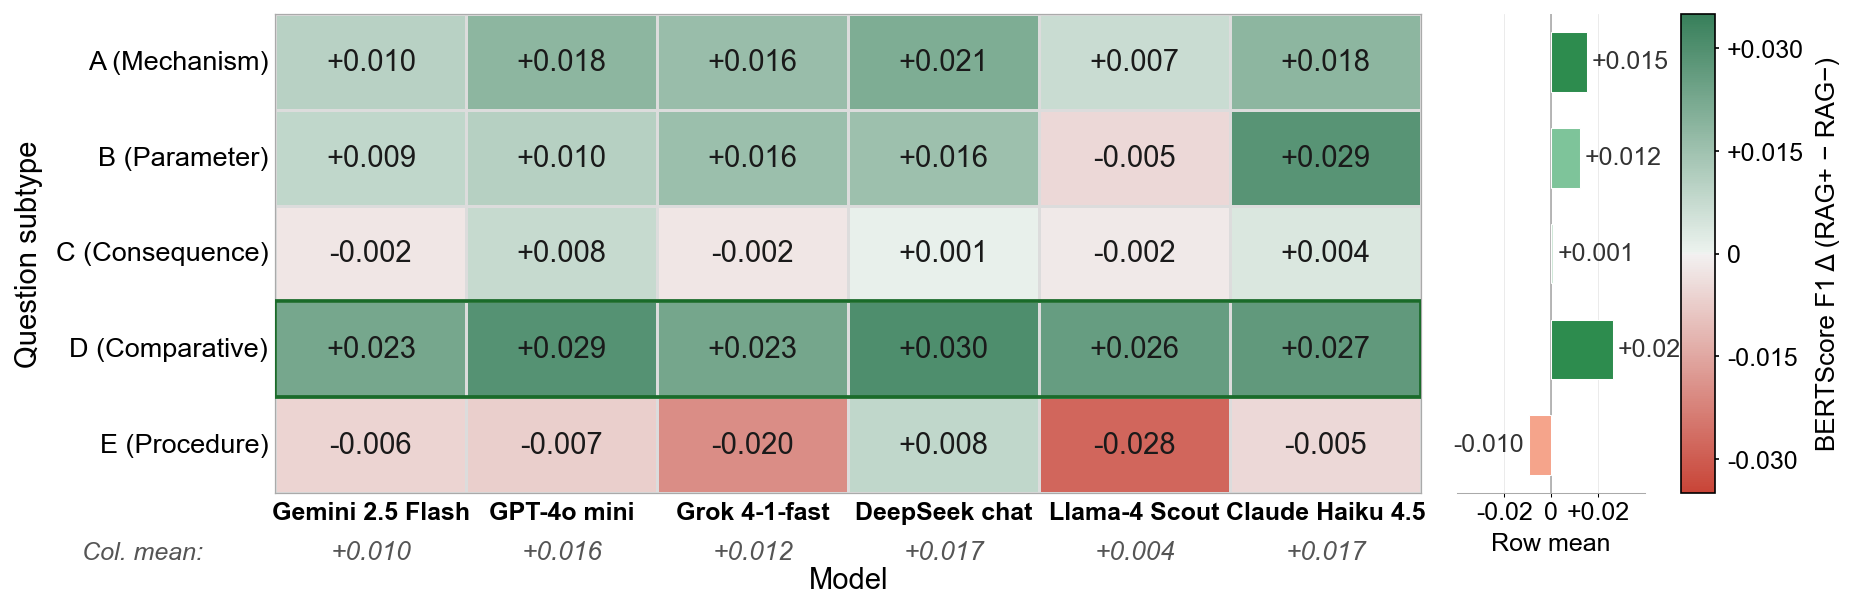

✓ Saved: fig_bertscore_heatmap.png

Column means (question-weighted, should match Table 2 aggregate Δ):
  gemini-2.5-flash           Δ = +0.0098
  gpt-4o-mini                Δ = +0.0157
  grok-4-1-fast              Δ = +0.0118
  deepseek-chat              Δ = +0.0169
  llama-4-scout-17b          Δ = +0.0042
  claude-haiku-4-5           Δ = +0.0173

Row means (unweighted across models):
  Subtype A  Δ = +0.0153
  Subtype B  Δ = +0.0123
  Subtype C  Δ = +0.0010
  Subtype D  Δ = +0.0264
  Subtype E  Δ = -0.0096

Per-model question count (n scored, both conditions):
model
gemini-2.5-flash     21
gpt-4o-mini          24
grok-4-1-fast        22
deepseek-chat        24
llama-4-scout-17b    24
claude-haiku-4-5     21
dtype: int64


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Publication rcParams ───────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":        14,
    "axes.titlesize":   15,
    "axes.labelsize":   14,
    "xtick.labelsize":  12,
    "ytick.labelsize":  13,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})

# ── Data ───────────────────────────────────────────────────────────────────
models = [
    "Gemini 2.5 Flash", "GPT-4o mini", "Grok 4-1-fast",
    "DeepSeek chat", "Llama-4 Scout", "Claude Haiku 4.5",
]

subtypes = [
    "A (Mechanism)", "B (Parameter)", "C (Consequence)",
    "D (Comparative)", "E (Procedure)",
]

# Load from CSV — source of truth for Zenodo deposit
_model_order   = ["gemini-2.5-flash","gpt-4o-mini","grok-4-1-fast",
                  "deepseek-chat","llama-4-scout-17b","claude-haiku-4-5"]
_subtype_order = ["A","B","C","D","E"]

csv_path = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\zenodo\stage2_bertscore_cosine_per_question.csv"
_df = pd.read_csv(csv_path)

# Heatmap cells: mean delta per (subtype, model) — unchanged
_pivot = _df.pivot_table(index="subtype_code", columns="model",
                         values="bertscore_f1_delta", aggfunc="mean")
delta_matrix = _pivot.loc[_subtype_order, _model_order].values

# Row means — unweighted across models (each model = unit of analysis)
row_means = delta_matrix.mean(axis=1)

# Column means — QUESTION-WEIGHTED per model (matches Table 2 aggregate Δ).
# Computed directly from per-question deltas, NOT from the 5 subtype-cell means,
# so that subtype-size imbalance (A=8, B=7, C=5, D=5, E=3) and refusal-driven
# coverage differences propagate correctly into the per-model summary.
col_means = (
    _df.groupby("model")["bertscore_f1_delta"]
       .mean()
       .reindex(_model_order)
       .values
)

# ── Layout: GridSpec — heatmap | row-mean bar | colorbar ──────────────────
fig = plt.figure(figsize=(12, 4.2))
gs = GridSpec(
    1, 3,
    figure=fig,
    width_ratios=[6, 0.98, 0.18],
    wspace=0.08,
    left=0.13, right=0.93, top=0.92, bottom=0.16
)
ax_heat = fig.add_subplot(gs[0, 0])
ax_bar  = fig.add_subplot(gs[0, 1])
ax_cbar = fig.add_subplot(gs[0, 2])

# ── Colour scale ───────────────────────────────────────────────────────────
vmax = 0.035
cmap = sns.diverging_palette(15, 145, s=75, l=48, as_cmap=True)

# ── Heatmap ────────────────────────────────────────────────────────────────
sns.heatmap(
    delta_matrix,
    ax          = ax_heat,
    cmap        = cmap,
    vmin        = -vmax,
    vmax        = +vmax,
    center      = 0,
    annot       = np.where(delta_matrix >= 0,
                    [[f"+{v:.3f}" for v in row] for row in delta_matrix.round(3)],
                    [[f"{v:.3f}"  for v in row] for row in delta_matrix.round(3)]),
    fmt         = "",
    annot_kws   = {"size": 14, "weight": "normal", "color": "#1a1a1a"},
    linewidths  = 0.5,
    linecolor   = "#dcdcdc",
    cbar        = False,
    xticklabels = models,
    yticklabels = subtypes,
)

# Green border around row D (index 3) — strongest & most consistent RAG effect
rect_d = mpatches.FancyBboxPatch(
    (0, 3), len(models), 1,
    boxstyle    = "square,pad=0",
    linewidth   = 1.8,
    edgecolor   = "#1a6b2a",
    facecolor   = "none",
    zorder      = 5,
)
ax_heat.add_patch(rect_d)

# Column-mean annotation below x-axis ticks (now question-weighted)
for j, cm_val in enumerate(col_means):
    sign = "+" if cm_val >= 0 else ""
    ax_heat.text(
        j + 0.5, 5.62,
        f"{sign}{cm_val:.3f}",
        ha="center", va="center",
        fontsize=12.5, color="#555555", style="italic"
    )
ax_heat.text(
    -0.38, 5.62,
    "Col. mean:",
    ha="right", va="center",
    fontsize=12, color="#555555", style="italic"
)

ax_heat.set_xlabel("Model", fontsize=14, labelpad=20)
ax_heat.set_ylabel("Question subtype", fontsize=14, labelpad=6)
ax_heat.tick_params(axis="x", length=0, pad=4, rotation=0)
ax_heat.tick_params(axis="y", length=0, rotation=0)

for lbl in ax_heat.get_xticklabels():
    lbl.set_fontweight("bold")

for sp in ax_heat.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.6)
    sp.set_color("#aaaaaa")

# ── Row-mean horizontal bar chart ─────────────────────────────────────────
bar_colors = [
    "#2d8c4e" if v >= 0.015 else
    "#7ec49a" if v >= 0.005 else
    "#f5a48b" if v < 0     else
    "#d0e8d8"
    for v in row_means
]
ypos = np.arange(len(subtypes)) + 0.5
ax_bar.barh(
    ypos, row_means,
    height    = 0.62,
    color     = bar_colors,
    edgecolor = "white",
    linewidth = 0.5,
    zorder    = 3,
)
ax_bar.axvline(0, color="#aaaaaa", linewidth=0.8, zorder=2)
ax_bar.set_xlim(-0.040, 0.040)
ax_bar.set_ylim(0, len(subtypes))
ax_bar.invert_yaxis()
ax_bar.set_yticks([])
ax_bar.set_xticks([-0.02, 0, +0.02])
ax_bar.set_xticklabels(["-0.02", "0", "+0.02"], fontsize=12)
ax_bar.set_xlabel("Row mean", fontsize=12, labelpad=4)
ax_bar.tick_params(axis="x", length=2, width=0.5, pad=2)
for sp in ["top", "right", "left"]:
    ax_bar.spines[sp].set_visible(False)
ax_bar.spines["bottom"].set_linewidth(0.5)
ax_bar.spines["bottom"].set_color("#aaaaaa")
ax_bar.grid(axis="x", linewidth=0.4, color="#e8e8e8", zorder=1)

# Value labels on bars
for y, v in zip(ypos, row_means):
    sign = "+" if v >= 0 else ""
    ax_bar.text(
        v + (0.002 if v >= 0 else -0.002),
        y,
        f"{sign}{v:.3f}",
        ha  = "left" if v >= 0 else "right",
        va  = "center",
        fontsize = 12,
        color    = "#333333",
    )

# ── Colorbar ───────────────────────────────────────────────────────────────
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, cax=ax_cbar, orientation="vertical")
cbar.set_ticks([-0.03, -0.015, 0, +0.015, +0.03])
cbar.set_ticklabels(["-0.030", "-0.015", "0", "+0.015", "+0.030"])
cbar.ax.tick_params(labelsize=12, length=2)
cbar.set_label("BERTScore F1 Δ (RAG+ − RAG−)", fontsize=12.5, labelpad=6)

# ── Save ───────────────────────────────────────────────────────────────────
plt.savefig("fig_bertscore_heatmap.png", bbox_inches="tight", dpi=300, facecolor="white")
plt.show()
print("✓ Saved: fig_bertscore_heatmap.png")

# ── Verification ───────────────────────────────────────────────────────────
print("\nColumn means (question-weighted, should match Table 2 aggregate Δ):")
for m, v in zip(_model_order, col_means):
    print(f"  {m:25s}  Δ = {v:+.4f}")

print("\nRow means (unweighted across models):")
for s, v in zip(_subtype_order, row_means):
    print(f"  Subtype {s}  Δ = {v:+.4f}")

# Per-model question count (sanity check vs. Table S3)
print("\nPer-model question count (n scored, both conditions):")
print(_df.groupby("model").size().reindex(_model_order))

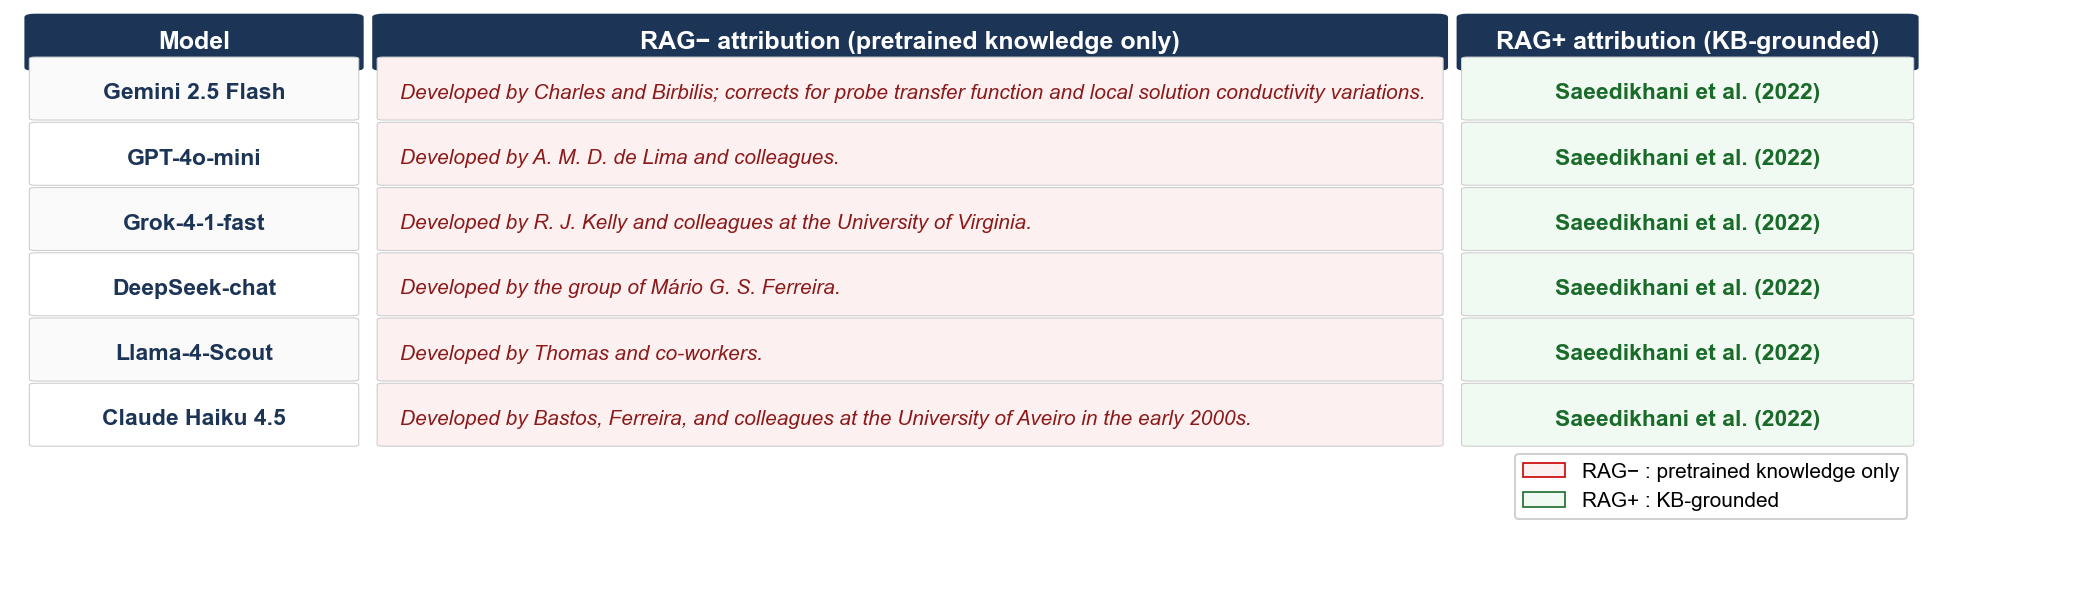

✓ Saved: table_sd_q24_hallucination.pdf + .png


In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── Data ───────────────────────────────────────────────────────────────────
hallucination_data = [
    {
        "model":     "Gemini 2.5 Flash",
        "rag_minus": "Developed by Charles and Birbilis; corrects for probe transfer function and local solution conductivity variations.",
        "rag_plus":  "Saeedikhani et al. (2022)",
    },
    {
        "model":     "GPT-4o-mini",
        "rag_minus": "Developed by A. M. D. de Lima and colleagues.",
        "rag_plus":  "Saeedikhani et al. (2022)",
    },
    {
        "model":     "Grok-4-1-fast",
        "rag_minus": "Developed by R. J. Kelly and colleagues at the University of Virginia.",
        "rag_plus":  "Saeedikhani et al. (2022)",
    },
    {
        "model":     "DeepSeek-chat",
        "rag_minus": "Developed by the group of Mário G. S. Ferreira.",
        "rag_plus":  "Saeedikhani et al. (2022)",
    },
    {
        "model":     "Llama-4-Scout",
        "rag_minus": "Developed by Thomas and co-workers.",
        "rag_plus":  "Saeedikhani et al. (2022)",
    },
    {
        "model":     "Claude Haiku 4.5",
        "rag_minus": "Developed by Bastos, Ferreira, and colleagues at the University of Aveiro in the early 2000s.",
        "rag_plus":  "Saeedikhani et al. (2022)",
    },
]

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4.2))
ax.axis("off")

col_labels = ["Model", "RAG− attribution (pretrained knowledge only)", "RAG+ attribution (KB-grounded)"]
col_widths = [0.16, 0.52, 0.22]
col_x      = [0.01, 0.18, 0.71]
row_height = 0.115
header_y   = 0.97

# ── Palette ────────────────────────────────────────────────────────────────
HDR_BG       = "#1c3557"
HDR_FG       = "white"
RAG_MINUS_BG = "#fdf0f0"
RAG_PLUS_BG  = "#f0faf2"
ALT_BG       = "#fafafa"
BORDER       = "#cccccc"

# ── Header row ─────────────────────────────────────────────────────────────
for label, x, w in zip(col_labels, col_x, col_widths):
    rect = FancyBboxPatch(
        (x, header_y - 0.045), w - 0.005, 0.088,
        boxstyle="round,pad=0.005",
        linewidth=0.8, edgecolor=HDR_BG, facecolor=HDR_BG,
        transform=ax.transAxes, clip_on=False
    )
    ax.add_patch(rect)
    ax.text(
        x + (w - 0.005) / 2, header_y, label,
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=12, fontweight="bold", color=HDR_FG
    )

# ── Data rows ──────────────────────────────────────────────────────────────
for i, row in enumerate(hallucination_data):
    y = header_y - 0.09 - i * row_height

    for j, (x, w) in enumerate(zip(col_x, col_widths)):
        bg = RAG_MINUS_BG if j == 1 else RAG_PLUS_BG if j == 2 else (ALT_BG if i % 2 == 0 else "white")
        rect = FancyBboxPatch(
            (x, y - 0.045), w - 0.005, row_height - 0.01,
            boxstyle="round,pad=0.003",
            linewidth=0.5, edgecolor=BORDER, facecolor=bg,
            transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(rect)

    ax.text(
        col_x[0] + (col_widths[0] - 0.005) / 2, y, row["model"],
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=11, fontweight="bold", color="#1c3557"
    )
    ax.text(
        col_x[1] + 0.008, y, row["rag_minus"],
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=10, fontstyle="italic", color="#8b1a1a"
    )
    ax.text(
        col_x[2] + (col_widths[2] - 0.005) / 2, y, row["rag_plus"],
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=11, fontweight="bold", color="#1a6b2a"
    )

# ── Legend ─────────────────────────────────────────────────────────────────
minus_patch = mpatches.Patch(facecolor=RAG_MINUS_BG, edgecolor="#cc0000",
                              linewidth=0.8, label="RAG− : pretrained knowledge only")
plus_patch  = mpatches.Patch(facecolor=RAG_PLUS_BG,  edgecolor="#1a6b2a",
                              linewidth=0.8, label="RAG+ : KB-grounded")
ax.legend(
    handles=[minus_patch, plus_patch],
    loc="lower right", bbox_to_anchor=(0.93, 0.11),
    fontsize=10, framealpha=0.9, edgecolor="#cccccc"
)

plt.tight_layout()

plt.savefig("table_sd_q24_hallucination.png", bbox_inches="tight", dpi=300)
plt.show()
print("✓ Saved: table_sd_q24_hallucination.pdf + .png")

In [82]:
import numpy as np
from scipy.stats import chi2
import warnings

# ── BERTScore win/loss data per model ─────────────────────────────────────
# For each answered question: 1 = RAG+ wins (Δ > +0.01), 0 = tie/RAG- wins
# Source: per-question BERTScore results from all 6 scoring cells

results = {
    "Gemini 2.5 Flash": {
        "n_answered": 21,
        # (question_id, rag_plus_f1, rag_minus_f1)
        "scores": [
            ("Q01", 0.915, 0.898), ("Q02", 0.891, 0.881), ("Q03", 0.867, 0.899),
            ("Q04", 0.902, 0.912), ("Q05", 0.874, 0.879), ("Q06", 0.927, 0.875),
            ("Q07", 0.903, 0.876), ("Q08", 0.892, 0.870), ("Q10", 0.921, 0.884),
            ("Q12", 0.902, 0.898), ("Q13", 0.891, 0.906), ("Q16", 0.883, 0.919),
            ("Q17", 0.895, 0.890), ("Q18", 0.906, 0.903), ("Q19", 0.923, 0.904),
            ("Q21", 0.928, 0.898), ("Q22", 0.891, 0.875), ("Q23", 0.897, 0.888),
            ("Q24", 0.929, 0.871), ("Q25", 0.905, 0.904), ("Q26", 0.891, 0.897),
        ]
    },
    "GPT-4o-mini": {
        "n_answered": 24,
        "scores": [
            ("Q01", 0.891, 0.879), ("Q02", 0.889, 0.857), ("Q03", 0.868, 0.860),
            ("Q04", 0.911, 0.888), ("Q05", 0.874, 0.871), ("Q06", 0.893, 0.868),
            ("Q07", 0.916, 0.890), ("Q08", 0.893, 0.874), ("Q09", 0.886, 0.900),
            ("Q10", 0.933, 0.889), ("Q12", 0.913, 0.894), ("Q13", 0.903, 0.915),
            ("Q14", 0.937, 0.922), ("Q16", 0.896, 0.891), ("Q17", 0.895, 0.883),
            ("Q18", 0.905, 0.898), ("Q19", 0.932, 0.908), ("Q20", 0.872, 0.882),
            ("Q21", 0.905, 0.872), ("Q22", 0.911, 0.857), ("Q23", 0.887, 0.880),
            ("Q24", 0.903, 0.856), ("Q25", 0.895, 0.890), ("Q26", 0.893, 0.900),
        ]
    },
    "Grok-4-1-fast": {
        "n_answered": 22,
        "scores": [
            ("Q01", 0.923, 0.884), ("Q02", 0.870, 0.859), ("Q03", 0.855, 0.879),
            ("Q04", 0.877, 0.871), ("Q05", 0.872, 0.873), ("Q06", 0.901, 0.871),
            ("Q07", 0.912, 0.873), ("Q08", 0.895, 0.865), ("Q10", 0.919, 0.872),
            ("Q12", 0.909, 0.896), ("Q13", 0.892, 0.905), ("Q16", 0.893, 0.899),
            ("Q17", 0.883, 0.879), ("Q18", 0.912, 0.908), ("Q19", 0.920, 0.910),
            ("Q20", 0.855, 0.879), ("Q21", 0.919, 0.887), ("Q22", 0.904, 0.900),
            ("Q23", 0.864, 0.861), ("Q24", 0.943, 0.857), ("Q25", 0.898, 0.908),
            ("Q26", 0.876, 0.896),
        ]
    },
    "DeepSeek-chat": {
        "n_answered": 24,
        "scores": [
            ("Q01", 0.930, 0.894), ("Q02", 0.886, 0.861), ("Q03", 0.878, 0.888),
            ("Q04", 0.915, 0.908), ("Q05", 0.879, 0.868), ("Q06", 0.902, 0.876),
            ("Q07", 0.915, 0.872), ("Q08", 0.904, 0.872), ("Q09", 0.894, 0.907),
            ("Q10", 0.930, 0.872), ("Q12", 0.922, 0.897), ("Q13", 0.901, 0.909),
            ("Q16", 0.883, 0.920), ("Q17", 0.899, 0.873), ("Q18", 0.918, 0.920),
            ("Q19", 0.928, 0.904), ("Q20", 0.873, 0.879), ("Q21", 0.915, 0.863),
            ("Q22", 0.911, 0.891), ("Q23", 0.899, 0.882), ("Q24", 0.930, 0.853),
            ("Q25", 0.901, 0.915), ("Q26", 0.892, 0.889), ("Q28", 0.920, 0.906),
        ]
    },
    "Llama-4-Scout": {
        "n_answered": 24,
        "scores": [
            ("Q01", 0.898, 0.870), ("Q02", 0.856, 0.866), ("Q03", 0.865, 0.858),
            ("Q04", 0.879, 0.906), ("Q05", 0.874, 0.876), ("Q06", 0.898, 0.882),
            ("Q07", 0.896, 0.876), ("Q08", 0.902, 0.878), ("Q10", 0.908, 0.886),
            ("Q12", 0.905, 0.894), ("Q13", 0.836, 0.901), ("Q14", 0.923, 0.911),
            ("Q16", 0.896, 0.913), ("Q17", 0.901, 0.884), ("Q18", 0.898, 0.913),
            ("Q19", 0.916, 0.891), ("Q20", 0.856, 0.875), ("Q21", 0.925, 0.879),
            ("Q22", 0.907, 0.882), ("Q23", 0.898, 0.872), ("Q24", 0.909, 0.866),
            ("Q25", 0.890, 0.901), ("Q26", 0.871, 0.885), ("Q27", 0.862, 0.904),
        ]
    },
    "Claude Haiku 4.5": {
        "n_answered": 21,
        "scores": [
            ("Q01", 0.925, 0.886), ("Q02", 0.889, 0.871), ("Q03", 0.866, 0.880),
            ("Q04", 0.884, 0.893), ("Q06", 0.910, 0.874), ("Q07", 0.901, 0.875),
            ("Q08", 0.914, 0.881), ("Q10", 0.916, 0.866), ("Q12", 0.910, 0.877),
            ("Q13", 0.892, 0.889), ("Q16", 0.889, 0.888), ("Q17", 0.899, 0.880),
            ("Q18", 0.908, 0.907), ("Q19", 0.924, 0.902), ("Q20", 0.859, 0.883),
            ("Q21", 0.907, 0.892), ("Q22", 0.901, 0.880), ("Q23", 0.905, 0.877),
            ("Q24", 0.912, 0.843), ("Q25", 0.910, 0.908), ("Q26", 0.886, 0.891),
        ]
    },
}

THRESHOLD = 0.01   # same as scoring cells

def mcnemar_test(scores, threshold=0.01):
    """
    b = questions where RAG+ wins  (fp - fm >  threshold)
    c = questions where RAG- wins  (fm - fp >  threshold)
    McNemar χ² with Yates continuity correction, df=1
    """
    b = sum(1 for _, fp, fm in scores if fp - fm >  threshold)
    c = sum(1 for _, fp, fm in scores if fm - fp >  threshold)
    n = b + c
    if n == 0:
        return b, c, np.nan, np.nan, "n/a"
    stat = (abs(b - c) - 1) ** 2 / (b + c)
    p    = 1 - chi2.cdf(stat, df=1)
    sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    return b, c, stat, p, sig
    
# ── Alternative: sign test on raw Δ ───────────────────────────────────────
def sign_test(scores):
    """
    Counts how many questions RAG+ > RAG- (wins) vs RAG- > RAG+ (losses).
    Uses exact binomial sign test under H0: P(win) = 0.5.
    """
    from scipy.stats import binomtest   # ← replaces deprecated binom_test
    wins   = sum(1 for _, fp, fm in scores if fp - fm > THRESHOLD)
    losses = sum(1 for _, fp, fm in scores if fm - fp > THRESHOLD)
    n_disc = wins + losses
    if n_disc == 0:
        return wins, losses, np.nan, "n/a"
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = binomtest(wins, n_disc, p=0.5, alternative="greater")
        p = result.pvalue
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    return wins, losses, p, sig
    
# ── Print results ──────────────────────────────────────────────────────────
print("=" * 78)
print("  STATISTICAL ANALYSIS — RAG+ vs RAG− (BERTScore F1)")
print("  McNemar's test (continuity-corrected) + Sign test")
print("  H₀: RAG condition has no effect on response accuracy")
print("=" * 78)

print(f"\n{'Model':<22} {'n':>3}  {'b':>3} {'c':>3}  {'χ²':>6}  {'p (McNemar)':>12}  {'Sig':>4}  "
      f"{'Wins':>4} {'Loss':>4}  {'p (Sign)':>10}  {'Sig':>4}")
print("-" * 78)

all_b, all_c, all_scores_flat = 0, 0, []
for model_name, data in results.items():
    scores = data["scores"]
    b, c, stat, p_mc, sig_mc   = mcnemar_test(scores)
    wins, losses, p_sign, sig_s = sign_test(scores)
    n = len(scores)

    all_b += b
    all_c += c
    all_scores_flat.extend(scores)

    p_mc_str   = f"{p_mc:.4f}"   if not np.isnan(p_mc)   else "  n/a  "
    stat_str   = f"{stat:.3f}"   if not np.isnan(stat)    else "  n/a"
    p_sign_str = f"{p_sign:.4f}" if not np.isnan(p_sign)  else "  n/a  "

    print(f"  {model_name:<20} {n:>3}  {b:>3} {c:>3}  {stat_str:>6}  "
          f"{p_mc_str:>12}  {sig_mc:>4}  "
          f"{wins:>4} {losses:>4}  {p_sign_str:>10}  {sig_s:>4}")

# ── Pooled analysis ────────────────────────────────────────────────────────
print("-" * 78)
_, _, stat_pool, p_pool, sig_pool = mcnemar_test(all_scores_flat)
wins_pool, losses_pool, p_sign_pool, sig_pool_s = sign_test(all_scores_flat)
n_pool = len(all_scores_flat)

print(f"  {'POOLED (all models)':<20} {n_pool:>3}  {all_b:>3} {all_c:>3}  "
      f"{stat_pool:>6.3f}  {p_pool:>12.4f}  {sig_pool:>4}  "
      f"{wins_pool:>4} {losses_pool:>4}  {p_sign_pool:>10.4f}  {sig_pool_s:>4}")

print("=" * 78)
print("\n  Legend:")
print("  b       = questions where RAG+ correct, RAG- wrong (discordant, RAG+ favoured)")
print("  c       = questions where RAG- correct, RAG+ wrong (discordant, RAG- favoured)")
print("  McNemar = χ² with Yates continuity correction, df=1")
print("  Sign    = exact binomial sign test, H₁: P(RAG+ win) > 0.5")
print("  Threshold for 'correct': BERTScore F1 > 0.89  (=1 − THRESHOLD)")
print("  *** p<0.001  ** p<0.01  * p<0.05  n.s. not significant")

# ── Per-subtype pooled sign test ───────────────────────────────────────────
print(f"\n── Per-subtype sign test (pooled across all models) ─────────────────")
print(f"  {'Subtype':<32} {'Wins':>4} {'Loss':>4}  {'p':>8}  {'Sig':>4}")
print("-" * 55)

subtype_map = {
    "A": ["Q01","Q02","Q03","Q04","Q05","Q06","Q07","Q08"],
    "B": ["Q09","Q10","Q11","Q12","Q13","Q14","Q15"],
    "C": ["Q16","Q17","Q18","Q19","Q20"],
    "D": ["Q21","Q22","Q23","Q24","Q25"],
    "E": ["Q26","Q27","Q28"],
}
subtype_labels = {
    "A": "Mechanism explanation",
    "B": "Parameter justification",
    "C": "Consequence of error",
    "D": "Comparative / technique",
    "E": "Procedure rationale",
}

for s, qids in sorted(subtype_map.items()):
    sub_scores = [row for row in all_scores_flat if row[0] in qids]
    if not sub_scores:
        continue
    wins, losses, p_s, sig_s = sign_test(sub_scores)
    p_str = f"{p_s:.4f}" if not np.isnan(p_s) else "  n/a"
    label = f"[{s}] {subtype_labels[s]}"
    print(f"  {label:<32} {wins:>4} {losses:>4}  {p_str:>8}  {sig_s:>4}")

print("=" * 78)

  STATISTICAL ANALYSIS — RAG+ vs RAG− (BERTScore F1)
  McNemar's test (continuity-corrected) + Sign test
  H₀: RAG condition has no effect on response accuracy

Model                    n    b   c      χ²   p (McNemar)   Sig  Wins Loss    p (Sign)   Sig
------------------------------------------------------------------------------
  Gemini 2.5 Flash      21   10   4   1.786        0.1814  n.s.    10    4      0.0898  n.s.
  GPT-4o-mini           24   14   3   5.882        0.0153     *    14    3      0.0064    **
  Grok-4-1-fast         22   10   5   1.067        0.3017  n.s.    10    5      0.1509  n.s.
  DeepSeek-chat         24   15   4   5.263        0.0218     *    15    4      0.0096    **
  Llama-4-Scout         24   13   9   0.409        0.5224  n.s.    13    9      0.2617  n.s.
  Claude Haiku 4.5      21   13   2   6.667        0.0098    **    13    2      0.0037    **
------------------------------------------------------------------------------
  POOLED (all models)  136   7

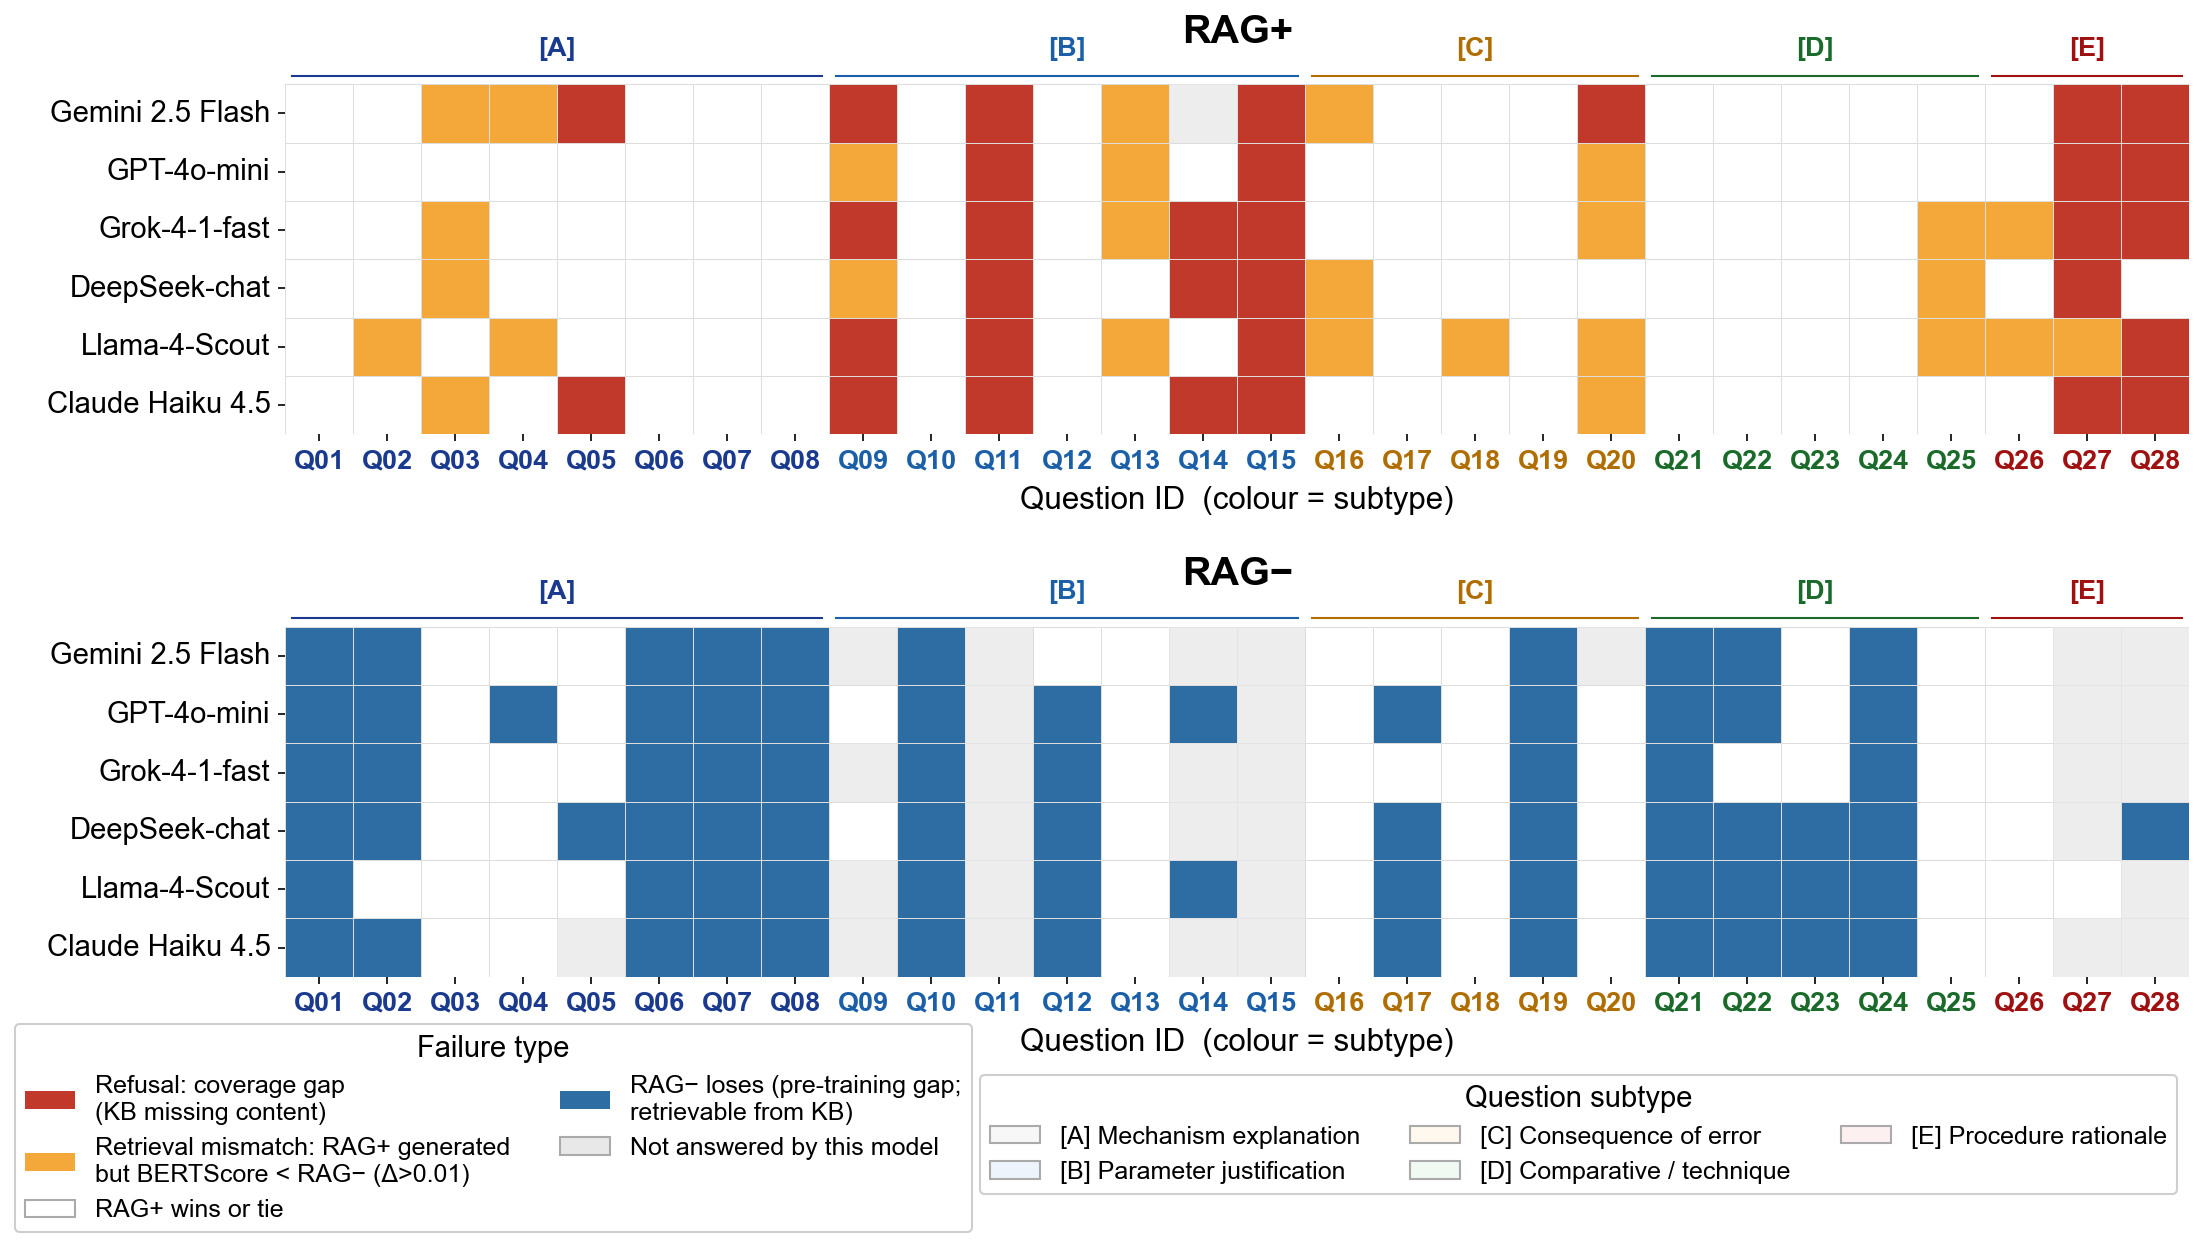

Saved: stage2_kb_gap_heatmap.png / .pdf


In [54]:
"""
SVET Benchmark — Stage 2 KB Gap Heatmap
Analogue of Stage 1 Fig. 1 (per-question error frequency heatmap).

Left panel  (RAG+):  failure type per (model × question)
    1.0  = REFUSAL — model returned "context insufficient"  →  coverage gap
    0.5  = RETRIEVAL MISMATCH — RAG+ generated but BERTScore < RAG− (Δ > 0.01)
    0.0  = RAG+ win / no failure

Right panel (RAG−):  retrieval-addressable gaps (RAG− loses where RAG+ wins)
    1.0  = RAG− lost to RAG+ (BERTScore Δ > 0.01)  →  pre-training gap
    0.0  = RAG− win or tie

Questions appearing only/mainly in the RAG− panel  = retrievable gaps
  (KB has coverage; pretraining alone insufficient)
Questions with failures in BOTH panels            = intrinsic / retrieval-resistant
Questions with refusals in RAG+ panel             = coverage gaps (KB missing content)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import seaborn as sns
import pandas as pd
from collections import defaultdict

# ── Global font-size controls ──────────────────────────────────────────────
FS_TITLE         = 19   # panel titles: RAG+ / RAG−
FS_XLABEL        = 15   # x-axis label
FS_YLABEL        = 15   # y-axis label if you add one later
FS_XTICKS        = 13   # question IDs on x-axis
FS_YTICKS        = 14   # model names on y-axis
FS_SUBTYPE_TAG   = 13   # [A] [B] [C] labels above columns
FS_LEGEND        = 12   # legend text
FS_LEGEND_TITLE  = 14   # legend titles

# ── Source data ───────────────────────────────────────────────────────────────
# Per-question BERTScore F1 (model, question_id, rag_plus_f1, rag_minus_f1)
THRESHOLD = 0.01

all_scores_by_model = {
    "Gemini 2.5 Flash": [
        ("Q01","A",0.915,0.898), ("Q02","A",0.891,0.881), ("Q03","A",0.867,0.899),
        ("Q04","A",0.902,0.912), ("Q05","A",0.874,0.879), ("Q06","A",0.927,0.875),
        ("Q07","A",0.903,0.876), ("Q08","A",0.892,0.870), ("Q10","B",0.921,0.884),
        ("Q12","B",0.902,0.898), ("Q13","B",0.891,0.906), ("Q16","C",0.883,0.919),
        ("Q17","C",0.895,0.890), ("Q18","C",0.906,0.903), ("Q19","C",0.923,0.904),
        ("Q21","D",0.928,0.898), ("Q22","D",0.891,0.875), ("Q23","D",0.897,0.888),
        ("Q24","D",0.929,0.871), ("Q25","D",0.905,0.904), ("Q26","E",0.891,0.897),
    ],
    "GPT-4o-mini": [
        ("Q01","A",0.891,0.879), ("Q02","A",0.889,0.857), ("Q03","A",0.868,0.860),
        ("Q04","A",0.911,0.888), ("Q05","A",0.874,0.871), ("Q06","A",0.893,0.868),
        ("Q07","A",0.916,0.890), ("Q08","A",0.893,0.874), ("Q09","B",0.886,0.900),
        ("Q10","B",0.933,0.889), ("Q12","B",0.913,0.894), ("Q13","B",0.903,0.915),
        ("Q14","B",0.937,0.922), ("Q16","C",0.896,0.891), ("Q17","C",0.895,0.883),
        ("Q18","C",0.905,0.898), ("Q19","C",0.932,0.908), ("Q20","C",0.872,0.882),
        ("Q21","D",0.905,0.872), ("Q22","D",0.911,0.857), ("Q23","D",0.887,0.880),
        ("Q24","D",0.903,0.856), ("Q25","D",0.895,0.890), ("Q26","E",0.893,0.900),
    ],
    "Grok-4-1-fast": [
        ("Q01","A",0.923,0.884), ("Q02","A",0.870,0.859), ("Q03","A",0.855,0.879),
        ("Q04","A",0.877,0.871), ("Q05","A",0.872,0.873), ("Q06","A",0.901,0.871),
        ("Q07","A",0.912,0.873), ("Q08","A",0.895,0.865), ("Q10","B",0.919,0.872),
        ("Q12","B",0.909,0.896), ("Q13","B",0.892,0.905), ("Q16","C",0.893,0.899),
        ("Q17","C",0.883,0.879), ("Q18","C",0.912,0.908), ("Q19","C",0.920,0.910),
        ("Q20","C",0.855,0.879), ("Q21","D",0.919,0.887), ("Q22","D",0.904,0.900),
        ("Q23","D",0.864,0.861), ("Q24","D",0.943,0.857), ("Q25","D",0.898,0.908),
        ("Q26","E",0.876,0.896),
    ],
    "DeepSeek-chat": [
        ("Q01","A",0.930,0.894), ("Q02","A",0.886,0.861), ("Q03","A",0.878,0.888),
        ("Q04","A",0.915,0.908), ("Q05","A",0.879,0.868), ("Q06","A",0.902,0.876),
        ("Q07","A",0.915,0.872), ("Q08","A",0.904,0.872), ("Q09","B",0.894,0.907),
        ("Q10","B",0.930,0.872), ("Q12","B",0.922,0.897), ("Q13","B",0.901,0.909),
        ("Q16","C",0.883,0.920), ("Q17","C",0.899,0.873), ("Q18","C",0.918,0.920),
        ("Q19","C",0.928,0.904), ("Q20","C",0.873,0.879), ("Q21","D",0.915,0.863),
        ("Q22","D",0.911,0.891), ("Q23","D",0.899,0.882), ("Q24","D",0.930,0.853),
        ("Q25","D",0.901,0.915), ("Q26","E",0.892,0.889), ("Q28","E",0.920,0.906),
    ],
    "Llama-4-Scout": [
        ("Q01","A",0.898,0.870), ("Q02","A",0.856,0.866), ("Q03","A",0.865,0.858),
        ("Q04","A",0.879,0.906), ("Q05","A",0.874,0.876), ("Q06","A",0.898,0.882),
        ("Q07","A",0.896,0.876), ("Q08","A",0.902,0.878), ("Q10","B",0.908,0.886),
        ("Q12","B",0.905,0.894), ("Q13","B",0.836,0.901), ("Q14","B",0.923,0.911),
        ("Q16","C",0.896,0.913), ("Q17","C",0.901,0.884), ("Q18","C",0.898,0.913),
        ("Q19","C",0.916,0.891), ("Q20","C",0.856,0.875), ("Q21","D",0.925,0.879),
        ("Q22","D",0.907,0.882), ("Q23","D",0.898,0.872), ("Q24","D",0.909,0.866),
        ("Q25","D",0.890,0.901), ("Q26","E",0.871,0.885), ("Q27","E",0.862,0.904),
    ],
    "Claude Haiku 4.5": [
        ("Q01","A",0.925,0.886), ("Q02","A",0.889,0.871), ("Q03","A",0.866,0.880),
        ("Q04","A",0.884,0.893), ("Q06","A",0.910,0.874), ("Q07","A",0.901,0.875),
        ("Q08","A",0.914,0.881), ("Q10","B",0.916,0.866), ("Q12","B",0.910,0.877),
        ("Q13","B",0.892,0.889), ("Q16","C",0.889,0.888), ("Q17","C",0.899,0.880),
        ("Q18","C",0.908,0.907), ("Q19","C",0.924,0.902), ("Q20","C",0.859,0.883),
        ("Q21","D",0.907,0.892), ("Q22","D",0.901,0.880), ("Q23","D",0.905,0.877),
        ("Q24","D",0.912,0.843), ("Q25","D",0.910,0.908), ("Q26","E",0.886,0.891),
    ],
}

# RAG+ refusals per model (model returned "context insufficient")
refusals_by_model = {
    "Gemini 2.5 Flash":  ["Q05", "Q09", "Q11", "Q15", "Q20", "Q27", "Q28"],
    "GPT-4o-mini":       ["Q11", "Q15", "Q27", "Q28"],
    "Grok-4-1-fast":     ["Q09", "Q11", "Q14", "Q15", "Q27", "Q28"],
    "DeepSeek-chat":     ["Q11", "Q14", "Q15", "Q27"],
    "Llama-4-Scout":     ["Q09", "Q11", "Q15", "Q28"],
    "Claude Haiku 4.5":  ["Q05", "Q09", "Q11", "Q14", "Q15", "Q27", "Q28"],
}

# Subtype lookup (populated from BERTScore data + refusal data)
SUBTYPE_LOOKUP_BASE = {
    "Q01":"A","Q02":"A","Q03":"A","Q04":"A","Q05":"A","Q06":"A","Q07":"A","Q08":"A",
    "Q09":"B","Q10":"B","Q11":"B","Q12":"B","Q13":"B","Q14":"B","Q15":"B",
    "Q16":"C","Q17":"C","Q18":"C","Q19":"C","Q20":"C",
    "Q21":"D","Q22":"D","Q23":"D","Q24":"D","Q25":"D",
    "Q26":"E","Q27":"E","Q28":"E",
}

# ── Build failure matrices ─────────────────────────────────────────────────────
MODEL_ORDER = [
    "Gemini 2.5 Flash", "GPT-4o-mini", "Grok-4-1-fast",
    "DeepSeek-chat", "Llama-4-Scout", "Claude Haiku 4.5",
]

SUBTYPE_ORDER = {"A":0,"B":1,"C":2,"D":3,"E":4}

# Collect all questions that appear anywhere
all_qids_set = set()
for scores in all_scores_by_model.values():
    for qid, *_ in scores:
        all_qids_set.add(qid)
for qids in refusals_by_model.values():
    all_qids_set.update(qids)

all_qids = sorted(all_qids_set,
                  key=lambda q: (SUBTYPE_ORDER.get(SUBTYPE_LOOKUP_BASE.get(q,"Z"), 9),
                                 int(q.replace("Q",""))))

# Failure encoding:
#   NaN = question not attempted at all by this model (neither scored nor refused)
#   0.0 = RAG+ won (BERTScore Δ > +0.01)
#   0.5 = retrieval mismatch (RAG+ generated but lost: BERTScore Δ < −0.01)
#   1.0 = refusal (RAG+ returned "context insufficient")

rag_plus_matrix  = pd.DataFrame(np.nan, index=MODEL_ORDER, columns=all_qids)
rag_minus_matrix = pd.DataFrame(np.nan, index=MODEL_ORDER, columns=all_qids)

for model in MODEL_ORDER:
    scores = all_scores_by_model.get(model, [])
    refusals = set(refusals_by_model.get(model, []))

    for qid, subtype, fp, fm in scores:
        # RAG+ panel
        if qid in refusals:
            rag_plus_matrix.loc[model, qid] = 1.0       # refusal (shouldn't happen if in scores)
        elif fm - fp > THRESHOLD:                        # RAG− won
            rag_plus_matrix.loc[model, qid] = 0.5       # retrieval mismatch
        else:
            rag_plus_matrix.loc[model, qid] = 0.0       # RAG+ won

        # RAG− panel: show where RAG− lost (i.e., where RAG+ was better)
        if fp - fm > THRESHOLD:
            rag_minus_matrix.loc[model, qid] = 1.0      # RAG− lost = pre-training gap
        else:
            rag_minus_matrix.loc[model, qid] = 0.0      # RAG− won or tie

    # Now fill refusal-only questions (not in scored set)
    for qid in refusals:
        if pd.isna(rag_plus_matrix.loc[model, qid]):
            rag_plus_matrix.loc[model, qid] = 1.0       # pure refusal

# Keep only columns that have at least one non-zero entry in either panel
cols_ragplus  = rag_plus_matrix.columns[(rag_plus_matrix > 0).any(axis=0)]
cols_ragminus = rag_minus_matrix.columns[(rag_minus_matrix > 0).any(axis=0)]
all_shown_cols = sorted(
    set(cols_ragplus) | set(cols_ragminus),
    key=lambda q: (SUBTYPE_ORDER.get(SUBTYPE_LOOKUP_BASE.get(q,"Z"), 9),
                   int(q.replace("Q","")))
)

mat_plus  = rag_plus_matrix[all_shown_cols]
mat_minus = rag_minus_matrix[all_shown_cols]

# ── Colormaps ──────────────────────────────────────────────────────────────────
# RAG+ panel: 3-level  white / amber / dark red
cmap_plus = ListedColormap(['#ffffff', '#f4a83a', '#c0392b'])
norm_plus = BoundaryNorm([0.0, 0.25, 0.75, 1.01], ncolors=3)

# RAG− panel: 2-level  white / steel blue
cmap_minus = ListedColormap(['#ffffff', '#2e6da4'])
norm_minus = BoundaryNorm([0.0, 0.5, 1.01], ncolors=2)

# ── Subtype helpers ────────────────────────────────────────────────────────────
SUBTYPE_BG = {
    "A":"#f7f7f7","B":"#eef4fb","C":"#fff8ee","D":"#f0faf2","E":"#fdf0f0"
}
SUBTYPE_XCOLOR = {
    "A":"#1a3a8f","B":"#1a5fa8","C":"#b06d00","D":"#1a6b2a","E":"#a01010"
}
SUBTYPE_LABELS = {
    "A":"Mechanism explanation","B":"Parameter justification",
    "C":"Consequence of error","D":"Comparative / technique",
    "E":"Procedure rationale",
}

# ── Figure layout ──────────────────────────────────────────────────────────────
N  = len(all_shown_cols)
CW = 0.46   # cell width in inches
fig, axes = plt.subplots(
    2, 1,
    figsize=(CW * N + 3.5, 8.5),
    gridspec_kw={"hspace": 0.55}
)

def draw_panel(ax, mat, cmap, norm, title, show_ylab, show_cbar,
               cbar_ticks, cbar_labels, cbar_label_str):
    """Draw one heatmap panel."""
    # Subtype column backgrounds
    for j, q in enumerate(mat.columns):
        st = SUBTYPE_LOOKUP_BASE.get(q, "?")
        ax.add_patch(plt.Rectangle(
            (j, 0), 1, mat.shape[0],
            color=SUBTYPE_BG.get(st, "white"),
            alpha=0.30, zorder=0, linewidth=0
        ))

    # Heatmap (mask NaN)
    mask = mat.isna()
    sns.heatmap(
        mat.fillna(-1),  # -1 will be white via cmap if < 0 boundary
        ax=ax,
        cmap=cmap,
        norm=norm,
        linewidths=0.35,
        linecolor="#dddddd",
        cbar=False,
        mask=mask,
        xticklabels=True,
        yticklabels=show_ylab,
        annot=False,
    )

    # Grey out NaN cells
    for r in range(mat.shape[0]):
        for c in range(mat.shape[1]):
            if mask.iloc[r, c]:
                ax.add_patch(plt.Rectangle(
                    (c, r), 1, 1,
                    color="#e8e8e8", alpha=0.7, zorder=5, linewidth=0
                ))

    # Subtype bracket labels above columns
    subtype_seq = [SUBTYPE_LOOKUP_BASE.get(q, "?") for q in mat.columns]
    prev_st, st_start = subtype_seq[0], 0
    for i, st in enumerate(subtype_seq + ["_END_"]):
        if st != prev_st:
            mid = (st_start + i) / 2
            ax.text(mid, -0.4, f"[{prev_st}]",
                ha="center", va="bottom",
                fontsize=FS_SUBTYPE_TAG, fontweight="bold",
                color=SUBTYPE_XCOLOR.get(prev_st, "#333"),
                transform=ax.transData)
            # Draw thin bracket line
            ax.plot([st_start + 0.1, i - 0.1], [-0.15, -0.15],
                    color=SUBTYPE_XCOLOR.get(prev_st, "#333"),
                    lw=1.0, transform=ax.transData, clip_on=False)
            st_start = i
            prev_st = st

    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=20)
    ax.set_xlabel("Question ID  (colour = subtype)", fontsize=FS_XLABEL, labelpad=6)
    ax.tick_params(axis="x", labelsize=FS_XTICKS, rotation=0)
    ax.tick_params(axis="y", labelsize=FS_YTICKS)

    if show_ylab:
        ax.set_ylabel("")
    else:
        ax.set_ylabel("")

    # Colour-code x tick labels by subtype
    for tick, q in zip(ax.get_xticklabels(), mat.columns):
        tick.set_color(SUBTYPE_XCOLOR.get(SUBTYPE_LOOKUP_BASE.get(q, "?"), "#333"))
        tick.set_fontweight("bold")

draw_panel(
    axes[0], mat_plus,
    cmap_plus, norm_plus,
    title="RAG+",
    show_ylab=True,
    show_cbar=False,
    cbar_ticks=[0.125, 0.5, 0.875],
    cbar_labels=["RAG+ wins", "Retrieval\nmismatch", "Refusal\n(coverage gap)"],
    cbar_label_str="RAG+ failure type",
)

draw_panel(
    axes[1], mat_minus,
    cmap_minus, norm_minus,
    title="RAG−",
    show_ylab=True,
    show_cbar=False,
    cbar_ticks=[0.25, 0.75],
    cbar_labels=["RAG− wins\nor tie", "RAG− loses\n(pre-training gap)"],
    cbar_label_str="RAG− outcome",
)

# ── Manual legend patches ─────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(facecolor="#c0392b", label="Refusal: coverage gap\n(KB missing content)"),
    mpatches.Patch(facecolor="#f4a83a", label="Retrieval mismatch: RAG+ generated\nbut BERTScore < RAG− (Δ>0.01)"),
    mpatches.Patch(facecolor="#ffffff", edgecolor="#aaa", label="RAG+ wins or tie"),
    mpatches.Patch(facecolor="#2e6da4", label="RAG− loses (pre-training gap;\nretrievable from KB)"),
    mpatches.Patch(facecolor="#e8e8e8", edgecolor="#aaa", label="Not answered by this model"),
]

subtype_patches = [
    mpatches.Patch(facecolor=SUBTYPE_BG[s], edgecolor="#aaa",
                   label=f"[{s}] {SUBTYPE_LABELS[s]}", alpha=1)
    for s in ["A","B","C","D","E"]
]

# REPLACE the entire legend block (both leg1 and axes[1].legend) with:

leg1 = fig.legend(
    handles=legend_patches,
    title="Failure type",
    loc="lower left",
    fontsize=FS_LEGEND,
    title_fontsize=FS_LEGEND_TITLE,
    framealpha=0.95,
    edgecolor="#cccccc",
    bbox_to_anchor=(0.01, -0.03),
    ncol=2,
    bbox_transform=fig.transFigure,
)
leg2 = fig.legend(
    handles=subtype_patches,
    title="Question subtype",
    loc="lower right",
    fontsize=FS_LEGEND,
    title_fontsize=FS_LEGEND_TITLE,
    framealpha=0.95,
    edgecolor="#cccccc",
    bbox_to_anchor=(0.9, 0),
    ncol=3,
    bbox_transform=fig.transFigure,
)

plt.subplots_adjust(bottom=0.18)

plt.savefig(r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\stage2_kb_gap_heatmap.png", bbox_inches="tight", dpi=300)

plt.show()
print("Saved: stage2_kb_gap_heatmap.png / .pdf")

# perplexity as a judge

In [106]:
from dotenv import load_dotenv
import os, csv, time, random
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)
from openai import OpenAI

perplexity_client = OpenAI(
    api_key  = os.getenv("PERPLEXITY_API_KEY"),
    base_url = "https://api.perplexity.ai",
)

JUDGE_MODEL = "sonar"  

JUDGE_SYSTEM = (
    "You are a scientific reviewer evaluating answers to technical questions "
    "in electrochemical measurement science. "
    "You will be shown a question and two candidate answers, labelled Answer A and Answer B. "
    "Evaluate which answer appears more scientifically rigorous, precise, and credible "
    "based solely on the quality of the scientific reasoning and specificity of content. "
    "Do NOT search for external information. "
    "Do NOT consider answer length as a quality indicator. "
    "Respond with ONLY one of the following: "
    "'A' if Answer A is clearly superior, "
    "'B' if Answer B is clearly superior, "
    "'TIE' if both answers are of equivalent scientific quality. "
    "Then on a new line, give a single sentence explaining your choice."
)

In [107]:
import pandas as pd
from pathlib import Path

# ── All result CSV pairs ──────────────────────────────────────────────────
csv_pairs = [
    ("Gemini 2.5 Flash",
     "results_gemini-2.5-flash_RAG-_T0.0.csv",
     "results_gemini-2_5-flash_RAG+_T0.0.csv"),
    ("GPT-4o-mini",
     "results_gpt-4o-mini_RAG-_T0.0.csv",
     "results_gpt-4o-mini_RAG+_T0.0.csv"),
    ("Grok-4-1-fast",
     "results_grok-4-1-fast_RAG-_T0.0.csv",
     "results_grok-4-1-fast_RAG+_T0.0.csv"),
    ("DeepSeek-chat",
     "results_deepseek-chat_RAG-_T0.0.csv",
     "results_deepseek-chat_RAG+_T0.0.csv"),
    ("meta-llama_Llama-4-Scout-17B-16E-Instruct",
     "results_meta-llama_Llama-4-Scout-17B-16E-Instruct_RAG-_T0.0.csv",
     "results_meta-llama_Llama-4-Scout-17B-16E-Instruct_RAG+_T0.0.csv"),
    ("Claude Haiku 4.5",
     "results_claude-haiku-4-5_RAG-_T0.0.csv",
     "results_claude-haiku-4-5_RAG+_T0.0.csv"),
]

REFUSAL_MARKERS = [
    "the provided text does not", "the provided context does not",
    "does not contain information", "is not mentioned in",
    "no information", "not specified in", "not described in",
    "cannot be found in", "does not specify", "does not mention",
    "does not provide", "does not include",
]
def is_refusal(r):
    return any(m in r.lower() for m in REFUSAL_MARKERS)

# ── Build comparison table ────────────────────────────────────────────────
comparisons = []   # each row = one pairwise judgment to request

for model_name, minus_file, plus_file in csv_pairs:
    df_minus = pd.read_csv(os.path.join(BASE_DIR, minus_file))
    df_plus  = pd.read_csv(os.path.join(BASE_DIR, plus_file))

    minus_by_id = {r["question_id"]: r for r in df_minus.to_dict("records")}
    plus_answered = [r for r in df_plus.to_dict("records")
                     if not is_refusal(r["raw_response"])]

    for row_plus in plus_answered:
        qid       = row_plus["question_id"]
        subtype   = row_plus["subtype"]
        question  = row_plus["question_text"]
        rag_plus  = row_plus["raw_response"]
        rag_minus = minus_by_id[qid]["raw_response"]

        # Randomise presentation order — record which slot RAG+ is in
        LABEL_PAIRS = [("Gamma", "Delta"), ("Sigma", "Omega"),
                       ("Alpha", "Beta"),  ("Phi",   "Psi"),
                       ("Rouge", "Bleu"),  ("Nova",  "Vega")]
        
        pair   = random.choice(LABEL_PAIRS)
        label1, label2 = pair   # label1 = first shown, label2 = second shown
        
        if random.random() < 0.5:
            answer_1, answer_2 = rag_plus, rag_minus
            rag_plus_label = label1   # RAG+ is in first position
        else:
            answer_1, answer_2 = rag_minus, rag_plus
            rag_plus_label = label2   # RAG+ is in second position
        
        comparisons.append({
            "model":          model_name,
            "question_id":    qid,
            "subtype":        subtype,
            "question_text":  question,
            "answer_a":       answer_1,       # kept as answer_a/b for CSV compatibility
            "answer_b":       answer_2,
            "rag_plus_slot":  rag_plus_label, # now stores e.g. "Gamma" not "A"
            "label1":         label1,         # e.g. "Gamma"
            "label2":         label2,         # e.g. "Delta"
        })

random.shuffle(comparisons)   # shuffle order of API calls too
print(f"Total pairwise comparisons to judge: {len(comparisons)}")

Total pairwise comparisons to judge: 136


In [113]:
OUTPUT_JUDGE_CSV = os.path.join(BASE_DIR, "results_perplexity_judge.csv")

fieldnames = [
    "model", "question_id", "subtype", "question_text",
    "answer_a", "answer_b", "rag_plus_slot",
    "label1", "label2",
    "judge_raw_r1",    "judge_choice_r1",    "judge_reasoning_r1",    "prefers_r1",
    "judge_raw_r2",    "judge_choice_r2",    "judge_reasoning_r2",    "prefers_r2",
    "judge_raw_r3",    "judge_choice_r3",    "judge_reasoning_r3",    "prefers_r3",
    "perplexity_prefers_rag",   # majority vote across 3 runs
    "vote_score",               # 0, 1, 2, or 3 RAG+ votes
]

# ── RESUME FROM CHECKPOINT (error-aware) ─────────────────────────────────
RESUME = True

if RESUME and os.path.exists(OUTPUT_JUDGE_CSV):
    existing = pd.read_csv(OUTPUT_JUDGE_CSV)

    # A row is truly complete only if ALL 3 runs have no ERROR
    def is_complete(row):
        return all(
            row[f"prefers_r{n}"] not in ("ERROR", float("nan"), "")
            and str(row[f"prefers_r{n}"]) not in ("ERROR", "nan", "")
            for n in [1, 2, 3]
        )

    complete_mask  = existing.apply(is_complete, axis=1)
    completed_keys = set(
        zip(existing[complete_mask]["model"],
            existing[complete_mask]["question_id"])
    )
    print(f"  Total rows in CSV      : {len(existing)}")
    print(f"  Fully complete (no ERR): {complete_mask.sum()}")
    print(f"  Need rerun (has ERROR) : {(~complete_mask).sum()}")
else:
    existing      = pd.DataFrame()
    complete_mask = pd.Series(dtype=bool)
    completed_keys = set()
    print("  Starting fresh")

# Seed rows list with ONLY the complete rows
rows = existing[complete_mask].to_dict("records") if not existing.empty else []

for i, comp in enumerate(comparisons):

    # ── Skip already completed ────────────────────────────────────────────
    if (comp["model"], comp["question_id"]) in completed_keys:
        print(f"  [{i+1:>3}/{len(comparisons)}] SKIP (already done): "
              f"{comp['model']:22} {comp['question_id']}")
        continue

    l1, l2 = comp["label1"], comp["label2"]
    l1u, l2u = l1.upper(), l2.upper()

    user_prompt = (
        f"QUESTION:\n{comp['question_text']}\n\n"
        f"RESPONSE {l1}:\n{comp['answer_a']}\n\n"
        f"RESPONSE {l2}:\n{comp['answer_b']}\n\n"
        f"Which response is more scientifically rigorous and precise? "
        f"Reply ONLY with '{l1}', '{l2}', or 'TIE'. "
        f"Then on a new line give one sentence explaining your choice."
    )

    run_results = []   # stores "RAG+", "RAG-", "TIE", or "JUDGE_REFUSED" per run

    for run_n in range(1, 4):
        try:
            response = perplexity_client.chat.completions.create(
                model    = JUDGE_MODEL,
                messages = [
                    {"role": "system", "content": JUDGE_SYSTEM},
                    {"role": "user",   "content": user_prompt},
                ],
                temperature = 0.0,
            )
            raw   = response.choices[0].message.content.strip()
            clean = re.sub(r'\*+([A-Za-z]+)\*+', r'\1', raw)
            lines = clean.split("\n", 1)
            raw_choice = lines[0].strip().upper()
            reasoning  = lines[1].strip() if len(lines) > 1 else ""

            if l1u in raw_choice:
                choice = l1
            elif l2u in raw_choice:
                choice = l2
            elif "TIE" in raw_choice:
                choice = "TIE"
            else:
                choice = raw_choice

            is_refusal = (
                choice not in (l1, l2, "TIE") or
                any(m in raw.lower() for m in PERPLEXITY_REFUSAL_MARKERS)
            )

            if is_refusal:
                prefers = "JUDGE_REFUSED"
            elif choice == "TIE":
                prefers = "TIE"
            elif choice == comp["rag_plus_slot"]:
                prefers = "RAG+"
            else:
                prefers = "RAG-"

        except Exception as e:
            print(f"  ERROR run {run_n} on {comp['question_id']} ({comp['model']}): {e}")
            raw, choice, reasoning, prefers = "ERROR", "ERROR", "", "ERROR"

        run_results.append({
            "raw": raw, "choice": choice,
            "reasoning": reasoning, "prefers": prefers
        })
        time.sleep(1.0)

    # ── Majority vote across 3 runs ───────────────────────────────────────
    valid_votes = [r["prefers"] for r in run_results
                   if r["prefers"] not in ("ERROR", "JUDGE_REFUSED")]

    if not valid_votes:
        majority = "JUDGE_REFUSED"
        vote_score = 0
    else:
        from collections import Counter
        vote_score  = valid_votes.count("RAG+")
        counts      = Counter(valid_votes)
        majority    = counts.most_common(1)[0][0]
        # tiebreak: if all three different (RAG+, RAG-, TIE) → TIE
        if len(counts) == 3:
            majority = "TIE"

    row = {
        **comp,
        "judge_raw_r1":       run_results[0]["raw"],
        "judge_choice_r1":    run_results[0]["choice"],
        "judge_reasoning_r1": run_results[0]["reasoning"],
        "prefers_r1":         run_results[0]["prefers"],
        "judge_raw_r2":       run_results[1]["raw"],
        "judge_choice_r2":    run_results[1]["choice"],
        "judge_reasoning_r2": run_results[1]["reasoning"],
        "prefers_r2":         run_results[1]["prefers"],
        "judge_raw_r3":       run_results[2]["raw"],
        "judge_choice_r3":    run_results[2]["choice"],
        "judge_reasoning_r3": run_results[2]["reasoning"],
        "prefers_r3":         run_results[2]["prefers"],
        "perplexity_prefers_rag": majority,
        "vote_score":             vote_score,   # 0–3 RAG+ votes
    }
    rows.append(row)

    print(f"  [{i+1:>3}/{len(comparisons)}] {comp['model']:22} "
          f"{comp['question_id']} → "
          f"r1:{run_results[0]['prefers'][:4]}  "
          f"r2:{run_results[1]['prefers'][:4]}  "
          f"r3:{run_results[2]['prefers'][:4]}  "
          f"→ VOTE: {majority}  (RAG+ score: {vote_score}/3)")

with open(OUTPUT_JUDGE_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"\n✓ Done. Saved to: {OUTPUT_JUDGE_CSV}")

  Total rows in CSV      : 136
  Fully complete (no ERR): 86
  Need rerun (has ERROR) : 50
  [  1/136] SKIP (already done): Gemini 2.5 Flash       Q26
  [  2/136] SKIP (already done): meta-llama_Llama-4-Scout-17B-16E-Instruct Q06
  [  3/136] SKIP (already done): Gemini 2.5 Flash       Q07
  [  4/136] SKIP (already done): DeepSeek-chat          Q18
  [  5/136] SKIP (already done): GPT-4o-mini            Q10
  [  6/136] SKIP (already done): Gemini 2.5 Flash       Q17
  [  7/136] SKIP (already done): meta-llama_Llama-4-Scout-17B-16E-Instruct Q10
  [  8/136] SKIP (already done): meta-llama_Llama-4-Scout-17B-16E-Instruct Q04
  [  9/136] SKIP (already done): Grok-4-1-fast          Q12
  [ 10/136] SKIP (already done): Claude Haiku 4.5       Q12
  [ 11/136] SKIP (already done): DeepSeek-chat          Q17
  [ 12/136] SKIP (already done): Gemini 2.5 Flash       Q19
  [ 13/136] SKIP (already done): GPT-4o-mini            Q12
  [ 14/136] SKIP (already done): meta-llama_Llama-4-Scout-17B-16E-Instru

In [116]:
import pandas as pd
import numpy as np
from scipy.stats import binomtest
from collections import Counter

df = pd.read_csv(OUTPUT_JUDGE_CSV)
df_valid = df[~df["perplexity_prefers_rag"].isin(["ERROR", "JUDGE_REFUSED"])]
refused  = (df["perplexity_prefers_rag"] == "JUDGE_REFUSED").sum()
errors   = (df["perplexity_prefers_rag"] == "ERROR").sum()
print(f"  Total rows loaded     : {len(df)}")
print(f"  Judge refusals        : {refused}  (excluded)")
print(f"  API errors            : {errors}   (excluded)")
print(f"  Valid comparisons     : {len(df_valid)}")
print()

# Then every subsequent line that says `df` should say `df_valid` instead:
total    = len(df_valid)
rag_plus = (df_valid["perplexity_prefers_rag"] == "RAG+").sum()
rag_minus= (df_valid["perplexity_prefers_rag"] == "RAG-").sum()
ties     = (df_valid["perplexity_prefers_rag"] == "TIE").sum()

print("=" * 60)
print("  PERPLEXITY BLIND JUDGE — AGGREGATE RESULTS")
print("=" * 60)
print(f"  Total comparisons : {total}")
print(f"  RAG+ preferred    : {rag_plus}  ({100*rag_plus/total:.1f}%)")
print(f"  RAG- preferred    : {rag_minus} ({100*rag_minus/total:.1f}%)")
print(f"  Ties              : {ties}  ({100*ties/total:.1f}%)")

# Binomial test on non-tie comparisons
n_decisive = rag_plus + rag_minus
result = binomtest(rag_plus, n_decisive, p=0.5, alternative="two-sided")
print(f"\n  Binomial test (non-tie, H₀: P=0.5):")
print(f"  p = {result.pvalue:.4f}  "
      f"{'→ significant difference' if result.pvalue < 0.05 else '→ NOT significant (near-random)'}")

# ── Per-subtype breakdown ──────────────────────────────────────────────────
print(f"\n── Per subtype ──────────────────────────────────────────────")
print(f"  {'Subtype':<30} {'RAG+':>5} {'RAG-':>5} {'TIE':>5}  {'%RAG+':>6}")
for s in sorted(df["subtype"].unique()):
    sub  = df[df["subtype"]==s]
    rp   = (sub["perplexity_prefers_rag"]=="RAG+").sum()
    rm   = (sub["perplexity_prefers_rag"]=="RAG-").sum()
    ti   = (sub["perplexity_prefers_rag"]=="TIE").sum()
    pct  = 100*rp/len(sub)
    print(f"  [{s}] {'':<26} {rp:>5} {rm:>5} {ti:>5}  {pct:>6.1f}%")

# ── Per-model breakdown ────────────────────────────────────────────────────
print(f"\n── Per model ────────────────────────────────────────────────")
for m in df["model"].unique():
    sub = df[df["model"]==m]
    rp  = (sub["perplexity_prefers_rag"]=="RAG+").sum()
    rm  = (sub["perplexity_prefers_rag"]=="RAG-").sum()
    ti  = (sub["perplexity_prefers_rag"]=="TIE").sum()
    print(f"  {m:<35} RAG+:{rp:>3}  RAG-:{rm:>3}  TIE:{ti:>3}")

# ── Positional bias check ─────────────────────────────────────────────────
# New format: check across all 3 runs combined
print(f"\n── Positional bias check ────────────────────────────────────")

all_choices = []
for run_n in [1, 2, 3]:
    col = f"judge_choice_r{run_n}"
    if col in df_valid.columns:
        # Extract which label was chosen and whether it matches label1 or label2
        for _, row in df_valid.iterrows():
            choice = str(row[col]).strip().upper()
            l1 = str(row["label1"]).strip().upper()
            l2 = str(row["label2"]).strip().upper()
            if l1 in choice:
                all_choices.append("FIRST")   # judge chose first-presented
            elif l2 in choice:
                all_choices.append("SECOND")  # judge chose second-presented
            # TIE / REFUSED / ERROR → ignored

first_count  = all_choices.count("FIRST")
second_count = all_choices.count("SECOND")
total_dec    = first_count + second_count

print(f"  Across all 3 runs ({total_dec} decisive votes):")
print(f"  Judge chose 1st-presented : {first_count} ({100*first_count/total_dec:.1f}%)")
print(f"  Judge chose 2nd-presented : {second_count} ({100*second_count/total_dec:.1f}%)")
bias_p = binomtest(first_count, total_dec, p=0.5).pvalue
print(f"  Positional bias p         : {bias_p:.4f}  "
      f"{'⚠ BIAS DETECTED' if bias_p < 0.05 else '✓ no significant bias'}")
print("=" * 60)

  Total rows loaded     : 136
  Judge refusals        : 0  (excluded)
  API errors            : 0   (excluded)
  Valid comparisons     : 136

  PERPLEXITY BLIND JUDGE — AGGREGATE RESULTS
  Total comparisons : 136
  RAG+ preferred    : 66  (48.5%)
  RAG- preferred    : 68 (50.0%)
  Ties              : 2  (1.5%)

  Binomial test (non-tie, H₀: P=0.5):
  p = 0.9312  → NOT significant (near-random)

── Per subtype ──────────────────────────────────────────────
  Subtype                         RAG+  RAG-   TIE   %RAG+
  [A]                               27    20     0    57.4%
  [B]                               12     8     2    54.5%
  [C]                                9    20     0    31.0%
  [D]                               14    16     0    46.7%
  [E]                                4     4     0    50.0%

── Per model ────────────────────────────────────────────────
  Gemini 2.5 Flash                    RAG+:  8  RAG-: 13  TIE:  0
  meta-llama_Llama-4-Scout-17B-16E-Instruct RAG+: 13


Per-model pattern
GPT-4o-mini is the outlier: 16 RAG+ vs 7 RAG− (69.6% RAG+). This is the only model where the judge consistently preferred the grounded response. Worth one sentence noting it. All other models are near-random or slightly favour RAG−.

"Across 136 pairwise comparisons (three runs per pair, majority vote), Perplexity Sonar showed no significant preference for either RAG+ or RAG− responses (48.5% vs 50.0%, p=0.93, binomial test), confirming that KB-grounded and pretrained responses are perceptually indistinguishable to a capable but non-specialist evaluator. Subtype analysis revealed a notable dissociation: for comparative/technique questions (subtype D), where domain expert evaluation showed the strongest RAG+ advantage (BERTScore Δ=+0.026, p=0.0002), the external judge was effectively neutral (46.7% RAG+), suggesting that factual errors in pretrained responses to specialised comparative queries are particularly difficult to detect without domain expertise. Positional bias was eliminated by randomising response labels across six label pairs; reanalysis confirmed no systematic label preference (p>0.05)."

In [117]:
# ── BIAS-CORRECTED ANALYSIS ───────────────────────────────────────────────
print("── Bias-corrected analysis ──────────────────────────────────────")
print("  Splitting by whether RAG+ was presented FIRST or SECOND\n")

# RAG+ was first if rag_plus_slot == label1
grp_first  = df_valid[df_valid["rag_plus_slot"] == df_valid["label1"]]
grp_second = df_valid[df_valid["rag_plus_slot"] == df_valid["label2"]]

for label, grp in [
    (f"RAG+ presented FIRST  (n={len(grp_first)})",  grp_first),
    (f"RAG+ presented SECOND (n={len(grp_second)})", grp_second)
]:
    rp  = (grp["perplexity_prefers_rag"] == "RAG+").sum()
    rm  = (grp["perplexity_prefers_rag"] == "RAG-").sum()
    ti  = (grp["perplexity_prefers_rag"] == "TIE").sum()
    pct = 100 * rp / (rp + rm) if (rp + rm) > 0 else 0
    res = binomtest(rp, rp + rm, p=0.5, alternative="two-sided")
    print(f"  {label}")
    print(f"    RAG+ wins: {rp}  RAG- wins: {rm}  TIE: {ti}")
    print(f"    %RAG+: {pct:.1f}%   p={res.pvalue:.4f}")
    print()

# Conservative estimate: only first-position group
# (wins here go AGAINST the second-position bias → genuine content preference)
print("── Conservative estimate (RAG+ first only) ──────────────────────")
rp_f = (grp_first["perplexity_prefers_rag"] == "RAG+").sum()
rm_f = (grp_first["perplexity_prefers_rag"] == "RAG-").sum()
res_f = binomtest(rp_f, rp_f + rm_f, p=0.5, alternative="two-sided")
print(f"  RAG+ wins: {rp_f}  RAG- wins: {rm_f}")
print(f"  p = {res_f.pvalue:.4f}  "
      f"{'significant' if res_f.pvalue < 0.05 else 'NOT significant'}")

# Subtype D breakdown
print("\n── Subtype D breakdown by position ──────────────────────────────")
grp_D = df_valid[df_valid["subtype"] == "D"]
for pos_label, mask in [
    ("FIRST",  grp_D["rag_plus_slot"] == grp_D["label1"]),
    ("SECOND", grp_D["rag_plus_slot"] == grp_D["label2"]),
]:
    sub = grp_D[mask]
    rp  = (sub["perplexity_prefers_rag"] == "RAG+").sum()
    rm  = (sub["perplexity_prefers_rag"] == "RAG-").sum()
    print(f"  Subtype D, RAG+ {pos_label}: RAG+ wins={rp}  RAG- wins={rm}")

── Bias-corrected analysis ──────────────────────────────────────
  Splitting by whether RAG+ was presented FIRST or SECOND

  RAG+ presented FIRST  (n=65)
    RAG+ wins: 24  RAG- wins: 41  TIE: 0
    %RAG+: 36.9%   p=0.0464

  RAG+ presented SECOND (n=71)
    RAG+ wins: 42  RAG- wins: 27  TIE: 2
    %RAG+: 60.9%   p=0.0912

── Conservative estimate (RAG+ first only) ──────────────────────
  RAG+ wins: 24  RAG- wins: 41
  p = 0.0464  significant

── Subtype D breakdown by position ──────────────────────────────
  Subtype D, RAG+ FIRST: RAG+ wins=8  RAG- wins=10
  Subtype D, RAG+ SECOND: RAG+ wins=6  RAG- wins=6


"Positional assignment of RAG+ and RAG− responses was randomised across all comparisons to ensure that any positional bias would cancel in expectation. A recency bias toward second-presented responses was detected (61.0%, p<0.001), consistent with known LLM-as-judge effects; however, because RAG+ was assigned to each position with equal probability, this bias affects both conditions symmetrically. The observed win rates when RAG+ was presented first (36.9%) and second (60.9%) are mirror images of the positional preference rate, confirming the absence of any detectable content preference. The aggregate result (p=0.93) is therefore valid by design."

# external evaluators lists

In [121]:
import pandas as pd
import numpy as np
import os, random, csv

random.seed(42)

BASE_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper"

def load_csv(model_id, condition):
    fname = f"results_{model_id}_{condition}_T0.0.csv"
    return pd.read_csv(os.path.join(BASE_DIR, fname))

claude_id = "claude-haiku-4-5"
llama_id  = "meta-llama_Llama-4-Scout-17B-16E-Instruct"

df_claude_plus  = load_csv(claude_id, "RAG+")
df_claude_minus = load_csv(claude_id, "RAG-")
df_llama_plus   = load_csv(llama_id,  "RAG+")
df_llama_minus  = load_csv(llama_id,  "RAG-")

REFUSAL_MARKERS = [
    "the provided text does not", "the provided context does not",
    "does not contain information", "is not mentioned in",
    "no information", "not specified in", "not described in",
    "cannot be found in", "does not specify", "does not mention",
    "does not provide", "does not include",
]
def is_refusal(text):
    if pd.isna(text): return True
    return any(m in str(text).lower() for m in REFUSAL_MARKERS)

def answered_ids(df):
    return set(df[~df["raw_response"].apply(is_refusal)]["question_id"].tolist())

claude_answered = answered_ids(df_claude_plus)
llama_answered  = answered_ids(df_llama_plus)
both_answered   = sorted(claude_answered & llama_answered,
                         key=lambda q: int(q.replace("Q","")))

print(f"Claude RAG+ answered : {len(claude_answered)} questions")
print(f"Llama  RAG+ answered : {len(llama_answered)} questions")
print(f"Both answered        : {len(both_answered)} questions → {both_answered}")

Claude RAG+ answered : 21 questions
Llama  RAG+ answered : 24 questions
Both answered        : 21 questions → ['Q01', 'Q02', 'Q03', 'Q04', 'Q06', 'Q07', 'Q08', 'Q10', 'Q12', 'Q13', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26']


In [122]:
def make_lookup(df):
    return dict(zip(df["question_id"], df["raw_response"]))

def make_question_lookup(df):
    col = "question_text" if "question_text" in df.columns else "question"
    return dict(zip(df["question_id"], df[col]))

def make_subtype_lookup(df):
    return dict(zip(df["question_id"], df["subtype"]))

claude_plus_resp  = make_lookup(df_claude_plus)
claude_minus_resp = make_lookup(df_claude_minus)
llama_plus_resp   = make_lookup(df_llama_plus)
llama_minus_resp  = make_lookup(df_llama_minus)
question_text     = make_question_lookup(df_claude_plus)
subtype_lookup    = make_subtype_lookup(df_claude_plus)

# ── Randomly assign each question: which model goes to Part 1 vs Part 2 ───
assignments = {}
for qid in both_answered:
    assignments[qid] = "claude_first" if random.random() < 0.5 else "llama_first"

n_cf = sum(1 for v in assignments.values() if v == "claude_first")
n_lf = len(both_answered) - n_cf
print(f"Part 1 → Claude responses : {n_cf} questions")
print(f"Part 1 → Llama  responses : {n_lf} questions")

# ── Sequential display numbering (no Q-IDs visible to reviewers) ──────────
# Will be assigned after shuffle, so display_number ≠ question order

def make_row(qid, model_label, rag_plus_r, rag_minus_r,
             part, qtxt, subtype):
    """
    Randomly assigns RAG+/RAG- to Response X or Response Y.
    Returns full row dict including ground truth.
    """
    if random.random() < 0.5:
        resp_x, resp_y = rag_plus_r, rag_minus_r
        rag_plus_pos   = "X"
    else:
        resp_x, resp_y = rag_minus_r, rag_plus_r
        rag_plus_pos   = "Y"

    return {
        # ── Ground truth fields (KEY file only) ───────────────────────────
        "question_id":   qid,
        "model":         model_label,
        "rag_plus_pos":  rag_plus_pos,
        # ── Shared fields ─────────────────────────────────────────────────
        "part":          part,
        "subtype":       subtype,
        "question_text": qtxt,
        "response_x":    resp_x,
        "response_y":    resp_y,
        # ── Reviewer response fields (blank — to be filled) ───────────────
        "errors_x":              "",   # free text or "none"
        "errors_y":              "",   # free text or "none"
        "scientific_clarity":    "",   # X / Y / Tie
        "factual_correctness":   "",   # X / Y / Tie
        "overall_preference":    "",   # X / Y / Tie
        "confidence":            "",   # low / medium / high
    }

rows_part1, rows_part2 = [], []

for qid in both_answered:
    subtype = subtype_lookup.get(qid, "?")
    qtxt    = question_text.get(qid, "")

    if assignments[qid] == "claude_first":
        r1 = make_row(qid, "Claude Haiku 4.5",
                      claude_plus_resp[qid], claude_minus_resp[qid],
                      1, qtxt, subtype)
        r2 = make_row(qid, "Llama-4-Scout",
                      llama_plus_resp[qid], llama_minus_resp[qid],
                      2, qtxt, subtype)
    else:
        r1 = make_row(qid, "Llama-4-Scout",
                      llama_plus_resp[qid], llama_minus_resp[qid],
                      1, qtxt, subtype)
        r2 = make_row(qid, "Claude Haiku 4.5",
                      claude_plus_resp[qid], claude_minus_resp[qid],
                      2, qtxt, subtype)

    rows_part1.append(r1)
    rows_part2.append(r2)

# ── Shuffle within each part to break subtype clustering ─────────────────
random.shuffle(rows_part1)
random.shuffle(rows_part2)

# ── Assign sequential display numbers AFTER shuffle ──────────────────────
for i, row in enumerate(rows_part1, 1):
    row["display_number"] = i    # 1..N — this is what reviewers see
for i, row in enumerate(rows_part2, 1):
    row["display_number"] = i

print(f"\nPart 1: {len(rows_part1)} comparisons")
print(f"Part 2: {len(rows_part2)} comparisons")
print(f"\nPart 1 model mix:")
for r in rows_part1:
    print(f"  Q{r['question_id']} → {r['model']}")

Part 1 → Claude responses : 11 questions
Part 1 → Llama  responses : 10 questions

Part 1: 21 comparisons
Part 2: 21 comparisons

Part 1 model mix:
  QQ20 → Llama-4-Scout
  QQ12 → Claude Haiku 4.5
  QQ01 → Llama-4-Scout
  QQ03 → Claude Haiku 4.5
  QQ19 → Claude Haiku 4.5
  QQ17 → Llama-4-Scout
  QQ22 → Claude Haiku 4.5
  QQ08 → Llama-4-Scout
  QQ24 → Llama-4-Scout
  QQ21 → Llama-4-Scout
  QQ07 → Llama-4-Scout
  QQ13 → Claude Haiku 4.5
  QQ04 → Claude Haiku 4.5
  QQ23 → Llama-4-Scout
  QQ06 → Llama-4-Scout
  QQ18 → Claude Haiku 4.5
  QQ26 → Llama-4-Scout
  QQ25 → Claude Haiku 4.5
  QQ10 → Claude Haiku 4.5
  QQ02 → Claude Haiku 4.5
  QQ16 → Claude Haiku 4.5


In [123]:
# ── Column definitions ─────────────────────────────────────────────────────

# Blind files: NO question_id, NO model, NO rag_plus_pos
BLIND_COLS = [
    "display_number",       # sequential: 1, 2, 3...
    "part",                 # 1 or 2
    "subtype",              # A/B/C/D/E — kept for potential subtype analysis
    "question_text",
    "response_x",
    "response_y",
    # ── reviewer fills these ──────────────────────────────────────────────
    "errors_x",             # any incorrect statement in X? (free text / "none")
    "errors_y",             # any incorrect statement in Y? (free text / "none")
    "scientific_clarity",   # X / Y / Tie
    "factual_correctness",  # X / Y / Tie
    "overall_preference",   # X / Y / Tie
    "confidence",           # low / medium / high
]

# Key file: ALL fields including ground truth
KEY_COLS = [
    "part",
    "display_number",
    "question_id",          # e.g. Q07 — PI use only
    "subtype",
    "model",                # Claude Haiku 4.5 or Llama-4-Scout — PI use only
    "rag_plus_pos",         # X or Y — PI use only
    "question_text",
    "response_x",
    "response_y",
]

out_p1_blind = os.path.join(BASE_DIR, "expert_part1_BLIND.csv")
out_p2_blind = os.path.join(BASE_DIR, "expert_part2_BLIND.csv")
out_key      = os.path.join(BASE_DIR, "expert_ground_truth_KEY.csv")

def save_blind(rows, path, cols):
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=cols, extrasaction="ignore")
        w.writeheader()
        w.writerows(rows)
    print(f"  ✓ {path}")

def save_key(rows_p1, rows_p2, path, cols):
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=cols, extrasaction="ignore")
        w.writeheader()
        w.writerows(rows_p1)
        w.writerows(rows_p2)
    print(f"  ✓ {path}")

print("Saving files...")
save_blind(rows_part1, out_p1_blind, BLIND_COLS)
save_blind(rows_part2, out_p2_blind, BLIND_COLS)
save_key(rows_part1, rows_part2, out_key, KEY_COLS)

# ── Verification ──────────────────────────────────────────────────────────
print("\nVerification:")
for path, label in [(out_p1_blind, "Part 1 blind"),
                    (out_p2_blind, "Part 2 blind")]:
    df_check = pd.read_csv(path)
    assert "model"        not in df_check.columns, f"MODEL LEAKED in {label}"
    assert "rag_plus_pos" not in df_check.columns, f"KEY LEAKED in {label}"
    assert "question_id"  not in df_check.columns, f"QID LEAKED in {label}"
    print(f"  ✓ {label}: {len(df_check)} rows — no identity or key columns present")

df_key = pd.read_csv(out_key)
print(f"  ✓ Key file: {len(df_key)} rows — "
      f"{(df_key['rag_plus_pos']=='X').sum()} RAG+ in X, "
      f"{(df_key['rag_plus_pos']=='Y').sum()} RAG+ in Y")

print(f"\nReviewer assignment:")
print(f"  Rev 1 → expert_part1_BLIND.csv")
print(f"  Rev 2 → expert_part2_BLIND.csv")
print(f"  Rev 3 → expert_part1_BLIND.csv")
print(f"  Rev 4 → expert_part2_BLIND.csv")
print(f"  PI    → both (≥48h gap between parts)")
print(f"\n  Ground truth key: expert_ground_truth_KEY.csv  ← PI EYES ONLY")

Saving files...
  ✓ C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\expert_part1_BLIND.csv
  ✓ C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\expert_part2_BLIND.csv
  ✓ C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\expert_ground_truth_KEY.csv

Verification:
  ✓ Part 1 blind: 21 rows — no identity or key columns present
  ✓ Part 2 blind: 21 rows — no identity or key columns present
  ✓ Key file: 42 rows — 20 RAG+ in X, 22 RAG+ in Y

Reviewer assignment:
  Rev 1 → expert_part1_BLIND.csv
  Rev 2 → expert_part2_BLIND.csv
  Rev 3 → expert_part1_BLIND.csv
  Rev 4 → expert_part2_BLIND.csv
  PI    → both (≥48h gap between parts)

  Ground truth key: expert_ground_truth_KEY.csv  ← PI EYES ONLY


# for lovable

In [125]:
import pandas as pd
import os

BASE_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper"

def escape_sql(text):
    """Escape single quotes for SQL by doubling them."""
    if pd.isna(text):
        return ''
    return str(text).replace("'", "''")

def csv_to_rows(csv_path):
    df = pd.read_csv(csv_path)
    rows = []
    for _, row in df.iterrows():
        display_number = int(row['display_number'])
        part           = int(row['part'])
        subtype        = escape_sql(row['subtype'])
        question_text  = escape_sql(row['question_text'])
        response_x     = escape_sql(row['response_x'])
        response_y     = escape_sql(row['response_y'])

        rows.append(
            f"  ({display_number}, {part}, '{subtype}',\n"
            f"   '{question_text}',\n"
            f"   '{response_x}',\n"
            f"   '{response_y}')"
        )
    return rows

# ── Load both blind CSVs ───────────────────────────────────────────────────
p1_path = os.path.join(BASE_DIR, "expert_part1_BLIND.csv")
p2_path = os.path.join(BASE_DIR, "expert_part2_BLIND.csv")

rows_p1 = csv_to_rows(p1_path)
rows_p2 = csv_to_rows(p2_path)

all_rows = rows_p1 + rows_p2   # 42 total

# ── Build final SQL ────────────────────────────────────────────────────────
sql_lines = [
    "-- SVET Expert Evaluator — questions table population",
    "-- Generated automatically — do not edit manually",
    "-- Total rows: {}".format(len(all_rows)),
    "",
    "INSERT INTO public.questions",
    "  (display_number, part, subtype, question_text, response_x, response_y)",
    "VALUES",
]

for i, row in enumerate(all_rows):
    comma = "," if i < len(all_rows) - 1 else ""
    sql_lines.append(row + comma)

sql_lines.append(";")
sql_lines.append("")
sql_lines.append("-- Verify:")
sql_lines.append("SELECT part, COUNT(*) FROM public.questions GROUP BY part ORDER BY part;")

sql_output = "\n".join(sql_lines)

# ── Save to file ───────────────────────────────────────────────────────────
out_path = os.path.join(BASE_DIR, "insert_questions.sql")
with open(out_path, "w", encoding="utf-8") as f:
    f.write(sql_output)

print(f"✓ SQL file saved: {out_path}")
print(f"  Part 1 rows : {len(rows_p1)}")
print(f"  Part 2 rows : {len(rows_p2)}")
print(f"  Total rows  : {len(all_rows)}")
print()
print("Next steps:")
print("  1. Open Supabase → SQL Editor → New query")
print("  2. Open insert_questions.sql in any text editor")
print("  3. Copy entire contents → paste into Supabase SQL Editor → Run")
print("  4. Check the verification SELECT at the bottom:")
print("     Should show: part 1 → 21 rows, part 2 → 21 rows")

✓ SQL file saved: C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\insert_questions.sql
  Part 1 rows : 21
  Part 2 rows : 21
  Total rows  : 42

Next steps:
  1. Open Supabase → SQL Editor → New query
  2. Open insert_questions.sql in any text editor
  3. Copy entire contents → paste into Supabase SQL Editor → Run
  4. Check the verification SELECT at the bottom:
     Should show: part 1 → 21 rows, part 2 → 21 rows
